# Collections Report Generator


In [1]:
import sys

print("Python do notebook:")
print(sys.executable)

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm

print("\nReportLab OK")

Python do notebook:
C:\Users\beelt\Documents\collections_case_candidate\.venv\Scripts\python.exe

ReportLab OK


In [2]:
from pathlib import Path
import json
import io
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image,
)

warnings.filterwarnings("ignore")


## 1. Configuração

Por padrão, o gerador procura os notebooks na mesma pasta deste arquivo ou na pasta anterior.  
Ajuste apenas os caminhos se a estrutura do repositório mudar.


In [3]:
ROOT = Path.cwd()

CANDIDATES = [
    ROOT / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT.parent / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT / "notebooks" / "05_bivariate_eda_collections_macro_analysis.ipynb",
]

BIVARIATE_NOTEBOOK = next((p for p in CANDIDATES if p.exists()), None)

if BIVARIATE_NOTEBOOK is None:
    raise FileNotFoundError(
        "Não encontrei 05_bivariate_eda_collections_macro_analysis.ipynb. "
        "Ajuste BIVARIATE_NOTEBOOK nesta célula."
    )

REPORT_DIR = ROOT / "reports"
CHART_DIR = REPORT_DIR / "collections_report_charts"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = REPORT_DIR / "collections_macro_bivariate_analysis_report.pdf"

print("Notebook fonte :", BIVARIATE_NOTEBOOK.resolve())
print("PDF de saída   :", PDF_PATH.resolve())


Notebook fonte : C:\Users\beelt\Documents\collections_case_candidate\notebooks\05_bivariate_eda_collections_macro_analysis.ipynb
PDF de saída   : C:\Users\beelt\Documents\collections_case_candidate\notebooks\reports\collections_macro_bivariate_analysis_report.pdf


In [4]:

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("../data")
QUEUE_PATH = DATA_DIR / "raw" / "collections_queue_sep2026.csv"
WA_PATH = DATA_DIR / "raw" / "whatsapp_collections_history.csv"

if not QUEUE_PATH.exists():
    QUEUE_PATH = Path("/mnt/data/collections_queue_sep2026(1).csv")
if not WA_PATH.exists():
    WA_PATH = Path("/mnt/data/whatsapp_collections_history(2).csv")

queue = pd.read_csv(QUEUE_PATH)
wa = pd.read_csv(WA_PATH)

wa["sent_at"] = pd.to_datetime(wa["sent_at"], errors="coerce")
queue["in_collections_since"] = pd.to_datetime(queue["in_collections_since"], errors="coerce")

print("Queue:", queue.shape)
print("WhatsApp:", wa.shape)

Queue: (10658, 10)
WhatsApp: (75406, 17)


##_______________________________________________________________ "" ____________________________________________________________

___________________________________________________________________________________________________________________________________________________________________________________________________

__________________________________________________________________________________________________________________________________________________________________________________________________

__________________________________________________________________________________________________________________________________________________________________________________________________

In [5]:
# ============================================================
# R2 — INVALID NUMBER = ZERO RETURN + WASTED RETRIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = wa.copy()
df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df.sort_values(["customer_id", "sent_at"])
      .reset_index(drop=True)
)

df["interaction_number"] = (
    df.groupby("customer_id").cumcount() + 1
)

# ------------------------------------------------------------
# 1. Customers whose FIRST contact = failed_invalid_number
# ------------------------------------------------------------

first_contact = (
    df.loc[df["interaction_number"] == 1,
           ["customer_id", "delivery_status"]]
    .copy()
)

invalid_ids = set(
    first_contact.loc[
        first_contact["delivery_status"]
        .astype(str)
        .str.lower()
        .eq("failed_invalid_number"),
        "customer_id"
    ]
)

invalid = df[
    df["customer_id"].isin(invalid_ids)
].copy()

# ------------------------------------------------------------
# 2. Customer-level payment outcome
# ------------------------------------------------------------

customer_outcome = (
    invalid.groupby("customer_id", as_index=False)
    .agg(
        total_messages=("interaction_number", "max"),
        total_paid_brl=("amount_paid_brl", lambda x: x.fillna(0).sum())
    )
)

customer_outcome["payment_status"] = np.where(
    customer_outcome["total_paid_brl"] > 0,
    "Payment",
    "No payment"
)

# ------------------------------------------------------------
# 3. Retries AFTER first invalid-number signal
# ------------------------------------------------------------

retries = invalid[
    invalid["interaction_number"] > 1
].copy()

retries["failed_again"] = (
    retries["delivery_status"]
    .astype(str)
    .str.lower()
    .str.startswith("failed")
)

# ------------------------------------------------------------
# 4. KPIs
# ------------------------------------------------------------

n_customers = customer_outcome["customer_id"].nunique()

no_payment_customers = (
    customer_outcome["total_paid_brl"].eq(0).sum()
)

paying_customers = (
    customer_outcome["total_paid_brl"].gt(0).sum()
)

total_recovered = (
    customer_outcome["total_paid_brl"].sum()
)

total_retries = len(retries)

failed_retries = retries["failed_again"].sum()

successful_retries = (~retries["failed_again"]).sum()

customers_retried = retries["customer_id"].nunique()

pct_no_payment = (
    no_payment_customers / n_customers * 100
    if n_customers else np.nan
)

pct_failed_retries = (
    failed_retries / total_retries * 100
    if total_retries else np.nan
)

# ------------------------------------------------------------
# 4.1 Retry intensity AFTER first invalid-number signal
# ------------------------------------------------------------

retries_per_customer = (
    retries.groupby("customer_id")
    .size()
    .reindex(customer_outcome["customer_id"], fill_value=0)
)

avg_retries_after_invalid = retries_per_customer.mean()
median_retries_after_invalid = retries_per_customer.median()
p75_retries_after_invalid = retries_per_customer.quantile(0.75)
p90_retries_after_invalid = retries_per_customer.quantile(0.90)
max_retries_after_invalid = retries_per_customer.max()

# Average only among customers who were actually retried
avg_retries_among_retried = (
    retries.groupby("customer_id").size().mean()
    if customers_retried > 0
    else 0
)

print("\nRETRY BEHAVIOR")
print(f"Customers retried after invalid signal     : {customers_retried:,}")
print(f"Messages sent AFTER first invalid signal   : {total_retries:,}")
print(f"Failed retries                             : {failed_retries:,} ({pct_failed_retries:.1f}%)")
print(f"Successful retries                         : {successful_retries:,}")

print("\nRETRY INTENSITY")
print(f"Avg retries per invalid customer           : {avg_retries_after_invalid:.2f}")
print(f"Avg retries among customers retried        : {avg_retries_among_retried:.2f}")
print(f"Median retries                             : {median_retries_after_invalid:.0f}")
print(f"P75 retries                                : {p75_retries_after_invalid:.0f}")
print(f"P90 retries                                : {p90_retries_after_invalid:.0f}")
print(f"Maximum retries                            : {max_retries_after_invalid:.0f}")

print("\nOPERATIONAL OPPORTUNITY")
print(f"Avoidable WhatsApp messages                : {total_retries:,}")
print(f"Observed recovery sacrificed               : R$ {total_recovered:,.2f}")
print(f"Observed recovery sacrificed               : R$ {total_recovered:,.2f}")


RETRY BEHAVIOR
Customers retried after invalid signal     : 587
Messages sent AFTER first invalid signal   : 4,115
Failed retries                             : 4,115 (100.0%)
Successful retries                         : 0

RETRY INTENSITY
Avg retries per invalid customer           : 6.77
Avg retries among customers retried        : 7.01
Median retries                             : 7
P75 retries                                : 9
P90 retries                                : 11
Maximum retries                            : 18

OPERATIONAL OPPORTUNITY
Avoidable WhatsApp messages                : 4,115
Observed recovery sacrificed               : R$ 0.00
Observed recovery sacrificed               : R$ 0.00


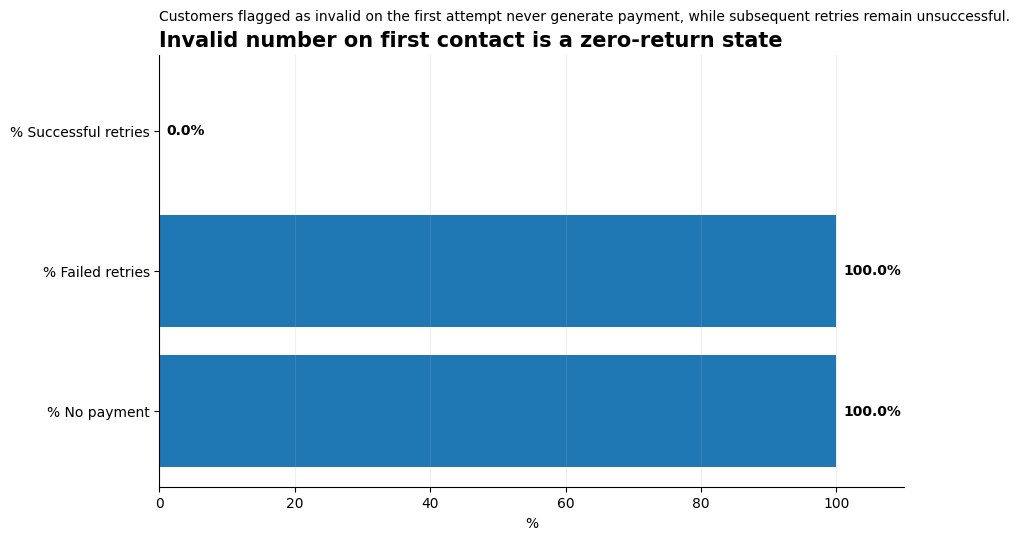

In [6]:
# ============================================================
# EXECUTIVE CHART — R2
# ============================================================

metrics = [
    "% No payment",
    "% Failed retries",
    "% Successful retries"
]

values = [
    pct_no_payment,
    pct_failed_retries,
    100 - pct_failed_retries
]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(metrics, values)

ax.set_xlim(0, 110)
ax.set_xlabel("%")
ax.set_title(
    "Invalid number on first contact is a zero-return state",
    fontsize=15,
    fontweight="bold",
    loc="left"
)

ax.text(
    0,
    1.08,
    "Customers flagged as invalid on the first attempt never generate payment, "
    "while subsequent retries remain unsuccessful.",
    transform=ax.transAxes,
    fontsize=10
)

for bar, value in zip(bars, values):
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        fontweight="bold"
    )

ax.grid(axis="x", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CUSTOMERS WHOSE FIRST CONTACT = INVALID NUMBER
# Base: entire wa
# ============================================================

import pandas as pd

df = wa.copy()
df["sent_at"] = pd.to_datetime(df["sent_at"])

# 1. Ordenar cronologicamente
df = df.sort_values(["customer_id", "sent_at"])

# 2. Pegar literalmente o PRIMEIRO contato de cada cliente
first_contact = (
    df.groupby("customer_id", as_index=False)
      .first()
)

# 3. Filtrar quem teve INVALID NUMBER no primeiro contato
first_invalid = first_contact.loc[
    first_contact["delivery_status"]
        .astype(str)
        .str.contains("invalid.*number", case=False, regex=True, na=False)
].copy()

# 4. Resultado
n_customers = first_invalid["customer_id"].nunique()

print("=" * 70)
print("FIRST CONTACT = INVALID NUMBER")
print("=" * 70)
print(f"Total unique customers in WA     : {df['customer_id'].nunique():,}")
print(f"First contact = invalid number   : {n_customers:,}")
print(
    f"% of WA customers               : "
    f"{n_customers / df['customer_id'].nunique():.1%}"
)


FIRST CONTACT = INVALID NUMBER
Total unique customers in WA     : 11,724
First contact = invalid number   : 608
% of WA customers               : 5.2%


In [8]:
# ============================================================
# FIRST CONTACT — FAILED REASONS
# Base: entire wa
# ============================================================

import pandas as pd

df = wa.copy()
df["sent_at"] = pd.to_datetime(df["sent_at"])

# ------------------------------------------------------------
# 1. Literal first contact per customer
# ------------------------------------------------------------

first_contact = (
    df.sort_values(["customer_id", "sent_at"])
      .groupby("customer_id", as_index=False)
      .first()
)

# ------------------------------------------------------------
# 2. Keep only FAILED first contacts
# ------------------------------------------------------------

first_failed = first_contact.loc[
    first_contact["delivery_status"]
        .astype(str)
        .str.contains("failed", case=False, na=False)
].copy()

# ------------------------------------------------------------
# 3. Distribution of FAILED reasons
# ------------------------------------------------------------

failed_summary = (
    first_failed
    .groupby("delivery_status", dropna=False)
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
    .sort_values("customers", ascending=False)
)

failed_summary["pct_failed_first_contacts"] = (
    failed_summary["customers"]
    / failed_summary["customers"].sum()
    * 100
)

# ------------------------------------------------------------
# 4. Display
# ------------------------------------------------------------

print("=" * 75)
print("FAILED ON LITERAL FIRST CONTACT")
print("=" * 75)
print(f"Unique customers in WA        : {df['customer_id'].nunique():,}")
print(f"First contact = FAILED        : {first_failed['customer_id'].nunique():,}")
print()

display(failed_summary)

FAILED ON LITERAL FIRST CONTACT
Unique customers in WA        : 11,724
First contact = FAILED        : 977



,delivery_status,customers,pct_failed_first_contacts
1,failed_invalid_number,608,62.23
2,failed_unreachable,319,32.65
0,failed_blocked,50,5.12


In [9]:
# ============================================================
# FAILED BLOCKED — FIRST CONTACT + RETRY BEHAVIOR
# Base: entire wa
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()
df["sent_at"] = pd.to_datetime(df["sent_at"])

# ------------------------------------------------------------
# 1. Sort entire WA chronologically
# ------------------------------------------------------------

df = df.sort_values(["customer_id", "sent_at"]).copy()

# ------------------------------------------------------------
# 2. Literal FIRST contact per customer
# ------------------------------------------------------------

first_idx = (
    df.groupby("customer_id")["sent_at"]
      .idxmin()
)

first_contact = df.loc[first_idx].copy()

# ------------------------------------------------------------
# 3. Customers whose FIRST contact = failed_blocked
# ------------------------------------------------------------

blocked_first = first_contact.loc[
    first_contact["delivery_status"]
        .astype(str)
        .str.contains("failed.*blocked", case=False, regex=True, na=False)
].copy()

blocked_ids = set(blocked_first["customer_id"])

# ------------------------------------------------------------
# 4. Get entire journey of these customers
# ------------------------------------------------------------

blocked_journey = (
    df.loc[df["customer_id"].isin(blocked_ids)]
      .sort_values(["customer_id", "sent_at"])
      .copy()
)

blocked_journey["contact_number"] = (
    blocked_journey
    .groupby("customer_id")
    .cumcount() + 1
)

# Anything after contact #1 = retry
retries = blocked_journey.loc[
    blocked_journey["contact_number"] > 1
].copy()

# ------------------------------------------------------------
# 5. Retry success / failure
# ------------------------------------------------------------

retries["retry_failed"] = (
    retries["delivery_status"]
    .astype(str)
    .str.contains("failed", case=False, na=False)
)

retries["retry_success"] = ~retries["retry_failed"]

# ------------------------------------------------------------
# 6. Customer-level retry behavior
# ------------------------------------------------------------

retry_customer = (
    retries.groupby("customer_id")
    .agg(
        retries=("customer_id", "size"),
        failed_retries=("retry_failed", "sum"),
        successful_retries=("retry_success", "sum")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 7. Summary
# ------------------------------------------------------------

n_blocked = len(blocked_ids)
n_retried = retry_customer["customer_id"].nunique()

total_retries = len(retries)
failed_retries = int(retries["retry_failed"].sum())
successful_retries = int(retries["retry_success"].sum())

print("=" * 75)
print("FAILED BLOCKED — FIRST CONTACT + RETRY BEHAVIOR")
print("=" * 75)

print("\nPOPULATION")
print(f"Customers whose FIRST contact = failed_blocked : {n_blocked:,}")

print("\nRETRY BEHAVIOR")
print(f"Customers retried after blocked signal         : {n_retried:,}")
print(f"Messages sent AFTER first blocked signal       : {total_retries:,}")
print(
    f"Failed retries                                 : "
    f"{failed_retries:,} "
    f"({failed_retries / total_retries:.1%})"
    if total_retries else
    "Failed retries                                 : 0"
)
print(f"Successful retries                             : {successful_retries:,}")

print("\nRETRY INTENSITY")

if n_retried:
    print(
        f"Avg retries among customers retried            : "
        f"{retry_customer['retries'].mean():.2f}"
    )
    print(
        f"Median retries                                 : "
        f"{retry_customer['retries'].median():.0f}"
    )
    print(
        f"P75 retries                                    : "
        f"{retry_customer['retries'].quantile(.75):.0f}"
    )
    print(
        f"P90 retries                                    : "
        f"{retry_customer['retries'].quantile(.90):.0f}"
    )
    print(
        f"Maximum retries                                : "
        f"{retry_customer['retries'].max():,}"
    )

print("\nRETRY DELIVERY STATUS")
display(
    retries["delivery_status"]
    .value_counts(dropna=False)
    .rename_axis("delivery_status")
    .reset_index(name="messages")
)

FAILED BLOCKED — FIRST CONTACT + RETRY BEHAVIOR

POPULATION
Customers whose FIRST contact = failed_blocked : 50

RETRY BEHAVIOR
Customers retried after blocked signal         : 47
Messages sent AFTER first blocked signal       : 322
Failed retries                                 : 322 (100.0%)
Successful retries                             : 0

RETRY INTENSITY
Avg retries among customers retried            : 6.85
Median retries                                 : 7
P75 retries                                    : 9
P90 retries                                    : 11
Maximum retries                                : 14

RETRY DELIVERY STATUS


,delivery_status,messages
0,failed_blocked,322


In [10]:
# ============================================================
# FAILED BLOCKED — ZERO FINANCIAL RETURN TEST
# Population:
# Customers whose literal FIRST WA contact = failed_blocked
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()
df["sent_at"] = pd.to_datetime(df["sent_at"])
df = df.sort_values(["customer_id", "sent_at"]).copy()

# ------------------------------------------------------------
# 1. Literal FIRST contact per customer
# ------------------------------------------------------------

first_idx = (
    df.groupby("customer_id")["sent_at"]
      .idxmin()
)

first_contact = df.loc[first_idx].copy()

# ------------------------------------------------------------
# 2. Customers whose FIRST contact = failed_blocked
# ------------------------------------------------------------

blocked_first = first_contact.loc[
    first_contact["delivery_status"]
        .astype(str)
        .str.contains(
            "failed.*blocked",
            case=False,
            regex=True,
            na=False
        )
].copy()

blocked_ids = set(blocked_first["customer_id"])

# ------------------------------------------------------------
# 3. Entire observed journey of these customers
# ------------------------------------------------------------

blocked_journey = (
    df.loc[df["customer_id"].isin(blocked_ids)]
      .sort_values(["customer_id", "sent_at"])
      .copy()
)

blocked_journey["contact_number"] = (
    blocked_journey
    .groupby("customer_id")
    .cumcount() + 1
)

# ------------------------------------------------------------
# 4. ONLY observations AFTER first blocked contact
# ------------------------------------------------------------

after_blocked = blocked_journey.loc[
    blocked_journey["contact_number"] > 1
].copy()

# ------------------------------------------------------------
# 5. Payment test
# ------------------------------------------------------------

after_blocked["amount_paid_brl"] = pd.to_numeric(
    after_blocked["amount_paid_brl"],
    errors="coerce"
).fillna(0)

payment_rows = after_blocked.loc[
    after_blocked["amount_paid_brl"] > 0
].copy()

customers_with_payment = (
    payment_rows["customer_id"].nunique()
)

total_attributed_payment = (
    payment_rows["amount_paid_brl"].sum()
)

# ------------------------------------------------------------
# 6. Customer-level check
# ------------------------------------------------------------

customer_return = (
    after_blocked
    .groupby("customer_id")
    .agg(
        retries=("customer_id", "size"),
        total_attributed_payment_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
)

customer_return["generated_return"] = (
    customer_return["total_attributed_payment_brl"] > 0
)

# ------------------------------------------------------------
# 7. Results
# ------------------------------------------------------------

print("=" * 75)
print("FAILED BLOCKED — FINANCIAL RETURN AFTER FIRST SIGNAL")
print("=" * 75)

print("\nPOPULATION")
print(
    f"Customers whose FIRST contact = failed_blocked : "
    f"{len(blocked_ids):,}"
)
print(
    f"Customers subsequently retried                 : "
    f"{after_blocked['customer_id'].nunique():,}"
)

print("\nRETURN AFTER FAILED_BLOCKED")
print(
    f"Messages sent after blocked signal             : "
    f"{len(after_blocked):,}"
)
print(
    f"Messages associated with payment > R$ 0        : "
    f"{len(payment_rows):,}"
)
print(
    f"Customers with payment > R$ 0                  : "
    f"{customers_with_payment:,}"
)
print(
    f"Attributed payment after blocked signal        : "
    f"R$ {total_attributed_payment:,.2f}"
)

print("\nCUSTOMER RETURN RATE")
print(
    f"Customers generating observed return           : "
    f"{customer_return['generated_return'].sum():,}"
)
print(
    f"Observed return rate                           : "
    f"{customer_return['generated_return'].mean():.1%}"
    if len(customer_return) else
    "Observed return rate                           : N/A"
)

# ------------------------------------------------------------
# 8. Audit — show any exceptions
# ------------------------------------------------------------

print("\nEXCEPTIONS — PAYMENTS > R$ 0")

if payment_rows.empty:
    print("NONE — no payment observed after failed_blocked.")
else:
    display(
        payment_rows[
            [
                "customer_id",
                "sent_at",
                "delivery_status",
                "amount_paid_brl"
            ]
        ].sort_values(
            ["customer_id", "sent_at"]
        )
    )

FAILED BLOCKED — FINANCIAL RETURN AFTER FIRST SIGNAL

POPULATION
Customers whose FIRST contact = failed_blocked : 50
Customers subsequently retried                 : 47

RETURN AFTER FAILED_BLOCKED
Messages sent after blocked signal             : 322
Messages associated with payment > R$ 0        : 0
Customers with payment > R$ 0                  : 0
Attributed payment after blocked signal        : R$ 0.00

CUSTOMER RETURN RATE
Customers generating observed return           : 0
Observed return rate                           : 0.0%

EXCEPTIONS — PAYMENTS > R$ 0
NONE — no payment observed after failed_blocked.


In [11]:
# ============================================================
# FAILED UNREACHABLE — FIRST CONTACT + RETRY + RETURN
# Base: entire wa
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()
df["sent_at"] = pd.to_datetime(df["sent_at"])
df = df.sort_values(["customer_id", "sent_at"]).copy()

# ------------------------------------------------------------
# 1. Literal FIRST contact per customer
# ------------------------------------------------------------

first_idx = (
    df.groupby("customer_id")["sent_at"]
      .idxmin()
)

first_contact = df.loc[first_idx].copy()

# ------------------------------------------------------------
# 2. Customers whose FIRST contact = failed_unreachable
# ------------------------------------------------------------

unreachable_first = first_contact.loc[
    first_contact["delivery_status"]
        .astype(str)
        .str.contains(
            "failed.*unreachable",
            case=False,
            regex=True,
            na=False
        )
].copy()

unreachable_ids = set(unreachable_first["customer_id"])

# ------------------------------------------------------------
# 3. Entire observed journey
# ------------------------------------------------------------

journey = (
    df.loc[df["customer_id"].isin(unreachable_ids)]
      .sort_values(["customer_id", "sent_at"])
      .copy()
)

journey["contact_number"] = (
    journey.groupby("customer_id").cumcount() + 1
)

# ------------------------------------------------------------
# 4. Everything AFTER first unreachable signal
# ------------------------------------------------------------

after_unreachable = journey.loc[
    journey["contact_number"] > 1
].copy()

# ------------------------------------------------------------
# 5. Delivery success / failure
# ------------------------------------------------------------

after_unreachable["retry_failed"] = (
    after_unreachable["delivery_status"]
    .astype(str)
    .str.contains("failed", case=False, na=False)
)

after_unreachable["retry_success"] = (
    ~after_unreachable["retry_failed"]
)

# ------------------------------------------------------------
# 6. Payment / financial return
# ------------------------------------------------------------

after_unreachable["amount_paid_brl"] = pd.to_numeric(
    after_unreachable["amount_paid_brl"],
    errors="coerce"
).fillna(0)

payment_rows = after_unreachable.loc[
    after_unreachable["amount_paid_brl"] > 0
].copy()

# ------------------------------------------------------------
# 7. Customer-level retry behavior
# ------------------------------------------------------------

customer_summary = (
    after_unreachable
    .groupby("customer_id")
    .agg(
        retries=("customer_id", "size"),
        failed_retries=("retry_failed", "sum"),
        successful_retries=("retry_success", "sum"),
        attributed_payment_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
)

customer_summary["generated_return"] = (
    customer_summary["attributed_payment_brl"] > 0
)

# ------------------------------------------------------------
# 8. Main KPIs
# ------------------------------------------------------------

n_population = len(unreachable_ids)
n_retried = after_unreachable["customer_id"].nunique()

total_retries = len(after_unreachable)
failed_retries = int(after_unreachable["retry_failed"].sum())
successful_retries = int(after_unreachable["retry_success"].sum())

customers_with_payment = payment_rows["customer_id"].nunique()
total_payment = payment_rows["amount_paid_brl"].sum()

# ------------------------------------------------------------
# 9. Results
# ------------------------------------------------------------

print("=" * 75)
print("FAILED UNREACHABLE — FIRST CONTACT + RETRY + RETURN")
print("=" * 75)

print("\nPOPULATION")
print(
    f"Customers whose FIRST contact = failed_unreachable : "
    f"{n_population:,}"
)

print("\nRETRY BEHAVIOR")
print(
    f"Customers subsequently retried                     : "
    f"{n_retried:,}"
)
print(
    f"Messages sent AFTER unreachable signal             : "
    f"{total_retries:,}"
)

if total_retries:
    print(
        f"Failed retries                                     : "
        f"{failed_retries:,} ({failed_retries / total_retries:.1%})"
    )
    print(
        f"Successful retries                                 : "
        f"{successful_retries:,} ({successful_retries / total_retries:.1%})"
    )

print("\nFINANCIAL RETURN")
print(
    f"Messages associated with payment > R$ 0            : "
    f"{len(payment_rows):,}"
)
print(
    f"Customers with payment > R$ 0                      : "
    f"{customers_with_payment:,}"
)
print(
    f"Attributed payment after unreachable signal        : "
    f"R$ {total_payment:,.2f}"
)

# ------------------------------------------------------------
# 10. Retry intensity
# ------------------------------------------------------------

print("\nRETRY INTENSITY")

if n_retried:
    print(
        f"Avg retries among customers retried                : "
        f"{customer_summary['retries'].mean():.2f}"
    )
    print(
        f"Median retries                                     : "
        f"{customer_summary['retries'].median():.0f}"
    )
    print(
        f"P75 retries                                        : "
        f"{customer_summary['retries'].quantile(.75):.0f}"
    )
    print(
        f"P90 retries                                        : "
        f"{customer_summary['retries'].quantile(.90):.0f}"
    )
    print(
        f"Maximum retries                                    : "
        f"{customer_summary['retries'].max():,.0f}"
    )

# ------------------------------------------------------------
# 11. What happened to subsequent messages?
# ------------------------------------------------------------

print("\nRETRY DELIVERY STATUS")

display(
    after_unreachable["delivery_status"]
    .value_counts(dropna=False)
    .rename_axis("delivery_status")
    .reset_index(name="messages")
)

# ------------------------------------------------------------
# 12. Audit payments / exceptions
# ------------------------------------------------------------

print("\nPAYMENT EXCEPTIONS")

if payment_rows.empty:
    print("NONE — no attributed payment observed after failed_unreachable.")
else:
    display(
        payment_rows[
            [
                "customer_id",
                "sent_at",
                "delivery_status",
                "amount_paid_brl"
            ]
        ].sort_values(
            ["customer_id", "sent_at"]
        )
    )

FAILED UNREACHABLE — FIRST CONTACT + RETRY + RETURN

POPULATION
Customers whose FIRST contact = failed_unreachable : 319

RETRY BEHAVIOR
Customers subsequently retried                     : 306
Messages sent AFTER unreachable signal             : 1,809
Failed retries                                     : 172 (9.5%)
Successful retries                                 : 1,637 (90.5%)

FINANCIAL RETURN
Messages associated with payment > R$ 0            : 129
Customers with payment > R$ 0                      : 123
Attributed payment after unreachable signal        : R$ 81,942.44

RETRY INTENSITY
Avg retries among customers retried                : 5.91
Median retries                                     : 6
P75 retries                                        : 8
P90 retries                                        : 11
Maximum retries                                    : 15

RETRY DELIVERY STATUS


,delivery_status,messages
0,delivered,1637
1,failed_blocked,118
2,failed_unreachable,54



PAYMENT EXCEPTIONS


,customer_id,sent_at,delivery_status,amount_paid_brl
32808,C000082,2026-07-21 13:54:00,delivered,143.81
18278,C000119,2026-07-06 09:33:00,delivered,"1,828.30"
42147,C000251,2026-07-30 12:04:00,delivered,"1,346.80"
38506,C000336,2026-07-27 13:56:00,delivered,494.86
31908,C000385,2026-07-20 17:48:00,delivered,"1,374.12"
...,...,...,...,...
32072,C011473,2026-07-20 20:34:00,delivered,"1,006.56"
45392,C011612,2026-08-03 10:16:00,delivered,654.05
57677,C011653,2026-08-14 10:13:00,delivered,250.73
46041,C011801,2026-08-03 14:41:00,delivered,509.57


In [12]:
# ============================================================
# TERMINAL FAILURE TEST
# failed_blocked OR failed_invalid_number
#
# Question:
# If a customer was previously reachable/delivered and later gets
# blocked or invalid_number, should we stop future WA attempts?
#
# Base: entire wa
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()
df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df.sort_values(["customer_id", "sent_at", "message_id"])
      .copy()
)

# ------------------------------------------------------------
# 1. Identify signals
# ------------------------------------------------------------

status = (
    df["delivery_status"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["terminal_failure"] = (
    status.str.contains("failed.*blocked", regex=True, na=False)
    |
    status.str.contains("failed.*invalid.*number", regex=True, na=False)
)

# "Delivered before" = any prior successful delivery state
# Adjust if your dataset uses other successful statuses.
df["delivered_signal"] = (
    status.str.contains("delivered|read", regex=True, na=False)
)

# ------------------------------------------------------------
# 2. For each customer, identify FIRST terminal failure
# ------------------------------------------------------------

terminal = df.loc[df["terminal_failure"]].copy()

first_terminal_idx = (
    terminal
    .groupby("customer_id")["sent_at"]
    .idxmin()
)

first_terminal = (
    df.loc[first_terminal_idx, [
        "customer_id",
        "sent_at",
        "delivery_status"
    ]]
    .rename(columns={
        "sent_at": "terminal_failure_at",
        "delivery_status": "terminal_failure_type"
    })
    .copy()
)

# ------------------------------------------------------------
# 3. Was customer successfully reachable BEFORE terminal failure?
# ------------------------------------------------------------

analysis = df.merge(
    first_terminal,
    on="customer_id",
    how="inner"
)

before_terminal = analysis.loc[
    analysis["sent_at"] < analysis["terminal_failure_at"]
].copy()

previously_delivered_ids = set(
    before_terminal.loc[
        before_terminal["delivered_signal"],
        "customer_id"
    ]
)

# ------------------------------------------------------------
# 4. Population of interest:
# previously delivered THEN blocked/invalid
# ------------------------------------------------------------

cohort = first_terminal.loc[
    first_terminal["customer_id"].isin(previously_delivered_ids)
].copy()

cohort_ids = set(cohort["customer_id"])

# ------------------------------------------------------------
# 5. Everything STRICTLY AFTER terminal failure
# ------------------------------------------------------------

after_terminal = analysis.loc[
    analysis["customer_id"].isin(cohort_ids)
    &
    (analysis["sent_at"] > analysis["terminal_failure_at"])
].copy()

# ------------------------------------------------------------
# 6. Classify subsequent attempts
# ------------------------------------------------------------

after_status = (
    after_terminal["delivery_status"]
    .astype(str)
    .str.lower()
    .str.strip()
)

after_terminal["failed_after"] = (
    after_status.str.contains("failed", case=False, na=False)
)

after_terminal["delivered_after"] = (
    after_status.str.contains("delivered|read", regex=True, na=False)
)

# ------------------------------------------------------------
# 7. Financial return
# ------------------------------------------------------------

after_terminal["amount_paid_brl"] = pd.to_numeric(
    after_terminal["amount_paid_brl"],
    errors="coerce"
).fillna(0)

after_terminal["payment_after"] = (
    after_terminal["amount_paid_brl"] > 0
)

# ------------------------------------------------------------
# 8. Customer-level summary
# ------------------------------------------------------------

customer_summary = (
    after_terminal
    .groupby("customer_id")
    .agg(
        attempts_after=("customer_id", "size"),
        failed_after=("failed_after", "sum"),
        delivered_after=("delivered_after", "sum"),
        attributed_payment_after_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
)

customer_summary["ever_delivered_again"] = (
    customer_summary["delivered_after"] > 0
)

customer_summary["ever_generated_return"] = (
    customer_summary["attributed_payment_after_brl"] > 0
)

# ------------------------------------------------------------
# 9. MAIN RESULTS
# ------------------------------------------------------------

n_cohort = len(cohort_ids)
n_retried = after_terminal["customer_id"].nunique()
n_attempts = len(after_terminal)

failed_attempts = int(after_terminal["failed_after"].sum())
delivered_attempts = int(after_terminal["delivered_after"].sum())

payment_messages = int(after_terminal["payment_after"].sum())
payment_customers = after_terminal.loc[
    after_terminal["payment_after"],
    "customer_id"
].nunique()

total_payment = after_terminal["amount_paid_brl"].sum()

print("=" * 80)
print("TERMINAL FAILURE AFTER PREVIOUS SUCCESSFUL DELIVERY")
print("FAILED_BLOCKED + FAILED_INVALID_NUMBER")
print("=" * 80)

print("\nPOPULATION")
print(
    f"Previously delivered → later terminal failure : "
    f"{n_cohort:,}"
)

print("\nBEHAVIOR AFTER TERMINAL FAILURE")
print(
    f"Customers subsequently retried                : "
    f"{n_retried:,}"
)
print(
    f"Messages sent after terminal failure          : "
    f"{n_attempts:,}"
)

if n_attempts:
    print(
        f"Failed subsequent attempts                    : "
        f"{failed_attempts:,} ({failed_attempts/n_attempts:.1%})"
    )
    print(
        f"Delivered/read subsequent attempts            : "
        f"{delivered_attempts:,} ({delivered_attempts/n_attempts:.1%})"
    )

print("\nCUSTOMER RECOVERY OF CHANNEL")
print(
    f"Customers ever delivered/read again           : "
    f"{customer_summary['ever_delivered_again'].sum():,}"
)

print("\nFINANCIAL RETURN AFTER SIGNAL")
print(
    f"Messages associated with payment > R$0        : "
    f"{payment_messages:,}"
)
print(
    f"Customers with attributed payment > R$0       : "
    f"{payment_customers:,}"
)
print(
    f"Attributed recovery                           : "
    f"R$ {total_payment:,.2f}"
)

# ------------------------------------------------------------
# 10. Break down by terminal failure type
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("BREAKDOWN BY TERMINAL FAILURE TYPE")
print("=" * 80)

breakdown = (
    after_terminal
    .groupby("terminal_failure_type", dropna=False)
    .agg(
        customers_retried=("customer_id", "nunique"),
        attempts_after=("customer_id", "size"),
        failed_after=("failed_after", "sum"),
        delivered_after=("delivered_after", "sum"),
        payment_messages=("payment_after", "sum"),
        attributed_recovery_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
)

breakdown["failure_rate_after"] = (
    breakdown["failed_after"]
    / breakdown["attempts_after"]
)

breakdown["delivery_rate_after"] = (
    breakdown["delivered_after"]
    / breakdown["attempts_after"]
)

display(breakdown)

# ------------------------------------------------------------
# 11. DELIVERY EXCEPTIONS
# Critical audit:
# Did ANY blocked/invalid customer become reachable again?
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DELIVERY EXCEPTIONS AFTER TERMINAL SIGNAL")
print("=" * 80)

delivery_exceptions = after_terminal.loc[
    after_terminal["delivered_after"]
].copy()

if delivery_exceptions.empty:
    print(
        "NONE — no customer became delivered/read again "
        "after blocked/invalid_number."
    )
else:
    display(
        delivery_exceptions[
            [
                "customer_id",
                "terminal_failure_at",
                "terminal_failure_type",
                "sent_at",
                "delivery_status",
                "amount_paid_brl"
            ]
        ].sort_values(
            ["customer_id", "sent_at"]
        )
    )

# ------------------------------------------------------------
# 12. PAYMENT EXCEPTIONS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PAYMENT EXCEPTIONS AFTER TERMINAL SIGNAL")
print("=" * 80)

payment_exceptions = after_terminal.loc[
    after_terminal["payment_after"]
].copy()

if payment_exceptions.empty:
    print(
        "NONE — no attributed payment observed "
        "after blocked/invalid_number."
    )
else:
    display(
        payment_exceptions[
            [
                "customer_id",
                "terminal_failure_at",
                "terminal_failure_type",
                "sent_at",
                "delivery_status",
                "amount_paid_brl"
            ]
        ].sort_values(
            ["customer_id", "sent_at"]
        )
    )

TERMINAL FAILURE AFTER PREVIOUS SUCCESSFUL DELIVERY
FAILED_BLOCKED + FAILED_INVALID_NUMBER

POPULATION
Previously delivered → later terminal failure : 888

BEHAVIOR AFTER TERMINAL FAILURE
Customers subsequently retried                : 802
Messages sent after terminal failure          : 3,784
Failed subsequent attempts                    : 3,784 (100.0%)
Delivered/read subsequent attempts            : 0 (0.0%)

CUSTOMER RECOVERY OF CHANNEL
Customers ever delivered/read again           : 0

FINANCIAL RETURN AFTER SIGNAL
Messages associated with payment > R$0        : 0
Customers with attributed payment > R$0       : 0
Attributed recovery                           : R$ 0.00

BREAKDOWN BY TERMINAL FAILURE TYPE


,terminal_failure_type,customers_retried,attempts_after,failed_after,delivered_after,payment_messages,attributed_recovery_brl,failure_rate_after,delivery_rate_after
0,failed_blocked,802,3784,3784,0,0,0.00,1.00,0.00



DELIVERY EXCEPTIONS AFTER TERMINAL SIGNAL
NONE — no customer became delivered/read again after blocked/invalid_number.

PAYMENT EXCEPTIONS AFTER TERMINAL SIGNAL
NONE — no attributed payment observed after blocked/invalid_number.


In [13]:
# ============================================================
# FAILED_BLOCKED — UNIFIED STOP-SIGNAL ANALYSIS
#
# GROUP A:
# First observed WA contact = failed_blocked
#
# GROUP B:
# Customer had delivered/read BEFORE first failed_blocked
#
# Question:
# After failed_blocked, do further WA attempts ever recover
# the channel or generate attributed financial return?
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

# ------------------------------------------------------------
# 1. Normalize delivery status
# ------------------------------------------------------------

status = (
    df["delivery_status"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["is_blocked"] = status.eq("failed_blocked")

df["is_delivered"] = (
    status.str.contains(
        "delivered|read",
        regex=True,
        na=False
    )
)

# ------------------------------------------------------------
# 2. Literal FIRST contact of each customer
# ------------------------------------------------------------

first_contact = (
    df.groupby("customer_id", as_index=False)
      .first()
)

first_blocked_ids = set(
    first_contact.loc[
        first_contact["is_blocked"],
        "customer_id"
    ]
)

# ------------------------------------------------------------
# 3. FIRST failed_blocked in entire journey
# ------------------------------------------------------------

first_blocked = (
    df.loc[df["is_blocked"]]
      .groupby("customer_id", as_index=False)
      .first()
      [["customer_id", "sent_at"]]
      .rename(
          columns={
              "sent_at": "first_blocked_at"
          }
      )
)

# ------------------------------------------------------------
# 4. Attach first blocked timestamp
# ------------------------------------------------------------

analysis = df.merge(
    first_blocked,
    on="customer_id",
    how="inner"
)

# ------------------------------------------------------------
# 5. Determine whether customer was reachable BEFORE blocked
# ------------------------------------------------------------

before_blocked = analysis.loc[
    analysis["sent_at"] < analysis["first_blocked_at"]
].copy()

previously_delivered_ids = set(
    before_blocked.loc[
        before_blocked["is_delivered"],
        "customer_id"
    ]
)

# ------------------------------------------------------------
# 6. Define mutually exclusive groups
# ------------------------------------------------------------

# GROUP A
# First contact itself was blocked
group_a_ids = first_blocked_ids

# GROUP B
# Delivered/read before becoming blocked
# Exclude Group A so populations do not overlap
group_b_ids = (
    previously_delivered_ids
    - group_a_ids
)

# Unified population
unified_ids = (
    group_a_ids
    | group_b_ids
)

# ------------------------------------------------------------
# 7. Classification
# ------------------------------------------------------------

group_map = {}

for cid in group_a_ids:
    group_map[cid] = "Blocked on first contact"

for cid in group_b_ids:
    group_map[cid] = "Previously delivered → blocked"

# ------------------------------------------------------------
# 8. Everything STRICTLY AFTER first blocked
# ------------------------------------------------------------

after_blocked = analysis.loc[
    analysis["customer_id"].isin(unified_ids)
    &
    (
        analysis["sent_at"]
        > analysis["first_blocked_at"]
    )
].copy()

after_blocked["blocked_group"] = (
    after_blocked["customer_id"]
    .map(group_map)
)

# ------------------------------------------------------------
# 9. Classify subsequent attempts
# ------------------------------------------------------------

after_status = (
    after_blocked["delivery_status"]
    .astype(str)
    .str.lower()
    .str.strip()
)

after_blocked["failed_after"] = (
    after_status.str.contains(
        "failed",
        na=False
    )
)

after_blocked["delivered_after"] = (
    after_status.str.contains(
        "delivered|read",
        regex=True,
        na=False
    )
)

# ------------------------------------------------------------
# 10. Financial return
# ------------------------------------------------------------

after_blocked["amount_paid_brl"] = pd.to_numeric(
    after_blocked["amount_paid_brl"],
    errors="coerce"
).fillna(0)

after_blocked["payment_after"] = (
    after_blocked["amount_paid_brl"] > 0
)

# ------------------------------------------------------------
# 11. Customer-level post-block behavior
# ------------------------------------------------------------

customer_post_block = (
    after_blocked
    .groupby(
        ["blocked_group", "customer_id"],
        as_index=False
    )
    .agg(
        attempts_after_block=(
            "customer_id",
            "size"
        ),
        failed_attempts=(
            "failed_after",
            "sum"
        ),
        delivered_attempts=(
            "delivered_after",
            "sum"
        ),
        attributed_recovery_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)

customer_post_block["channel_recovered"] = (
    customer_post_block["delivered_attempts"] > 0
)

customer_post_block["generated_return"] = (
    customer_post_block[
        "attributed_recovery_brl"
    ] > 0
)

# ------------------------------------------------------------
# 12. Population counts
# ------------------------------------------------------------

population = pd.DataFrame({
    "blocked_group": [
        "Blocked on first contact",
        "Previously delivered → blocked"
    ],
    "customers": [
        len(group_a_ids),
        len(group_b_ids)
    ]
})

# ------------------------------------------------------------
# 13. Post-block summary
# ------------------------------------------------------------

post_summary = (
    after_blocked
    .groupby(
        "blocked_group",
        as_index=False
    )
    .agg(
        customers_retried=(
            "customer_id",
            "nunique"
        ),
        messages_after_block=(
            "customer_id",
            "size"
        ),
        failed_messages=(
            "failed_after",
            "sum"
        ),
        delivered_messages=(
            "delivered_after",
            "sum"
        ),
        payment_messages=(
            "payment_after",
            "sum"
        ),
        attributed_recovery_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)

summary = population.merge(
    post_summary,
    on="blocked_group",
    how="left"
).fillna(0)

summary["customers_not_retried"] = (
    summary["customers"]
    - summary["customers_retried"]
)

summary["retry_customer_rate"] = (
    summary["customers_retried"]
    / summary["customers"]
)

summary["failure_rate_after_block"] = (
    summary["failed_messages"]
    / summary["messages_after_block"]
).replace([np.inf, -np.inf], np.nan)

summary["delivery_rate_after_block"] = (
    summary["delivered_messages"]
    / summary["messages_after_block"]
).replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# 14. TOTAL
# ------------------------------------------------------------

total_population = len(unified_ids)

total_retried = (
    after_blocked["customer_id"].nunique()
)

total_messages = len(after_blocked)

total_failed = int(
    after_blocked["failed_after"].sum()
)

total_delivered = int(
    after_blocked["delivered_after"].sum()
)

total_payment_messages = int(
    after_blocked["payment_after"].sum()
)

total_payment_customers = (
    after_blocked.loc[
        after_blocked["payment_after"],
        "customer_id"
    ].nunique()
)

total_recovery = (
    after_blocked["amount_paid_brl"].sum()
)

channel_recovered_customers = (
    after_blocked.loc[
        after_blocked["delivered_after"],
        "customer_id"
    ].nunique()
)

# ------------------------------------------------------------
# 15. PRINT EXECUTIVE OUTPUT
# ------------------------------------------------------------

print("=" * 85)
print("FAILED_BLOCKED — UNIFIED STOP-SIGNAL ANALYSIS")
print("=" * 85)

print("\nPOPULATION")

print(
    f"Blocked on first contact                  : "
    f"{len(group_a_ids):,}"
)

print(
    f"Previously delivered → later blocked      : "
    f"{len(group_b_ids):,}"
)

print(
    f"TOTAL customers with validated block path : "
    f"{total_population:,}"
)

print("\nPOST-BLOCK PERSISTENCE")

print(
    f"Customers retried after blocked           : "
    f"{total_retried:,}"
)

print(
    f"Customers not retried                     : "
    f"{total_population - total_retried:,}"
)

print(
    f"Messages sent AFTER failed_blocked        : "
    f"{total_messages:,}"
)

print("\nPOST-BLOCK OUTCOME")

if total_messages:

    print(
        f"Failed messages                           : "
        f"{total_failed:,} "
        f"({total_failed / total_messages:.1%})"
    )

    print(
        f"Delivered/read messages                   : "
        f"{total_delivered:,} "
        f"({total_delivered / total_messages:.1%})"
    )

print(
    f"Customers whose channel recovered         : "
    f"{channel_recovered_customers:,}"
)

print("\nFINANCIAL RETURN")

print(
    f"Messages associated with payment > R$0    : "
    f"{total_payment_messages:,}"
)

print(
    f"Customers with attributed payment > R$0   : "
    f"{total_payment_customers:,}"
)

print(
    f"Attributed recovery after blocked         : "
    f"R$ {total_recovery:,.2f}"
)

print("\n" + "=" * 85)
print("BREAKDOWN BY BLOCK PATH")
print("=" * 85)

display(summary)

# ------------------------------------------------------------
# 16. AUDIT — ANY DELIVERY AFTER BLOCK?
# ------------------------------------------------------------

print("\n" + "=" * 85)
print("DELIVERY EXCEPTIONS AFTER FAILED_BLOCKED")
print("=" * 85)

delivery_exceptions = after_blocked.loc[
    after_blocked["delivered_after"]
].copy()

if delivery_exceptions.empty:

    print(
        "NONE — no delivered/read message observed "
        "after failed_blocked."
    )

else:

    display(
        delivery_exceptions[
            [
                "customer_id",
                "blocked_group",
                "first_blocked_at",
                "sent_at",
                "delivery_status",
                "amount_paid_brl"
            ]
        ].sort_values(
            ["customer_id", "sent_at"]
        )
    )

# ------------------------------------------------------------
# 17. AUDIT — ANY PAYMENT AFTER BLOCK?
# ------------------------------------------------------------

print("\n" + "=" * 85)
print("PAYMENT EXCEPTIONS AFTER FAILED_BLOCKED")
print("=" * 85)

payment_exceptions = after_blocked.loc[
    after_blocked["payment_after"]
].copy()

if payment_exceptions.empty:

    print(
        "NONE — no attributed payment observed "
        "after failed_blocked."
    )

else:

    display(
        payment_exceptions[
            [
                "customer_id",
                "blocked_group",
                "first_blocked_at",
                "sent_at",
                "delivery_status",
                "amount_paid_brl"
            ]
        ].sort_values(
            ["customer_id", "sent_at"]
        )
    )

FAILED_BLOCKED — UNIFIED STOP-SIGNAL ANALYSIS

POPULATION
Blocked on first contact                  : 50
Previously delivered → later blocked      : 888
TOTAL customers with validated block path : 938

POST-BLOCK PERSISTENCE
Customers retried after blocked           : 849
Customers not retried                     : 89
Messages sent AFTER failed_blocked        : 4,106

POST-BLOCK OUTCOME
Failed messages                           : 4,106 (100.0%)
Delivered/read messages                   : 0 (0.0%)
Customers whose channel recovered         : 0

FINANCIAL RETURN
Messages associated with payment > R$0    : 0
Customers with attributed payment > R$0   : 0
Attributed recovery after blocked         : R$ 0.00

BREAKDOWN BY BLOCK PATH


,blocked_group,customers,customers_retried,messages_after_block,failed_messages,delivered_messages,payment_messages,attributed_recovery_brl,customers_not_retried,retry_customer_rate,failure_rate_after_block,delivery_rate_after_block
0,Blocked on first contact,50,47,322,322,0,0,0.00,3,0.94,1.00,0.00
1,Previously delivered → blocked,888,802,3784,3784,0,0,0.00,86,0.90,1.00,0.00



DELIVERY EXCEPTIONS AFTER FAILED_BLOCKED
NONE — no delivered/read message observed after failed_blocked.

PAYMENT EXCEPTIONS AFTER FAILED_BLOCKED
NONE — no attributed payment observed after failed_blocked.


In [14]:
# ============================================================
# FAILED_BLOCKED — OUTSTANDING DEBT POOL
#
# GROUP A:
# Blocked on first contact
#
# GROUP B:
# Previously delivered/read → later blocked
#
# Balance definition:
# outstanding_balance_brl observed at FIRST failed_blocked
# Customer grain = 1 row per customer
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Start from original WhatsApp table
# ------------------------------------------------------------

df_block = wa.copy()

df_block["sent_at"] = pd.to_datetime(
    df_block["sent_at"],
    errors="coerce"
)

df_block["outstanding_balance_brl"] = pd.to_numeric(
    df_block["outstanding_balance_brl"],
    errors="coerce"
)

df_block = (
    df_block
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

# ------------------------------------------------------------
# 2. Normalize delivery status
# ------------------------------------------------------------

status = (
    df_block["delivery_status"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df_block["is_blocked"] = status.eq("failed_blocked")

df_block["is_delivered"] = (
    status.str.contains(
        "delivered|read",
        regex=True,
        na=False
    )
)

# ------------------------------------------------------------
# 3. Literal FIRST WhatsApp contact per customer
# ------------------------------------------------------------

first_contact = (
    df_block
    .groupby("customer_id", as_index=False)
    .first()
)

# Customers blocked immediately on first contact
group_a_ids = set(
    first_contact.loc[
        first_contact["is_blocked"],
        "customer_id"
    ]
)

# ------------------------------------------------------------
# 4. Exact FIRST failed_blocked row per customer
# ------------------------------------------------------------

first_blocked_row = (
    df_block.loc[
        df_block["is_blocked"]
    ]
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .groupby(
        "customer_id",
        as_index=False
    )
    .first()
)

first_blocked_row = (
    first_blocked_row[
        [
            "customer_id",
            "sent_at",
            "outstanding_balance_brl"
        ]
    ]
    .rename(
        columns={
            "sent_at": "first_blocked_at",
            "outstanding_balance_brl":
                "balance_at_first_block"
        }
    )
)

# ------------------------------------------------------------
# 5. Determine who was delivered/read BEFORE first block
# ------------------------------------------------------------

tmp = df_block.merge(
    first_blocked_row[
        ["customer_id", "first_blocked_at"]
    ],
    on="customer_id",
    how="inner"
)

before_block = tmp.loc[
    tmp["sent_at"] < tmp["first_blocked_at"]
].copy()

previously_delivered_ids = set(
    before_block.loc[
        before_block["is_delivered"],
        "customer_id"
    ]
)

# ------------------------------------------------------------
# 6. Define mutually exclusive groups
# ------------------------------------------------------------

# GROUP A:
# First ever contact already blocked
group_a_ids = set(group_a_ids)

# GROUP B:
# Had successful delivery/read before later becoming blocked
group_b_ids = (
    previously_delivered_ids
    - group_a_ids
)

# ------------------------------------------------------------
# 7. Keep only the two validated populations
# ------------------------------------------------------------

valid_ids = group_a_ids | group_b_ids

debt_base = (
    first_blocked_row.loc[
        first_blocked_row["customer_id"].isin(valid_ids)
    ]
    .copy()
)

# Classification
debt_base["blocked_group"] = np.where(
    debt_base["customer_id"].isin(group_a_ids),
    "Blocked on first contact",
    "Previously delivered → later blocked"
)

# ------------------------------------------------------------
# 8. Customer-level debt pool
# ------------------------------------------------------------

debt_summary = (
    debt_base
    .groupby(
        "blocked_group",
        as_index=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        total_outstanding_brl=(
            "balance_at_first_block",
            "sum"
        ),
        avg_outstanding_brl=(
            "balance_at_first_block",
            "mean"
        ),
        median_outstanding_brl=(
            "balance_at_first_block",
            "median"
        ),
        p25_outstanding_brl=(
            "balance_at_first_block",
            lambda x: x.quantile(0.25)
        ),
        p75_outstanding_brl=(
            "balance_at_first_block",
            lambda x: x.quantile(0.75)
        ),
        max_outstanding_brl=(
            "balance_at_first_block",
            "max"
        )
    )
)

# ------------------------------------------------------------
# 9. Share of total blocked debt
# ------------------------------------------------------------

total_debt = debt_base[
    "balance_at_first_block"
].sum()

debt_summary["share_of_blocked_debt_pct"] = (
    debt_summary["total_outstanding_brl"]
    / total_debt
    * 100
)

# ------------------------------------------------------------
# 10. Add TOTAL row
# ------------------------------------------------------------

total_row = pd.DataFrame({
    "blocked_group": ["TOTAL"],
    "customers": [
        debt_base["customer_id"].nunique()
    ],
    "total_outstanding_brl": [
        debt_base["balance_at_first_block"].sum()
    ],
    "avg_outstanding_brl": [
        debt_base["balance_at_first_block"].mean()
    ],
    "median_outstanding_brl": [
        debt_base["balance_at_first_block"].median()
    ],
    "p25_outstanding_brl": [
        debt_base["balance_at_first_block"].quantile(0.25)
    ],
    "p75_outstanding_brl": [
        debt_base["balance_at_first_block"].quantile(0.75)
    ],
    "max_outstanding_brl": [
        debt_base["balance_at_first_block"].max()
    ],
    "share_of_blocked_debt_pct": [100.0]
})

debt_summary = pd.concat(
    [debt_summary, total_row],
    ignore_index=True
)

# ------------------------------------------------------------
# 11. AUDIT
# ------------------------------------------------------------

print("=" * 90)
print("FAILED_BLOCKED — OUTSTANDING DEBT EXPOSURE")
print("=" * 90)

print("\nPOPULATION VALIDATION")

print(
    f"Blocked on first contact                   : "
    f"{len(group_a_ids):,}"
)

print(
    f"Previously delivered → later blocked       : "
    f"{len(group_b_ids):,}"
)

print(
    f"TOTAL                                      : "
    f"{len(valid_ids):,}"
)

print("\n" + "=" * 90)
print("DEBT POOL")
print("=" * 90)

for _, row in debt_summary.iterrows():

    print(f"\n{row['blocked_group']}")

    print(
        f"Customers                  : "
        f"{row['customers']:,.0f}"
    )

    print(
        f"Outstanding debt pool      : "
        f"R$ {row['total_outstanding_brl']:,.2f}"
    )

    print(
        f"Average balance/customer   : "
        f"R$ {row['avg_outstanding_brl']:,.2f}"
    )

    print(
        f"Median balance/customer    : "
        f"R$ {row['median_outstanding_brl']:,.2f}"
    )

    print(
        f"P25 / P75                  : "
        f"R$ {row['p25_outstanding_brl']:,.2f} / "
        f"R$ {row['p75_outstanding_brl']:,.2f}"
    )

    print(
        f"Share of blocked debt      : "
        f"{row['share_of_blocked_debt_pct']:.1f}%"
    )

print("\n" + "=" * 90)

display(debt_summary)

FAILED_BLOCKED — OUTSTANDING DEBT EXPOSURE

POPULATION VALIDATION
Blocked on first contact                   : 50
Previously delivered → later blocked       : 888
TOTAL                                      : 938

DEBT POOL

Blocked on first contact
Customers                  : 50
Outstanding debt pool      : R$ 38,107.07
Average balance/customer   : R$ 762.14
Median balance/customer    : R$ 642.31
P25 / P75                  : R$ 408.70 / R$ 958.68
Share of blocked debt      : 5.0%

Previously delivered → later blocked
Customers                  : 888
Outstanding debt pool      : R$ 716,742.51
Average balance/customer   : R$ 807.14
Median balance/customer    : R$ 714.75
P25 / P75                  : R$ 427.21 / R$ 1,066.75
Share of blocked debt      : 95.0%

TOTAL
Customers                  : 938
Outstanding debt pool      : R$ 754,849.58
Average balance/customer   : R$ 804.74
Median balance/customer    : R$ 705.50
P25 / P75                  : R$ 424.92 / R$ 1,064.89
Share of blocked deb

,blocked_group,customers,total_outstanding_brl,avg_outstanding_brl,median_outstanding_brl,p25_outstanding_brl,p75_outstanding_brl,max_outstanding_brl,share_of_blocked_debt_pct
0,Blocked on first contact,50,"38,107.07",762.14,642.31,408.70,958.68,"1,860.00",5.05
1,Previously delivered → later blocked,888,"716,742.51",807.14,714.75,427.21,"1,066.75","2,000.00",94.95
2,TOTAL,938,"754,849.58",804.74,705.50,424.92,"1,064.89","2,000.00",100.00


In [15]:
# ============================================================
# FAILED_INVALID_NUMBER — OUTSTANDING DEBT POOL
#
# Population:
# First WhatsApp contact = failed_invalid_number
#
# Balance definition:
# outstanding_balance_brl observed at FIRST contact
#
# Grain:
# 1 row per customer
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Start from original WhatsApp table
# ------------------------------------------------------------

df_invalid = wa.copy()

df_invalid["sent_at"] = pd.to_datetime(
    df_invalid["sent_at"],
    errors="coerce"
)

df_invalid["outstanding_balance_brl"] = pd.to_numeric(
    df_invalid["outstanding_balance_brl"],
    errors="coerce"
)

df_invalid = (
    df_invalid
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

# ------------------------------------------------------------
# 2. Normalize delivery status
# ------------------------------------------------------------

df_invalid["delivery_status_norm"] = (
    df_invalid["delivery_status"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# ------------------------------------------------------------
# 3. Literal FIRST WhatsApp contact per customer
# ------------------------------------------------------------

first_contact_invalid = (
    df_invalid
    .groupby(
        "customer_id",
        as_index=False
    )
    .first()
)

# ------------------------------------------------------------
# 4. Keep customers whose FIRST contact was invalid number
# ------------------------------------------------------------

invalid_first = (
    first_contact_invalid.loc[
        first_contact_invalid["delivery_status_norm"]
        .eq("failed_invalid_number")
    ]
    .copy()
)

# Rename for clarity
invalid_first = invalid_first.rename(
    columns={
        "sent_at": "first_contact_at",
        "outstanding_balance_brl":
            "balance_at_first_invalid"
    }
)

# ------------------------------------------------------------
# 5. Population IDs
# ------------------------------------------------------------

invalid_ids = set(
    invalid_first["customer_id"]
)

# ------------------------------------------------------------
# 6. Debt pool summary
# ------------------------------------------------------------

total_customers = (
    invalid_first["customer_id"]
    .nunique()
)

total_debt = (
    invalid_first["balance_at_first_invalid"]
    .sum()
)

avg_debt = (
    invalid_first["balance_at_first_invalid"]
    .mean()
)

median_debt = (
    invalid_first["balance_at_first_invalid"]
    .median()
)

p25_debt = (
    invalid_first["balance_at_first_invalid"]
    .quantile(0.25)
)

p75_debt = (
    invalid_first["balance_at_first_invalid"]
    .quantile(0.75)
)

p90_debt = (
    invalid_first["balance_at_first_invalid"]
    .quantile(0.90)
)

max_debt = (
    invalid_first["balance_at_first_invalid"]
    .max()
)

# ------------------------------------------------------------
# 7. Check retries AFTER first invalid
# ------------------------------------------------------------

first_invalid_time = (
    invalid_first[
        ["customer_id", "first_contact_at"]
    ]
)

invalid_history = df_invalid.merge(
    first_invalid_time,
    on="customer_id",
    how="inner"
)

after_invalid = invalid_history.loc[
    invalid_history["sent_at"]
    > invalid_history["first_contact_at"]
].copy()

customers_retried = (
    after_invalid["customer_id"]
    .nunique()
)

messages_after_invalid = len(
    after_invalid
)

failed_after_invalid = (
    after_invalid["delivery_status_norm"]
    .str.contains(
        "failed",
        na=False
    )
    .sum()
)

delivered_after_invalid = (
    after_invalid["delivery_status_norm"]
    .str.contains(
        "delivered|read",
        regex=True,
        na=False
    )
    .sum()
)

# ------------------------------------------------------------
# 8. Summary table
# ------------------------------------------------------------

invalid_debt_summary = pd.DataFrame({
    "population": [
        "Invalid number on first contact"
    ],
    "customers": [
        total_customers
    ],
    "total_outstanding_brl": [
        total_debt
    ],
    "avg_outstanding_brl": [
        avg_debt
    ],
    "median_outstanding_brl": [
        median_debt
    ],
    "p25_outstanding_brl": [
        p25_debt
    ],
    "p75_outstanding_brl": [
        p75_debt
    ],
    "p90_outstanding_brl": [
        p90_debt
    ],
    "max_outstanding_brl": [
        max_debt
    ],
    "customers_retried": [
        customers_retried
    ],
    "messages_after_invalid": [
        messages_after_invalid
    ],
    "failed_after_invalid": [
        failed_after_invalid
    ],
    "delivered_after_invalid": [
        delivered_after_invalid
    ]
})

# ------------------------------------------------------------
# 9. Executive output
# ------------------------------------------------------------

print("=" * 90)
print("FAILED_INVALID_NUMBER — OUTSTANDING DEBT EXPOSURE")
print("=" * 90)

print("\nPOPULATION")

print(
    f"Invalid number on FIRST contact     : "
    f"{total_customers:,}"
)

print("\nDEBT POOL")

print(
    f"Outstanding debt pool              : "
    f"R$ {total_debt:,.2f}"
)

print(
    f"Average balance/customer           : "
    f"R$ {avg_debt:,.2f}"
)

print(
    f"Median balance/customer            : "
    f"R$ {median_debt:,.2f}"
)

print(
    f"P25 / P75                          : "
    f"R$ {p25_debt:,.2f} / R$ {p75_debt:,.2f}"
)

print(
    f"P90                                : "
    f"R$ {p90_debt:,.2f}"
)

print(
    f"Maximum balance                    : "
    f"R$ {max_debt:,.2f}"
)

print("\nPOST-INVALID PERSISTENCE")

print(
    f"Customers retried                  : "
    f"{customers_retried:,}"
)

print(
    f"Messages sent after first invalid  : "
    f"{messages_after_invalid:,}"
)

print(
    f"Failed messages after invalid      : "
    f"{failed_after_invalid:,}"
)

print(
    f"Delivered/read after invalid       : "
    f"{delivered_after_invalid:,}"
)

print("\n" + "=" * 90)

display(invalid_debt_summary)

FAILED_INVALID_NUMBER — OUTSTANDING DEBT EXPOSURE

POPULATION
Invalid number on FIRST contact     : 608

DEBT POOL
Outstanding debt pool              : R$ 524,630.17
Average balance/customer           : R$ 862.88
Median balance/customer            : R$ 770.38
P25 / P75                          : R$ 468.06 / R$ 1,175.12
P90                                : R$ 1,610.58
Maximum balance                    : R$ 2,000.00

POST-INVALID PERSISTENCE
Customers retried                  : 587
Messages sent after first invalid  : 4,115
Failed messages after invalid      : 4,115
Delivered/read after invalid       : 0



,population,customers,total_outstanding_brl,avg_outstanding_brl,median_outstanding_brl,p25_outstanding_brl,p75_outstanding_brl,p90_outstanding_brl,max_outstanding_brl,customers_retried,messages_after_invalid,failed_after_invalid,delivered_after_invalid
0,Invalid number on first contact,608,"524,630.17",862.88,770.38,468.06,"1,175.12","1,610.58","2,000.00",587,4115,4115,0


In [16]:
post_summary = (
    after_blocked
    .groupby(
        "blocked_group",
        as_index=False
    )
    .agg(
        customers_retried=(
            "customer_id",
            "nunique"
        ),
        messages_after_block=(
            "customer_id",
            "size"
        ),
        avg_messages_after_block_per_customer=(
            "customer_id",
            lambda x: len(x) / x.nunique()
        ),
        failed_messages=(
            "failed_after",
            "sum"
        ),
        delivered_messages=(
            "delivered_after",
            "sum"
        ),
        payment_messages=(
            "payment_after",
            "sum"
        ),
        attributed_recovery_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)

In [17]:
avg_messages_per_retried_customer = (
    total_messages / total_retried
    if total_retried > 0
    else 0
)

In [18]:
print(
    f"Avg messages per retried customer           : "
    f"{avg_messages_per_retried_customer:.2f}"
)

Avg messages per retried customer           : 4.84


In [20]:
import pandas as pd
import numpy as np

# ============================================================
# 1. PREPARAÇÃO
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df = df.sort_values(["customer_id", "sent_at"]).reset_index(drop=True)

# ============================================================
# 2. PRIMEIRO FAILED_UNREACHABLE DE CADA CLIENTE
# ============================================================

unreachable = df[
    df["delivery_status"].eq("failed_unreachable")
].copy()

first_unreachable = (
    unreachable
    .sort_values(["customer_id", "sent_at"])
    .groupby("customer_id", as_index=False)
    .first()
    [["customer_id", "sent_at"]]
    .rename(columns={"sent_at": "first_unreachable_at"})
)

print("=" * 90)
print("FAILED_UNREACHABLE — POPULATION")
print("=" * 90)

print(f"Clientes com ≥1 failed_unreachable: {first_unreachable['customer_id'].nunique():,}")


# ============================================================
# 3. TODAS AS MENSAGENS POSTERIORES AO PRIMEIRO UNREACHABLE
# ============================================================

post = df.merge(
    first_unreachable,
    on="customer_id",
    how="inner"
)

post = post[
    post["sent_at"] > post["first_unreachable_at"]
].copy()

print(f"Clientes que receberam nova tentativa depois: {post['customer_id'].nunique():,}")
print(f"Mensagens posteriores: {len(post):,}")


# ============================================================
# 4. CLIENTE VOLTOU A SER DELIVERED?
# ============================================================

post["delivered_after_unreachable"] = (
    post["delivery_status"].eq("delivered")
)

customer_delivery = (
    post.groupby("customer_id")
    .agg(
        n_messages_after=("sent_at", "size"),
        n_delivered_after=("delivered_after_unreachable", "sum"),
        ever_delivered_after=("delivered_after_unreachable", "max")
    )
    .reset_index()
)

base = first_unreachable.merge(
    customer_delivery,
    on="customer_id",
    how="left"
)

base[
    ["n_messages_after", "n_delivered_after"]
] = base[
    ["n_messages_after", "n_delivered_after"]
].fillna(0)

base["ever_delivered_after"] = (
    base["ever_delivered_after"]
    .fillna(False)
    .astype(bool)
)

print("\n" + "=" * 90)
print("RECOVERY OF DELIVERABILITY")
print("=" * 90)

n_total = len(base)
n_retry = (base["n_messages_after"] > 0).sum()
n_recovered_delivery = base["ever_delivered_after"].sum()

print(f"Clientes unreachable                    : {n_total:,}")
print(f"Com tentativa posterior                 : {n_retry:,}")
print(f"Voltaram a ter delivered                : {n_recovered_delivery:,}")

print(
    f"% delivered novamente / com retry       : "
    f"{100*n_recovered_delivery/n_retry:.2f}%"
    if n_retry else "N/A"
)

print(
    f"% delivered novamente / total unreachable: "
    f"{100*n_recovered_delivery/n_total:.2f}%"
)


# ============================================================
# 5. PRIMEIRO DELIVERED DEPOIS DO UNREACHABLE
# ============================================================

delivered_post = post[
    post["delivery_status"].eq("delivered")
].copy()

first_delivered_after = (
    delivered_post
    .sort_values(["customer_id", "sent_at"])
    .groupby("customer_id", as_index=False)
    .first()
    [["customer_id", "sent_at"]]
    .rename(columns={"sent_at": "first_delivered_after_unreachable"})
)

recovered = first_unreachable.merge(
    first_delivered_after,
    on="customer_id",
    how="inner"
)

recovered["hours_until_delivered_again"] = (
    recovered["first_delivered_after_unreachable"]
    - recovered["first_unreachable_at"]
).dt.total_seconds() / 3600

print("\n" + "=" * 90)
print("TIME UNTIL DELIVERY RECOVERY")
print("=" * 90)

print(
    recovered["hours_until_delivered_again"]
    .describe(percentiles=[.25, .5, .75, .9])
    .round(2)
)


# ============================================================
# 6. PAGAMENTO APÓS O UNREACHABLE
# ============================================================

post["payment_after_unreachable"] = (
    post["paid_within_72h"].fillna(0).astype(int).eq(1)
)

payment_customer = (
    post.groupby("customer_id")
    .agg(
        ever_paid_after_unreachable=("payment_after_unreachable", "max"),
        total_paid_after_unreachable=("amount_paid_brl", "sum")
    )
    .reset_index()
)

base = base.merge(
    payment_customer,
    on="customer_id",
    how="left"
)

base["ever_paid_after_unreachable"] = (
    base["ever_paid_after_unreachable"]
    .fillna(False)
    .astype(bool)
)

base["total_paid_after_unreachable"] = (
    base["total_paid_after_unreachable"].fillna(0)
)

print("\n" + "=" * 90)
print("PAYMENT AFTER FAILED_UNREACHABLE")
print("=" * 90)

print(
    f"Clientes que pagaram posteriormente: "
    f"{base['ever_paid_after_unreachable'].sum():,}"
)

print(
    f"Taxa de pagamento posterior: "
    f"{100*base['ever_paid_after_unreachable'].mean():.2f}%"
)

print(
    f"Valor recuperado posteriormente: "
    f"R$ {base['total_paid_after_unreachable'].sum():,.2f}"
)


# ============================================================
# 7. MAIS IMPORTANTE:
# PAGAMENTO APÓS UMA MENSAGEM QUE VOLTOU A SER DELIVERED
# ============================================================

# Só mensagens delivered posteriores ao unreachable
delivered_post = post[
    post["delivery_status"].eq("delivered")
].copy()

delivered_post["payment_after_recovered_delivery"] = (
    delivered_post["paid_within_72h"]
    .fillna(0)
    .astype(int)
    .eq(1)
)

delivered_payment_customer = (
    delivered_post
    .groupby("customer_id")
    .agg(
        n_delivered_after=("sent_at", "size"),
        paid_after_recovered_delivery=(
            "payment_after_recovered_delivery",
            "max"
        ),
        recovery_after_recovered_delivery_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
    .reset_index()
)

print("\n" + "=" * 90)
print("RETURN AFTER DELIVERY RECOVERED")
print("=" * 90)

n_recovered = len(delivered_payment_customer)

n_paid = (
    delivered_payment_customer[
        "paid_after_recovered_delivery"
    ].sum()
)

recovery = (
    delivered_payment_customer[
        "recovery_after_recovered_delivery_brl"
    ].sum()
)

print(f"Clientes que voltaram a ser delivered : {n_recovered:,}")
print(f"Desses, clientes que pagaram          : {n_paid:,}")

if n_recovered:
    print(
        f"Payment rate                           : "
        f"{100*n_paid/n_recovered:.2f}%"
    )

print(
    f"Recovery após delivered recuperado     : "
    f"R$ {recovery:,.2f}"
)


# ============================================================
# 8. QUANTAS TENTATIVAS ATÉ VOLTAR A SER DELIVERED?
# ============================================================

post = post.sort_values(["customer_id", "sent_at"])

post["attempt_after_unreachable"] = (
    post.groupby("customer_id").cumcount() + 1
)

first_success = (
    post[
        post["delivery_status"].eq("delivered")
    ]
    .sort_values(["customer_id", "sent_at"])
    .groupby("customer_id", as_index=False)
    .first()
)

attempt_distribution = (
    first_success["attempt_after_unreachable"]
    .value_counts()
    .sort_index()
    .rename_axis("attempt")
    .reset_index(name="customers")
)

attempt_distribution["pct"] = (
    100
    * attempt_distribution["customers"]
    / attempt_distribution["customers"].sum()
)

print("\n" + "=" * 90)
print("ATTEMPT UNTIL FIRST DELIVERED")
print("=" * 90)

print(attempt_distribution.to_string(index=False))

FAILED_UNREACHABLE — POPULATION
Clientes com ≥1 failed_unreachable: 1,885
Clientes que receberam nova tentativa depois: 1,655
Mensagens posteriores: 7,446

RECOVERY OF DELIVERABILITY
Clientes unreachable                    : 1,885
Com tentativa posterior                 : 1,655
Voltaram a ter delivered                : 1,641
% delivered novamente / com retry       : 99.15%
% delivered novamente / total unreachable: 87.06%

TIME UNTIL DELIVERY RECOVERY
count   1,641.00
mean      108.44
std       112.59
min        12.47
25%        32.07
50%        71.10
75%       142.72
90%       240.88
max     1,032.00
Name: hours_until_delivered_again, dtype: float64

PAYMENT AFTER FAILED_UNREACHABLE
Clientes que pagaram posteriormente: 516
Taxa de pagamento posterior: 27.37%
Valor recuperado posteriormente: R$ 339,078.72

RETURN AFTER DELIVERY RECOVERED
Clientes que voltaram a ser delivered : 1,641
Desses, clientes que pagaram          : 516
Payment rate                           : 31.44%
Recovery apó

,month,account_age_bucket,customers,outstanding_brl,no_payment_customers,no_payment_outstanding_brl,no_payment_customer_rate,no_payment_exposure_rate
0,2026-06,0-3m,765,"R$ 666,867.40",581,"R$ 503,700.94",75.9%,75.5%
1,2026-06,4-6m,779,"R$ 665,509.73",571,"R$ 503,112.79",73.3%,75.6%
2,2026-06,7-12m,1205,"R$ 997,967.64",786,"R$ 655,240.84",65.2%,65.7%
3,2026-06,13-24m,787,"R$ 664,278.44",534,"R$ 464,132.46",67.9%,69.9%
4,2026-06,25-36m,135,"R$ 120,967.47",100,"R$ 93,306.70",74.1%,77.1%
5,2026-06,36m+,10,"R$ 9,501.59",8,"R$ 7,572.95",80.0%,79.7%
6,2026-07,0-3m,1457,"R$ 1,203,673.68",1134,"R$ 938,104.84",77.8%,77.9%
7,2026-07,4-6m,1577,"R$ 1,319,755.24",1165,"R$ 999,136.00",73.9%,75.7%
8,2026-07,7-12m,2228,"R$ 1,811,777.17",1517,"R$ 1,275,079.54",68.1%,70.4%
9,2026-07,13-24m,1473,"R$ 1,227,521.38",983,"R$ 836,616.15",66.7%,68.2%



NO PAYMENT RATE — CUSTOMER LEVEL


month,2026-06,2026-07,2026-08
account_age_bucket,,,
0-3m,75.9%,77.8%,80.8%
4-6m,73.3%,73.9%,76.9%
7-12m,65.2%,68.1%,73.3%
13-24m,67.9%,66.7%,71.6%
25-36m,74.1%,73.0%,79.6%
36m+,80.0%,70.6%,79.2%


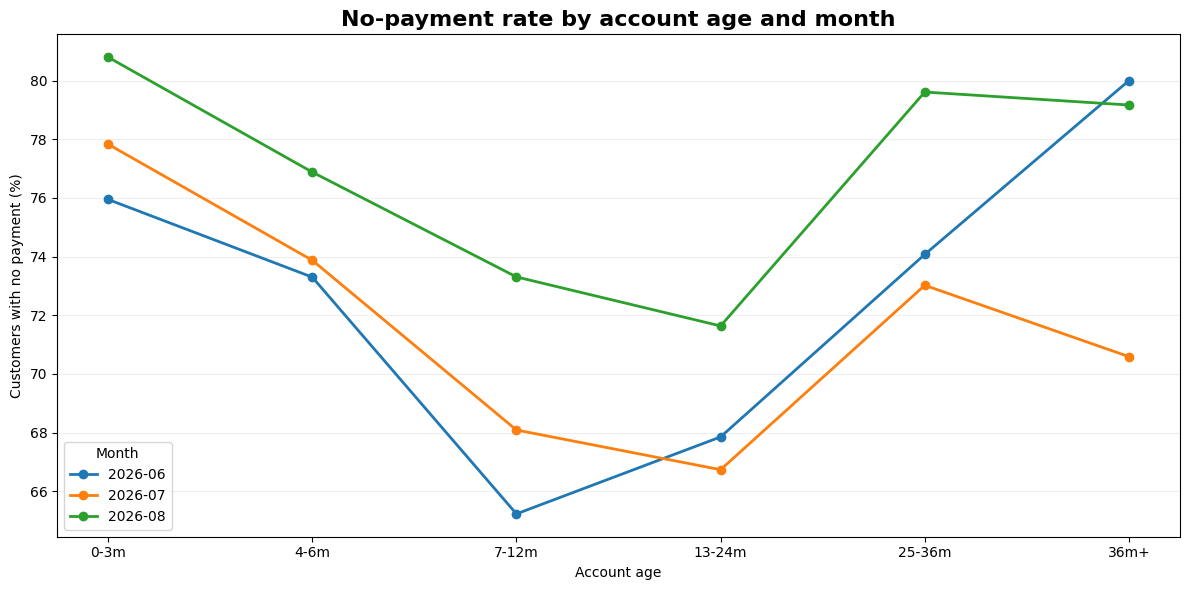

In [71]:
# ============================================================
# NO PAYMENT × ACCOUNT AGE × MONTH
# Standalone version — requires only `wa`
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)

df["account_age_months"] = pd.to_numeric(
    df["account_age_months"],
    errors="coerce"
)

df["month"] = df["sent_at"].dt.to_period("M")

df = (
    df.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)


# ------------------------------------------------------------
# 2. FIRST OBSERVATION PER CUSTOMER × MONTH
#
# Gives us:
# - account age
# - initial observed outstanding
# ------------------------------------------------------------

customer_month = (
    df.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .head(1)[
        [
            "customer_id",
            "month",
            "account_age_months",
            "outstanding_balance_brl"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# 3. DID CUSTOMER HAVE ANY PAYMENT IN THAT MONTH?
#
# For NO PAYMENT we don't need payment deduplication:
# if ANY observed amount_paid_brl > 0 exists,
# customer is not "No payment".
# ------------------------------------------------------------

payment_flag = (
    df.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        ever_paid=(
            "amount_paid_brl",
            lambda x: (x > 0).any()
        )
    )
)


customer_month = (
    customer_month
    .merge(
        payment_flag,
        on=["customer_id", "month"],
        how="left"
    )
)

customer_month["no_payment"] = (
    ~customer_month["ever_paid"]
)


# ------------------------------------------------------------
# 4. ACCOUNT AGE BUCKETS
# ------------------------------------------------------------

customer_month["account_age_bucket"] = pd.cut(
    customer_month["account_age_months"],
    bins=[
        -np.inf,
        3,
        6,
        12,
        24,
        36,
        np.inf
    ],
    labels=[
        "0-3m",
        "4-6m",
        "7-12m",
        "13-24m",
        "25-36m",
        "36m+"
    ]
)


# ------------------------------------------------------------
# 5. SUMMARY
# ------------------------------------------------------------

age_summary = (
    customer_month
    .groupby(
        ["month", "account_age_bucket"],
        observed=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        ),

        no_payment_customers=(
            "no_payment",
            "sum"
        ),

        no_payment_outstanding_brl=(
            "outstanding_balance_brl",
            lambda x: x[
                customer_month.loc[
                    x.index,
                    "no_payment"
                ]
            ].sum()
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 6. RATES
# ------------------------------------------------------------

age_summary["no_payment_customer_rate"] = (
    age_summary["no_payment_customers"]
    / age_summary["customers"]
)

age_summary["no_payment_exposure_rate"] = (
    age_summary["no_payment_outstanding_brl"]
    / age_summary["outstanding_brl"]
)


# ------------------------------------------------------------
# 7. DISPLAY
# ------------------------------------------------------------

display(
    age_summary.style.format({
        "outstanding_brl": "R$ {:,.2f}",
        "no_payment_outstanding_brl": "R$ {:,.2f}",
        "no_payment_customer_rate": "{:.1%}",
        "no_payment_exposure_rate": "{:.1%}"
    })
)


# ------------------------------------------------------------
# 8. PIVOT — EASIER MONTH-OVER-MONTH READING
# ------------------------------------------------------------

age_pivot = (
    age_summary
    .pivot(
        index="account_age_bucket",
        columns="month",
        values="no_payment_customer_rate"
    )
)

print("\nNO PAYMENT RATE — CUSTOMER LEVEL")

display(
    age_pivot.style.format("{:.1%}")
)


# ------------------------------------------------------------
# 9. GRAPH
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

for month, temp in age_summary.groupby("month"):

    temp = temp.loc[
        temp["customers"] > 0
    ]

    ax.plot(
        temp["account_age_bucket"].astype(str),
        temp["no_payment_customer_rate"] * 100,
        marker="o",
        linewidth=2,
        label=str(month)
    )

ax.set_title(
    "No-payment rate by account age and month",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Account age")
ax.set_ylabel("Customers with no payment (%)")

ax.legend(title="Month")

ax.grid(
    axis="y",
    alpha=0.20
)

plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# NO PAYMENT DIAGNOSTIC
# ACCOUNT AGE × PORTFOLIO ORIGIN × DPD × MONTH
#
# Goal:
# Is account age really explaining No Payment,
# or is the effect driven by Remaining customers / higher DPD?
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. START FROM CUSTOMER × MONTH BASE
# ------------------------------------------------------------

analysis = customer_month.copy()


# ------------------------------------------------------------
# 2. ADD DPD FROM FIRST OBSERVATION OF EACH MONTH
# ------------------------------------------------------------

first_month_state = (
    df.sort_values(["customer_id", "sent_at", "message_id"])
      .groupby(["customer_id", "month"], as_index=False)
      .head(1)[
          [
              "customer_id",
              "month",
              "days_past_due"
          ]
      ]
      .copy()
)

analysis = analysis.merge(
    first_month_state,
    on=["customer_id", "month"],
    how="left"
)


# ------------------------------------------------------------
# 3. DPD BUCKET
# ------------------------------------------------------------

def dpd_bucket(x):

    if pd.isna(x):
        return "Unknown"

    if x <= 15:
        return "1-15"

    if x <= 30:
        return "16-30"

    if x <= 60:
        return "31-60"

    return "60+"


analysis["dpd_bucket"] = (
    analysis["days_past_due"]
    .apply(dpd_bucket)
)


# ------------------------------------------------------------
# 4. NEW vs REMAINING
#
# Remaining = customer was observed in immediately
# previous month
# ------------------------------------------------------------

month_sets = {
    month: set(
        analysis.loc[
            analysis["month"] == month,
            "customer_id"
        ]
    )
    for month in analysis["month"].unique()
}


def portfolio_origin(row):

    month = row["month"]
    customer = row["customer_id"]

    previous_month = month - 1

    if customer in month_sets.get(previous_month, set()):
        return "Remaining"

    return "New"


analysis["portfolio_origin"] = (
    analysis.apply(
        portfolio_origin,
        axis=1
    )
)


# ------------------------------------------------------------
# 5. JUNE SPECIAL RULE
#
# Our observation window starts in June.
# Therefore for June:
#
# DPD <= 30 -> New
# DPD > 30  -> Remaining / pre-existing
#
# In previous analysis practically all June customers
# were classified as New.
# ------------------------------------------------------------

june = analysis["month"] == pd.Period("2026-06")

analysis.loc[
    june & (analysis["days_past_due"] <= 30),
    "portfolio_origin"
] = "New"

analysis.loc[
    june & (analysis["days_past_due"] > 30),
    "portfolio_origin"
] = "Remaining"


# ------------------------------------------------------------
# 6. FULL CROSS
# ------------------------------------------------------------

profile = (
    analysis
    .groupby(
        [
            "month",
            "portfolio_origin",
            "account_age_bucket",
            "dpd_bucket"
        ],
        observed=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        no_payment_customers=(
            "no_payment",
            "sum"
        ),

        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        ),

        no_payment_outstanding_brl=(
            "outstanding_balance_brl",
            lambda x: x[
                analysis.loc[
                    x.index,
                    "no_payment"
                ]
            ].sum()
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 7. RATES
# ------------------------------------------------------------

profile["no_payment_rate"] = (
    profile["no_payment_customers"]
    / profile["customers"]
)

profile["no_payment_exposure_rate"] = (
    profile["no_payment_outstanding_brl"]
    / profile["outstanding_brl"]
)


# ------------------------------------------------------------
# 8. REMOVE EMPTY COMBINATIONS
# ------------------------------------------------------------

profile = (
    profile.loc[
        profile["customers"] > 0
    ]
    .copy()
)


# ------------------------------------------------------------
# 9. DISPLAY COMPLETE RESULT
# ------------------------------------------------------------

display(
    profile.style.format({
        "outstanding_brl": "R$ {:,.2f}",
        "no_payment_outstanding_brl": "R$ {:,.2f}",
        "no_payment_rate": "{:.1%}",
        "no_payment_exposure_rate": "{:.1%}"
    })
)

,month,portfolio_origin,account_age_bucket,dpd_bucket,customers,no_payment_customers,outstanding_brl,no_payment_outstanding_brl,no_payment_rate,no_payment_exposure_rate
0,2026-06,New,0-3m,1-15,763,579,"R$ 662,867.40","R$ 499,700.94",75.9%,75.4%
1,2026-06,New,0-3m,16-30,2,2,"R$ 4,000.00","R$ 4,000.00",100.0%,100.0%
3,2026-06,New,4-6m,1-15,778,570,"R$ 664,938.94","R$ 502,542.00",73.3%,75.6%
4,2026-06,New,4-6m,16-30,1,1,R$ 570.79,R$ 570.79,100.0%,100.0%
6,2026-06,New,7-12m,1-15,1202,784,"R$ 995,317.91","R$ 653,168.16",65.2%,65.6%
7,2026-06,New,7-12m,16-30,3,2,"R$ 2,649.73","R$ 2,072.68",66.7%,78.2%
9,2026-06,New,13-24m,1-15,787,534,"R$ 664,278.44","R$ 464,132.46",67.9%,69.9%
12,2026-06,New,25-36m,1-15,135,100,"R$ 120,967.47","R$ 93,306.70",74.1%,77.1%
15,2026-06,New,36m+,1-15,10,8,"R$ 9,501.59","R$ 7,572.95",80.0%,79.7%
36,2026-07,New,0-3m,1-15,831,632,"R$ 688,160.98","R$ 521,640.72",76.1%,75.8%


In [73]:
# ============================================================
# AUGUST — ACCOUNT AGE × ORIGIN
# ============================================================

aug = analysis.loc[
    analysis["month"] == pd.Period("2026-08")
].copy()


aug_age_origin = (
    aug
    .groupby(
        [
            "account_age_bucket",
            "portfolio_origin"
        ],
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        no_payment_customers=("no_payment", "sum"),
        outstanding_brl=("outstanding_balance_brl", "sum"),

        no_payment_outstanding_brl=(
            "outstanding_balance_brl",
            lambda x: x[
                aug.loc[x.index, "no_payment"]
            ].sum()
        )
    )
    .reset_index()
)

aug_age_origin["no_payment_rate"] = (
    aug_age_origin["no_payment_customers"]
    / aug_age_origin["customers"]
)

aug_age_origin["no_payment_exposure_rate"] = (
    aug_age_origin["no_payment_outstanding_brl"]
    / aug_age_origin["outstanding_brl"]
)

aug_age_origin = aug_age_origin.loc[
    aug_age_origin["customers"] > 0
]


display(
    aug_age_origin.style.format({
        "outstanding_brl": "R$ {:,.2f}",
        "no_payment_outstanding_brl": "R$ {:,.2f}",
        "no_payment_rate": "{:.1%}",
        "no_payment_exposure_rate": "{:.1%}"
    })
)

,account_age_bucket,portfolio_origin,customers,no_payment_customers,outstanding_brl,no_payment_outstanding_brl,no_payment_rate,no_payment_exposure_rate
0,0-3m,New,756,576,"R$ 627,521.55","R$ 495,094.39",76.2%,78.9%
1,0-3m,Remaining,999,842,"R$ 790,983.79","R$ 676,888.45",84.3%,85.6%
2,4-6m,New,898,640,"R$ 774,625.82","R$ 572,814.26",71.3%,73.9%
3,4-6m,Remaining,1083,883,"R$ 884,472.07","R$ 744,661.86",81.5%,84.2%
4,7-12m,New,1300,874,"R$ 1,132,385.95","R$ 781,105.91",67.2%,69.0%
5,7-12m,Remaining,1446,1139,"R$ 1,138,456.74","R$ 922,931.39",78.8%,81.1%
6,13-24m,New,778,485,"R$ 663,301.87","R$ 427,837.95",62.3%,64.5%
7,13-24m,Remaining,953,755,"R$ 756,735.95","R$ 600,931.94",79.2%,79.4%
8,25-36m,New,163,122,"R$ 144,480.12","R$ 108,468.61",74.8%,75.1%
9,25-36m,Remaining,195,163,"R$ 155,931.90","R$ 134,385.33",83.6%,86.2%


In [74]:
# ============================================================
# EARLY COLLECTION EFFECTIVENESS BY MONTH
#
# Question:
# Among customers observed in DPD 1-15,
# how many made their FIRST payment within the first 5 contacts?
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["days_past_due"] = pd.to_numeric(
    df["days_past_due"], errors="coerce"
)
df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"], errors="coerce"
).fillna(0)

df["month"] = df["sent_at"].dt.to_period("M")

df = (
    df.sort_values(
        ["customer_id", "month", "sent_at", "message_id"]
    )
    .copy()
)

# Contact number INSIDE each month
df["contact_number_month"] = (
    df.groupby(["customer_id", "month"])
      .cumcount()
      .add(1)
)


# ------------------------------------------------------------
# 1. Population:
# customers observed in DPD 1-15 during that month
# ------------------------------------------------------------

early = df.loc[
    df["days_past_due"].between(1, 15)
].copy()


# ------------------------------------------------------------
# 2. Customer × month population
# ------------------------------------------------------------

early_population = (
    early.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        first_dpd=("days_past_due", "first"),
        max_dpd_observed=("days_past_due", "max"),
        contacts_while_dpd_1_15=("message_id", "size")
    )
)


# ------------------------------------------------------------
# 3. First observed payment while still DPD 1-15
# ------------------------------------------------------------

payments_early = (
    early.loc[
        early["amount_paid_brl"] > 0
    ]
    .sort_values(
        ["customer_id", "month", "sent_at", "message_id"]
    )
    .groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .head(1)
    [
        [
            "customer_id",
            "month",
            "contact_number_month",
            "days_past_due",
            "amount_paid_brl"
        ]
    ]
    .rename(
        columns={
            "contact_number_month":
                "contact_number_at_first_payment",
            "days_past_due":
                "dpd_at_first_payment"
        }
    )
)


# ------------------------------------------------------------
# 4. Merge
# ------------------------------------------------------------

early_population = (
    early_population
    .merge(
        payments_early,
        on=["customer_id", "month"],
        how="left"
    )
)


early_population["paid_while_dpd_1_15"] = (
    early_population[
        "contact_number_at_first_payment"
    ].notna()
)

early_population["paid_within_5_contacts"] = (
    early_population[
        "contact_number_at_first_payment"
    ].le(5)
)


# ------------------------------------------------------------
# 5. Monthly summary
# ------------------------------------------------------------

monthly_early = (
    early_population
    .groupby("month", as_index=False)
    .agg(
        customers_dpd_1_15=(
            "customer_id",
            "nunique"
        ),

        paid_while_dpd_1_15=(
            "paid_while_dpd_1_15",
            "sum"
        ),

        paid_within_5_contacts=(
            "paid_within_5_contacts",
            "sum"
        )
    )
)


monthly_early["pct_paid_while_dpd_1_15"] = (
    monthly_early["paid_while_dpd_1_15"]
    / monthly_early["customers_dpd_1_15"]
)

monthly_early["pct_paid_within_5_contacts"] = (
    monthly_early["paid_within_5_contacts"]
    / monthly_early["customers_dpd_1_15"]
)


display(
    monthly_early.style.format({
        "pct_paid_while_dpd_1_15": "{:.1%}",
        "pct_paid_within_5_contacts": "{:.1%}"
    })
)

,month,customers_dpd_1_15,paid_while_dpd_1_15,paid_within_5_contacts,pct_paid_while_dpd_1_15,pct_paid_within_5_contacts
0,2026-06,3675,1000,963,27.2%,26.2%
1,2026-07,5222,1323,1266,25.3%,24.2%
2,2026-08,4904,1260,1217,25.7%,24.8%


In [75]:
# ============================================================
# AMONG CUSTOMERS WHO SETTLED EACH MONTH:
# HOW MANY SETTLED AT DPD 1-15 AND WITH <= 5 CONTACTS?
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["month"] = df["sent_at"].dt.to_period("M")

df["days_past_due"] = pd.to_numeric(
    df["days_past_due"], errors="coerce"
)

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"], errors="coerce"
).fillna(0)

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"], errors="coerce"
)

df["discount_offer_flag"] = (
    df["template"]
    .astype(str)
    .str.contains("discount_offer", case=False, na=False)
)

df = (
    df.sort_values(
        ["customer_id", "month", "sent_at", "message_id"]
    )
    .copy()
)

# Contact number within each month
df["contact_number_month"] = (
    df.groupby(["customer_id", "month"])
      .cumcount()
      .add(1)
)


# ------------------------------------------------------------
# 1. Identify settlement event
#
# Normal message:
# payment >= 100% outstanding
#
# Discount offer:
# payment >= 85% outstanding
# ------------------------------------------------------------

df["settlement_threshold"] = np.where(
    df["discount_offer_flag"],
    df["outstanding_balance_brl"] * 0.85,
    df["outstanding_balance_brl"]
)

df["settled_event"] = (
    df["amount_paid_brl"]
    >=
    (df["settlement_threshold"] - 0.05)
)


# ------------------------------------------------------------
# 2. First settlement event per customer × month
# ------------------------------------------------------------

settled = (
    df.loc[df["settled_event"]]
      .sort_values(
          ["customer_id", "month", "sent_at", "message_id"]
      )
      .groupby(
          ["customer_id", "month"],
          as_index=False
      )
      .head(1)
      .copy()
)


# ------------------------------------------------------------
# 3. Target condition
#
# At settlement:
# DPD 1-15
# AND <=5 messages in that month
# ------------------------------------------------------------

settled["early_settlement"] = (
    settled["days_past_due"].between(1, 15)
    &
    settled["contact_number_month"].le(5)
)


# ------------------------------------------------------------
# 4. Monthly summary
# ------------------------------------------------------------

summary = (
    settled
    .groupby("month", as_index=False)
    .agg(
        total_settled_customers=(
            "customer_id",
            "nunique"
        ),

        settled_dpd_1_15_and_le5=(
            "early_settlement",
            "sum"
        )
    )
)

summary["pct_settled_dpd_1_15_and_le5"] = (
    summary["settled_dpd_1_15_and_le5"]
    /
    summary["total_settled_customers"]
)


display(
    summary.style.format({
        "pct_settled_dpd_1_15_and_le5": "{:.1%}"
    })
)

,month,total_settled_customers,settled_dpd_1_15_and_le5,pct_settled_dpd_1_15_and_le5
0,2026-06,763,656,86.0%
1,2026-07,1412,847,60.0%
2,2026-08,1466,806,55.0%


_________________________________________________________________________________________________________________________________________________________________________________________________________

_________________________________________________________________________________________________________________________________________________________________________________________________________

_________________________________________________________________________________________________________________________________________________________________________________________________________

## NET RECOVERY TOTAL : WHATSAPP.CSV

In [100]:
# ============================================================
# WA — INITIAL OUTSTANDING vs DISTINCT OBSERVED RECOVERY
# Customer grain
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

# ============================================================
# 1. INITIAL OBSERVED OUTSTANDING
# First balance observed for each customer
# ============================================================

first_customer_observation = (
    df.groupby("customer_id", as_index=False)
      .first()
)

initial_outstanding = (
    pd.to_numeric(
        first_customer_observation["outstanding_balance_brl"],
        errors="coerce"
    )
    .fillna(0)
    .sum()
)

n_customers = (
    first_customer_observation["customer_id"]
    .nunique()
)

# ============================================================
# 2. PAYMENT OBSERVATIONS
# ============================================================

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)

payments = (
    df.loc[df["amount_paid_brl"] > 0]
      .copy()
)

# ============================================================
# 3. REMOVE POSSIBLE DUPLICATION CAUSED BY 72H ATTRIBUTION
#
# Same customer + same payment amount can appear in overlapping
# attribution windows.
#
# We collapse consecutive repeated observations of the same
# payment amount within 72 hours.
# ============================================================

payments = payments.sort_values(
    ["customer_id", "sent_at"]
).copy()

payments["previous_payment_at"] = (
    payments.groupby(
        ["customer_id", "amount_paid_brl"]
    )["sent_at"]
    .shift()
)

payments["hours_since_same_payment"] = (
    (
        payments["sent_at"]
        - payments["previous_payment_at"]
    )
    .dt.total_seconds()
    / 3600
)

# A payment is considered a NEW distinct recovery when:
# - it is the first occurrence of that amount for the customer, OR
# - the same amount appears more than 72h later

payments["distinct_payment"] = (
    payments["previous_payment_at"].isna()
    |
    (payments["hours_since_same_payment"] > 72)
)

distinct_payments = (
    payments.loc[
        payments["distinct_payment"]
    ]
    .copy()
)

# ============================================================
# 4. DISTINCT RECOVERY
# ============================================================

total_recovered = (
    distinct_payments["amount_paid_brl"]
    .sum()
)

customers_with_recovery = (
    distinct_payments["customer_id"]
    .nunique()
)

n_distinct_payments = len(
    distinct_payments
)

# Raw value BEFORE deduplication
raw_attributed_payment = (
    payments["amount_paid_brl"]
    .sum()
)

duplicated_attribution_removed = (
    raw_attributed_payment
    - total_recovered
)

# ============================================================
# 5. RECOVERY RATE
# ============================================================

recovery_rate = (
    total_recovered / initial_outstanding
    if initial_outstanding > 0
    else np.nan
)

# ============================================================
# 6. RESULTS
# ============================================================

print("=" * 80)
print("WHATSAPP COLLECTIONS — ECONOMIC RECONSTRUCTION")
print("=" * 80)

print("\nPOPULATION")
print(
    f"Unique customers                     : "
    f"{n_customers:,}"
)

print("\nINITIAL OBSERVED EXPOSURE")
print(
    f"Initial outstanding balance           : "
    f"R$ {initial_outstanding:,.2f}"
)

print("\nPAYMENT ATTRIBUTION")

print(
    f"Raw attributed payments               : "
    f"R$ {raw_attributed_payment:,.2f}"
)

print(
    f"Potential duplicated attribution removed: "
    f"R$ {duplicated_attribution_removed:,.2f}"
)

print(
    f"Distinct payment events               : "
    f"{n_distinct_payments:,}"
)

print(
    f"Customers with observed recovery      : "
    f"{customers_with_recovery:,}"
)

print("\nRECOVERY")

print(
    f"Distinct observed recovery             : "
    f"R$ {total_recovered:,.2f}"
)

print(
    f"Recovery / initial observed balance    : "
    f"{recovery_rate:.1%}"
)

print(
    f"Unrecovered initial exposure           : "
    f"R$ {initial_outstanding - total_recovered:,.2f}"
)

WHATSAPP COLLECTIONS — ECONOMIC RECONSTRUCTION

POPULATION
Unique customers                     : 11,724

INITIAL OBSERVED EXPOSURE
Initial outstanding balance           : R$ 9,965,540.33

PAYMENT ATTRIBUTION
Raw attributed payments               : R$ 3,459,305.30
Potential duplicated attribution removed: R$ 0.00
Distinct payment events               : 5,626
Customers with observed recovery      : 4,893

RECOVERY
Distinct observed recovery             : R$ 3,459,305.30
Recovery / initial observed balance    : 34.7%
Unrecovered initial exposure           : R$ 6,506,235.03


In [101]:
# ============================================================
# NET RECOVERY AFTER WHATSAPP COST
# Assumption: R$ 1.00 per message sent
# ============================================================

COST_PER_MESSAGE = 1.00

# ------------------------------------------------------------
# 1. Total WhatsApp messages / attempts
# ------------------------------------------------------------

total_messages = len(df)

# ------------------------------------------------------------
# 2. Total collection cost
# ------------------------------------------------------------

total_whatsapp_cost = (
    total_messages * COST_PER_MESSAGE
)

# ------------------------------------------------------------
# 3. Gross recovery
# Already deduplicated in previous analysis
# ------------------------------------------------------------

gross_recovery = total_recovered

# ------------------------------------------------------------
# 4. Net recovery
# ------------------------------------------------------------

net_recovery = (
    gross_recovery
    - total_whatsapp_cost
)

# ------------------------------------------------------------
# 5. Gross and net recovery rates
# ------------------------------------------------------------

gross_recovery_rate = (
    gross_recovery / initial_outstanding
    if initial_outstanding > 0
    else np.nan
)

net_recovery_rate = (
    net_recovery / initial_outstanding
    if initial_outstanding > 0
    else np.nan
)

# ------------------------------------------------------------
# 6. Cost efficiency
# ------------------------------------------------------------

cost_per_recovered_brl = (
    total_whatsapp_cost / gross_recovery
    if gross_recovery > 0
    else np.nan
)

recovery_per_brl_spent = (
    gross_recovery / total_whatsapp_cost
    if total_whatsapp_cost > 0
    else np.nan
)

cost_as_pct_of_recovery = (
    total_whatsapp_cost / gross_recovery
    if gross_recovery > 0
    else np.nan
)

# ------------------------------------------------------------
# 7. Results
# ------------------------------------------------------------

print("=" * 80)
print("WHATSAPP COLLECTIONS — NET RECOVERY")
print("=" * 80)

print("\nPORTFOLIO")

print(
    f"Initial observed outstanding       : "
    f"R$ {initial_outstanding:,.2f}"
)

print(
    f"Gross observed recovery            : "
    f"R$ {gross_recovery:,.2f}"
)

print("\nWHATSAPP COST")

print(
    f"Messages sent                      : "
    f"{total_messages:,}"
)

print(
    f"Cost per message                   : "
    f"R$ {COST_PER_MESSAGE:,.2f}"
)

print(
    f"Total WhatsApp cost                : "
    f"R$ {total_whatsapp_cost:,.2f}"
)

print("\nNET RECOVERY")

print(
    f"Gross recovery                     : "
    f"R$ {gross_recovery:,.2f}"
)

print(
    f"(-) WhatsApp cost                  : "
    f"R$ {total_whatsapp_cost:,.2f}"
)

print(
    f"NET RECOVERY                       : "
    f"R$ {net_recovery:,.2f}"
)

print("\nRECOVERY RATES")

print(
    f"Gross recovery rate                : "
    f"{gross_recovery_rate:.1%}"
)

print(
    f"Net recovery rate                  : "
    f"{net_recovery_rate:.1%}"
)

print("\nCOST EFFICIENCY")

print(
    f"Cost as % of gross recovery        : "
    f"{cost_as_pct_of_recovery:.2%}"
)

print(
    f"Cost per R$1 recovered             : "
    f"R$ {cost_per_recovered_brl:.4f}"
)

print(
    f"Gross recovery per R$1 spent       : "
    f"R$ {recovery_per_brl_spent:,.2f}"
)

WHATSAPP COLLECTIONS — NET RECOVERY

PORTFOLIO
Initial observed outstanding       : R$ 9,965,540.33
Gross observed recovery            : R$ 3,459,305.30

WHATSAPP COST
Messages sent                      : 75,406
Cost per message                   : R$ 1.00
Total WhatsApp cost                : R$ 75,406.00

NET RECOVERY
Gross recovery                     : R$ 3,459,305.30
(-) WhatsApp cost                  : R$ 75,406.00
NET RECOVERY                       : R$ 3,383,899.30

RECOVERY RATES
Gross recovery rate                : 34.7%
Net recovery rate                  : 34.0%

COST EFFICIENCY
Cost as % of gross recovery        : 2.18%
Cost per R$1 recovered             : R$ 0.0218
Gross recovery per R$1 spent       : R$ 45.88


_________________________________________________________________________________________________________________________________________________________________________________________________________

_________________________________________________________________________________________________________________________________________________________________________________________________________

_________________________________________________________________________________________________________________________________________________________________________________________________________

## MONTHLY VIEW

In [102]:
# ============================================================
# MONTHLY COLLECTIONS VIEW
#
# Metrics:
# 1. Observed outstanding balance
#    = first balance observed per customer within each month
#
# 2. Distinct observed recovery
#    = deduplicated payment events using 72h rule
#
# 3. Messages sent
#    = all WA send attempts within each month
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

# ------------------------------------------------------------
# 1. Month
# ------------------------------------------------------------

df["month"] = (
    df["sent_at"]
    .dt.to_period("M")
)

# Numeric fields

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)


# ============================================================
# 2. MONTHLY OBSERVED OUTSTANDING
#
# First observed balance PER CUSTOMER PER MONTH
# ============================================================

first_monthly_observation = (
    df.sort_values(
        ["customer_id", "month", "sent_at", "message_id"]
    )
    .groupby(
        ["month", "customer_id"],
        as_index=False
    )
    .first()
)

monthly_outstanding = (
    first_monthly_observation
    .groupby("month", as_index=False)
    .agg(
        customers_observed=(
            "customer_id",
            "nunique"
        ),
        observed_outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
)


# ============================================================
# 3. MONTHLY MESSAGES
# ============================================================

monthly_messages = (
    df.groupby("month", as_index=False)
      .agg(
          messages_sent=(
              "message_id",
              "size"
          ),
          customers_contacted=(
              "customer_id",
              "nunique"
          )
      )
)


# ============================================================
# 4. PAYMENT OBSERVATIONS
# ============================================================

payments = (
    df.loc[
        df["amount_paid_brl"] > 0
    ]
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)


# ============================================================
# 5. DEDUPLICATE POSSIBLE 72H ATTRIBUTION
#
# Same logic used previously:
# same customer + same payment amount within <=72h
# is treated as the same economic payment event.
# ============================================================

payments["previous_payment_at"] = (
    payments
    .groupby(
        ["customer_id", "amount_paid_brl"]
    )["sent_at"]
    .shift()
)

payments["hours_since_same_payment"] = (
    (
        payments["sent_at"]
        - payments["previous_payment_at"]
    )
    .dt.total_seconds()
    / 3600
)

payments["distinct_payment"] = (
    payments["previous_payment_at"].isna()
    |
    (
        payments["hours_since_same_payment"]
        > 72
    )
)

distinct_payments = (
    payments.loc[
        payments["distinct_payment"]
    ]
    .copy()
)


# ============================================================
# 6. MONTHLY RECOVERY
# ============================================================

monthly_recovery = (
    distinct_payments
    .groupby("month", as_index=False)
    .agg(
        distinct_payment_events=(
            "amount_paid_brl",
            "size"
        ),
        customers_with_recovery=(
            "customer_id",
            "nunique"
        ),
        observed_recovery_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)


# ============================================================
# 7. COMBINE MONTHLY VIEW
# ============================================================

monthly = (
    monthly_outstanding
    .merge(
        monthly_recovery,
        on="month",
        how="outer"
    )
    .merge(
        monthly_messages,
        on="month",
        how="outer"
    )
    .sort_values("month")
    .fillna(0)
)


# ============================================================
# 8. COST OF MESSAGES
# ============================================================

COST_PER_MESSAGE = 1.00

monthly["messaging_cost_brl"] = (
    monthly["messages_sent"]
    * COST_PER_MESSAGE
)


# ============================================================
# 9. NET ATTRIBUTED RECOVERY
# ============================================================

monthly["net_observed_recovery_brl"] = (
    monthly["observed_recovery_brl"]
    - monthly["messaging_cost_brl"]
)


# ============================================================
# 10. DESCRIPTIVE RATES
# ============================================================

monthly["observed_recovery_rate"] = (
    monthly["observed_recovery_brl"]
    / monthly["observed_outstanding_brl"]
)

monthly["net_observed_recovery_rate"] = (
    monthly["net_observed_recovery_brl"]
    / monthly["observed_outstanding_brl"]
)

monthly["messages_per_customer"] = (
    monthly["messages_sent"]
    / monthly["customers_contacted"]
)

monthly["recovery_per_message_brl"] = (
    monthly["observed_recovery_brl"]
    / monthly["messages_sent"]
)


# ============================================================
# 11. DISPLAY
# ============================================================

monthly["month"] = (
    monthly["month"]
    .astype(str)
)

display(
    monthly[
        [
            "month",
            "customers_observed",
            "observed_outstanding_brl",
            "observed_recovery_brl",
            "messages_sent",
            "messaging_cost_brl",
            "net_observed_recovery_brl",
            "observed_recovery_rate",
            "net_observed_recovery_rate",
            "messages_per_customer",
            "customers_with_recovery",
            "distinct_payment_events"
        ]
    ]
)

,month,customers_observed,observed_outstanding_brl,observed_recovery_brl,messages_sent,messaging_cost_brl,net_observed_recovery_brl,observed_recovery_rate,net_observed_recovery_rate,messages_per_customer,customers_with_recovery,distinct_payment_events
0,2026-06,3681,"3,125,092.27","774,043.04",14465,"14,465.00","759,578.04",0.25,0.24,3.93,1101,1202
1,2026-07,7030,"5,821,919.81","1,340,671.98",29716,"29,716.00","1,310,955.98",0.23,0.23,4.23,2016,2177
2,2026-08,8595,"7,091,209.83","1,344,590.28",31225,"31,225.00","1,313,365.28",0.19,0.19,3.63,2097,2247


In [103]:
# ============================================================
# MONTHLY CUSTOMER FLOW
# New vs Remaining customers
# ============================================================

import pandas as pd

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["month"] = df["sent_at"].dt.to_period("M")

# ------------------------------------------------------------
# 1. Unique customers observed in each month
# ------------------------------------------------------------

monthly_customers = (
    df[["customer_id", "month"]]
    .drop_duplicates()
)

# Customer sets

jun = set(
    monthly_customers.loc[
        monthly_customers["month"] == pd.Period("2026-06"),
        "customer_id"
    ]
)

jul = set(
    monthly_customers.loc[
        monthly_customers["month"] == pd.Period("2026-07"),
        "customer_id"
    ]
)

aug = set(
    monthly_customers.loc[
        monthly_customers["month"] == pd.Period("2026-08"),
        "customer_id"
    ]
)


# ============================================================
# 2. JULY
# ============================================================

jul_remaining = jul & jun
jul_new = jul - jun

# Customers from June that disappeared in July
jun_not_in_jul = jun - jul


# ============================================================
# 3. AUGUST
# ============================================================

aug_remaining = aug & jul
aug_new = aug - jul

# Customers from July that disappeared in August
jul_not_in_aug = jul - aug


# ============================================================
# 4. SUMMARY
# ============================================================

monthly_flow = pd.DataFrame({

    "month": [
        "2026-06",
        "2026-07",
        "2026-08"
    ],

    "total_customers": [
        len(jun),
        len(jul),
        len(aug)
    ],

    "remaining_from_previous_month": [
        0,
        len(jul_remaining),
        len(aug_remaining)
    ],

    "new_vs_previous_month": [
        len(jun),  # first observed month
        len(jul_new),
        len(aug_new)
    ]

})


# ============================================================
# 5. PERCENTAGES
# ============================================================

monthly_flow["remaining_pct"] = (
    monthly_flow["remaining_from_previous_month"]
    / monthly_flow["total_customers"]
)

monthly_flow["new_pct"] = (
    monthly_flow["new_vs_previous_month"]
    / monthly_flow["total_customers"]
)


# ============================================================
# 6. DISPLAY
# ============================================================

display(monthly_flow)


# ============================================================
# 7. BUSINESS PRINT
# ============================================================

print("=" * 80)
print("MONTHLY CUSTOMER FLOW")
print("=" * 80)

print("\nJULY")
print(f"Total customers                     : {len(jul):,}")
print(
    f"Remaining from June                 : "
    f"{len(jul_remaining):,} "
    f"({len(jul_remaining)/len(jul):.1%})"
)
print(
    f"New in July                         : "
    f"{len(jul_new):,} "
    f"({len(jul_new)/len(jul):.1%})"
)
print(
    f"June customers not observed in July : "
    f"{len(jun_not_in_jul):,}"
)


print("\nAUGUST")
print(f"Total customers                     : {len(aug):,}")
print(
    f"Remaining from July                 : "
    f"{len(aug_remaining):,} "
    f"({len(aug_remaining)/len(aug):.1%})"
)
print(
    f"New in August                       : "
    f"{len(aug_new):,} "
    f"({len(aug_new)/len(aug):.1%})"
)
print(
    f"July customers not observed in Aug  : "
    f"{len(jul_not_in_aug):,}"
)

,month,total_customers,remaining_from_previous_month,new_vs_previous_month,remaining_pct,new_pct
0,2026-06,3681,0,3681,0.00,1.00
1,2026-07,7030,2875,4155,0.41,0.59
2,2026-08,8595,4688,3907,0.55,0.45


MONTHLY CUSTOMER FLOW

JULY
Total customers                     : 7,030
Remaining from June                 : 2,875 (40.9%)
New in July                         : 4,155 (59.1%)
June customers not observed in July : 806

AUGUST
Total customers                     : 8,595
Remaining from July                 : 4,688 (54.5%)
New in August                       : 3,907 (45.5%)
July customers not observed in Aug  : 2,342


In [105]:
# ============================================================
# MONTHLY CUSTOMER FLOW
# New vs Remaining customers
# + Observed Outstanding Balance
#
# Balance rule:
# First outstanding balance observed per customer in each month
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["month"] = df["sent_at"].dt.to_period("M")

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)

df = df.sort_values(
    ["customer_id", "sent_at", "message_id"]
).copy()


# ============================================================
# 1. FIRST OBSERVATION PER CUSTOMER × MONTH
# ============================================================

first_monthly = (
    df.sort_values(
        ["customer_id", "month", "sent_at", "message_id"]
    )
    .groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .head(1)
    .copy()
)


# ============================================================
# 2. CUSTOMER SETS
# ============================================================

jun = set(
    first_monthly.loc[
        first_monthly["month"] == pd.Period("2026-06"),
        "customer_id"
    ]
)

jul = set(
    first_monthly.loc[
        first_monthly["month"] == pd.Period("2026-07"),
        "customer_id"
    ]
)

aug = set(
    first_monthly.loc[
        first_monthly["month"] == pd.Period("2026-08"),
        "customer_id"
    ]
)


# ============================================================
# 3. JULY
# ============================================================

jul_remaining = jul & jun
jul_new = jul - jun

jun_not_in_jul = jun - jul


# ============================================================
# 4. AUGUST
# ============================================================

aug_remaining = aug & jul
aug_new = aug - jul

jul_not_in_aug = jul - aug


# ============================================================
# 5. CLASSIFY CUSTOMER × MONTH
# ============================================================

def classify_customer(row):

    customer = row["customer_id"]
    month = row["month"]

    # June:
    # Previous analysis showed 100% DPD <= 30
    if month == pd.Period("2026-06"):
        return "New"

    # July
    elif month == pd.Period("2026-07"):

        if customer in jul_remaining:
            return "Remaining"

        return "New"

    # August
    elif month == pd.Period("2026-08"):

        if customer in aug_remaining:
            return "Remaining"

        return "New"

    return "Other"


first_monthly["customer_origin"] = (
    first_monthly.apply(
        classify_customer,
        axis=1
    )
)


# ============================================================
# 6. CUSTOMER + OUTSTANDING SUMMARY
# ============================================================

monthly_flow_detail = (
    first_monthly
    .groupby(
        ["month", "customer_origin"],
        as_index=False
    )
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        observed_outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        ),

        avg_outstanding_brl=(
            "outstanding_balance_brl",
            "mean"
        )
    )
)


# ============================================================
# 7. MONTH TOTALS
# ============================================================

month_totals = (
    monthly_flow_detail
    .groupby("month")
    .agg(
        total_customers=(
            "customers",
            "sum"
        ),

        total_outstanding_brl=(
            "observed_outstanding_brl",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 8. ADD SHARES
# ============================================================

monthly_flow_detail = (
    monthly_flow_detail
    .merge(
        month_totals,
        on="month",
        how="left"
    )
)

monthly_flow_detail["pct_customers"] = (
    monthly_flow_detail["customers"]
    / monthly_flow_detail["total_customers"]
)

monthly_flow_detail["pct_outstanding"] = (
    monthly_flow_detail["observed_outstanding_brl"]
    / monthly_flow_detail["total_outstanding_brl"]
)


# ============================================================
# 9. FINAL TABLE
# ============================================================

monthly_flow_detail["month"] = (
    monthly_flow_detail["month"]
    .astype(str)
)

monthly_flow_detail = (
    monthly_flow_detail[
        [
            "month",
            "customer_origin",
            "customers",
            "pct_customers",
            "observed_outstanding_brl",
            "pct_outstanding",
            "avg_outstanding_brl"
        ]
    ]
    .sort_values(
        ["month", "customer_origin"]
    )
)

display(monthly_flow_detail)


# ============================================================
# 10. BUSINESS PRINT
# ============================================================

print("=" * 90)
print("MONTHLY CUSTOMER FLOW — NEW vs REMAINING")
print("=" * 90)

for month in ["2026-06", "2026-07", "2026-08"]:

    month_data = monthly_flow_detail.loc[
        monthly_flow_detail["month"] == month
    ]

    print(f"\n{month}")
    print("-" * 90)

    for _, row in month_data.iterrows():

        print(
            f"{row['customer_origin']:<12} | "
            f"Customers: {int(row['customers']):>6,} "
            f"({row['pct_customers']:.1%}) | "
            f"Outstanding: R$ {row['observed_outstanding_brl']:>12,.2f} "
            f"({row['pct_outstanding']:.1%}) | "
            f"Avg balance: R$ {row['avg_outstanding_brl']:>9,.2f}"
        )

    print("-" * 90)

    print(
        f"{'TOTAL':<12} | "
        f"Customers: {int(month_data['customers'].sum()):>6,} | "
        f"Outstanding: R$ "
        f"{month_data['observed_outstanding_brl'].sum():>12,.2f}"
    )

,month,customer_origin,customers,pct_customers,observed_outstanding_brl,pct_outstanding,avg_outstanding_brl
0,2026-06,New,3681,1.00,"3,125,092.27",1.00,848.98
1,2026-07,New,4155,0.59,"3,501,007.03",0.60,842.60
2,2026-07,Remaining,2875,0.41,"2,320,912.78",0.40,807.27
3,2026-08,New,3907,0.45,"3,352,625.22",0.47,858.11
4,2026-08,Remaining,4688,0.55,"3,738,584.61",0.53,797.48


MONTHLY CUSTOMER FLOW — NEW vs REMAINING

2026-06
------------------------------------------------------------------------------------------
New          | Customers:  3,681 (100.0%) | Outstanding: R$ 3,125,092.27 (100.0%) | Avg balance: R$    848.98
------------------------------------------------------------------------------------------
TOTAL        | Customers:  3,681 | Outstanding: R$ 3,125,092.27

2026-07
------------------------------------------------------------------------------------------
New          | Customers:  4,155 (59.1%) | Outstanding: R$ 3,501,007.03 (60.1%) | Avg balance: R$    842.60
Remaining    | Customers:  2,875 (40.9%) | Outstanding: R$ 2,320,912.78 (39.9%) | Avg balance: R$    807.27
------------------------------------------------------------------------------------------
TOTAL        | Customers:  7,030 | Outstanding: R$ 5,821,919.81

2026-08
------------------------------------------------------------------------------------------
New          | Customer

In [104]:
# ============================================================
# JUNE — NEW vs REMAINING
#
# Business rule:
# DPD at first observed June contact <= 30 -> New
# DPD at first observed June contact > 30  -> Remaining
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

# ------------------------------------------------------------
# 1. June population
# ------------------------------------------------------------

june = (
    df.loc[
        df["sent_at"].dt.to_period("M")
        == pd.Period("2026-06")
    ]
    .copy()
)

# ------------------------------------------------------------
# 2. Literal FIRST observed contact in June
# ------------------------------------------------------------

june_first = (
    june.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .groupby(
        "customer_id",
        as_index=False
    )
    .head(1)
    .copy()
)

june_first["days_past_due"] = pd.to_numeric(
    june_first["days_past_due"],
    errors="coerce"
)

# ------------------------------------------------------------
# 3. Classification
# ------------------------------------------------------------

june_first["customer_origin"] = np.select(
    [
        june_first["days_past_due"] <= 30,
        june_first["days_past_due"] > 30
    ],
    [
        "New",
        "Remaining"
    ],
    default="Unknown"
)

# ------------------------------------------------------------
# 4. Summary
# ------------------------------------------------------------

june_origin = (
    june_first
    .groupby(
        "customer_origin",
        as_index=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        )
    )
)

total_june = june_first["customer_id"].nunique()

june_origin["pct_customers"] = (
    june_origin["customers"]
    / total_june
)

# ------------------------------------------------------------
# 5. Display
# ------------------------------------------------------------

display(june_origin)

print("=" * 70)
print("JUNE CUSTOMER ORIGIN — INFERRED FROM DPD")
print("=" * 70)

print(f"\nTotal June customers : {total_june:,}")

for _, row in june_origin.iterrows():
    print(
        f"{row['customer_origin']:<12}: "
        f"{int(row['customers']):,} "
        f"({row['pct_customers']:.1%})"
    )

,customer_origin,customers,pct_customers
0,New,3681,1.00


JUNE CUSTOMER ORIGIN — INFERRED FROM DPD

Total June customers : 3,681
New         : 3,681 (100.0%)


In [106]:
# ============================================================
# MONTHLY PAYMENT OUTCOME
#
# Customer × Month grain
#
# Groups:
# 1. Settled
#    - 100% of observed balance, OR
#    - >= 85% when customer received discount_offer
#
# 2. Partial payment
#    - payment > 0 but below settlement threshold
#
# 3. No payment
#    - no observed payment
# ============================================================

import pandas as pd
import numpy as np

TOLERANCE_BRL = 0.05
DISCOUNT_SETTLEMENT_RATE = 0.85

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["month"] = df["sent_at"].dt.to_period("M")

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)

df = (
    df.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)


# ============================================================
# 1. FIRST OBSERVED BALANCE
# Customer × Month
# ============================================================

monthly_customer = (
    df.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .head(1)[
        [
            "customer_id",
            "month",
            "outstanding_balance_brl"
        ]
    ]
    .rename(
        columns={
            "outstanding_balance_brl":
                "initial_monthly_balance_brl"
        }
    )
    .copy()
)


# ============================================================
# 2. DISCOUNT OFFER DURING MONTH
# ============================================================

df["discount_offer_flag"] = (
    df["template"]
    .astype(str)
    .str.contains(
        "discount_offer",
        case=False,
        na=False
    )
)

monthly_discount = (
    df.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        received_discount_offer=(
            "discount_offer_flag",
            "max"
        )
    )
)

monthly_customer = (
    monthly_customer
    .merge(
        monthly_discount,
        on=["customer_id", "month"],
        how="left"
    )
)


# ============================================================
# 3. PAYMENT EVENTS
# ============================================================

payments = (
    df.loc[
        df["amount_paid_brl"] > 0
    ]
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)


# ============================================================
# 4. DEDUPLICATE POSSIBLE 72H ATTRIBUTION
#
# Same customer + same amount appearing again <=72h
# treated as same economic payment event.
# ============================================================

payments["previous_payment_at"] = (
    payments
    .groupby(
        ["customer_id", "amount_paid_brl"]
    )["sent_at"]
    .shift()
)

payments["hours_since_same_payment"] = (
    (
        payments["sent_at"]
        - payments["previous_payment_at"]
    )
    .dt.total_seconds()
    / 3600
)

payments["distinct_payment"] = (
    payments["previous_payment_at"].isna()
    |
    (
        payments["hours_since_same_payment"] > 72
    )
)

distinct_payments = (
    payments.loc[
        payments["distinct_payment"]
    ]
    .copy()
)


# ============================================================
# 5. TOTAL DISTINCT PAYMENT
# Customer × Month
# ============================================================

monthly_payment = (
    distinct_payments
    .groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        total_payment_brl=(
            "amount_paid_brl",
            "sum"
        ),

        distinct_payment_events=(
            "amount_paid_brl",
            "size"
        )
    )
)


monthly_customer = (
    monthly_customer
    .merge(
        monthly_payment,
        on=["customer_id", "month"],
        how="left"
    )
)

monthly_customer[
    "total_payment_brl"
] = (
    monthly_customer[
        "total_payment_brl"
    ]
    .fillna(0)
)

monthly_customer[
    "distinct_payment_events"
] = (
    monthly_customer[
        "distinct_payment_events"
    ]
    .fillna(0)
)


# ============================================================
# 6. SETTLEMENT THRESHOLD
#
# Discount offer -> 85%
# Otherwise      -> 100%
# ============================================================

monthly_customer["settlement_rate"] = np.where(
    monthly_customer["received_discount_offer"],
    DISCOUNT_SETTLEMENT_RATE,
    1.00
)

monthly_customer["settlement_threshold_brl"] = (
    monthly_customer["initial_monthly_balance_brl"]
    * monthly_customer["settlement_rate"]
)


# ============================================================
# 7. PAYMENT OUTCOME
# ============================================================

monthly_customer["payment_outcome"] = np.select(

    [
        # No payment
        monthly_customer["total_payment_brl"] <= 0,

        # Settled
        monthly_customer["total_payment_brl"]
        >= (
            monthly_customer["settlement_threshold_brl"]
            - TOLERANCE_BRL
        ),

        # Partial
        monthly_customer["total_payment_brl"] > 0
    ],

    [
        "No payment",
        "Settled",
        "Partial payment"
    ],

    default="Unknown"
)


# ============================================================
# 8. SUMMARY BY MONTH × PAYMENT OUTCOME
# ============================================================

monthly_payment_summary = (
    monthly_customer
    .groupby(
        ["month", "payment_outcome"],
        as_index=False
    )
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        initial_outstanding_brl=(
            "initial_monthly_balance_brl",
            "sum"
        ),

        observed_recovery_brl=(
            "total_payment_brl",
            "sum"
        ),

        distinct_payment_events=(
            "distinct_payment_events",
            "sum"
        )
    )
)


# ============================================================
# 9. MONTH TOTALS
# ============================================================

month_totals = (
    monthly_payment_summary
    .groupby("month", as_index=False)
    .agg(

        total_customers=(
            "customers",
            "sum"
        ),

        total_initial_outstanding_brl=(
            "initial_outstanding_brl",
            "sum"
        ),

        total_observed_recovery_brl=(
            "observed_recovery_brl",
            "sum"
        )
    )
)


monthly_payment_summary = (
    monthly_payment_summary
    .merge(
        month_totals,
        on="month",
        how="left"
    )
)


# ============================================================
# 10. SHARES
# ============================================================

monthly_payment_summary["pct_customers"] = (
    monthly_payment_summary["customers"]
    / monthly_payment_summary["total_customers"]
)

monthly_payment_summary["pct_outstanding"] = (
    monthly_payment_summary["initial_outstanding_brl"]
    / monthly_payment_summary["total_initial_outstanding_brl"]
)


# ============================================================
# 11. FORMAT / DISPLAY
# ============================================================

monthly_payment_summary["month"] = (
    monthly_payment_summary["month"]
    .astype(str)
)

outcome_order = [
    "Settled",
    "Partial payment",
    "No payment"
]

monthly_payment_summary["payment_outcome"] = pd.Categorical(
    monthly_payment_summary["payment_outcome"],
    categories=outcome_order,
    ordered=True
)

monthly_payment_summary = (
    monthly_payment_summary
    .sort_values(
        ["month", "payment_outcome"]
    )
)

display(
    monthly_payment_summary[
        [
            "month",
            "payment_outcome",
            "customers",
            "pct_customers",
            "initial_outstanding_brl",
            "pct_outstanding",
            "observed_recovery_brl",
            "distinct_payment_events"
        ]
    ]
)

,month,payment_outcome,customers,pct_customers,initial_outstanding_brl,pct_outstanding,observed_recovery_brl,distinct_payment_events
2,2026-06,Settled,763,0.21,"632,644.37",0.20,"632,644.38",844.00
1,2026-06,Partial payment,338,0.09,"265,381.22",0.08,"141,398.66",358.00
0,2026-06,No payment,2580,0.70,"2,227,066.68",0.71,0.00,0.00
5,2026-07,Settled,1413,0.20,"1,103,906.60",0.19,"1,088,626.29","1,530.00"
4,2026-07,Partial payment,603,0.09,"479,360.95",0.08,"252,045.69",647.00
3,2026-07,No payment,5014,0.71,"4,238,652.26",0.73,0.00,0.00
8,2026-08,Settled,1467,0.17,"1,119,624.20",0.16,"1,097,361.79","1,571.00"
7,2026-08,Partial payment,630,0.07,"488,320.24",0.07,"247,228.49",676.00
6,2026-08,No payment,6498,0.76,"5,483,265.39",0.77,0.00,0.00


In [107]:
# ============================================================
# MONTHLY WHATSAPP WASTE
#
# Validated stop signals:
#
# 1. failed_invalid_number
#    ONLY when it occurs on customer's FIRST contact
#
# 2. failed_blocked
#    Whenever it occurs in the journey
#
# Waste:
#    ALL messages AFTER the first valid stop signal
#
# Cost assumption:
#    R$ 1.00 per message
# ============================================================

import pandas as pd
import numpy as np

COST_PER_MESSAGE = 1.00

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .reset_index(drop=True)
    .copy()
)

# ------------------------------------------------------------
# 1. Normalize delivery status
# ------------------------------------------------------------

df["delivery_status_norm"] = (
    df["delivery_status"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# ============================================================
# 2. CONTACT SEQUENCE
# ============================================================

df["contact_number"] = (
    df.groupby("customer_id")
      .cumcount()
      + 1
)


# ============================================================
# 3. VALID STOP SIGNALS
# ============================================================

# Invalid number is terminal ONLY when it is first contact

df["valid_invalid_number_stop"] = (
    (df["contact_number"] == 1)
    &
    (df["delivery_status_norm"] == "failed_invalid_number")
)


# Blocked is terminal whenever observed

df["valid_blocked_stop"] = (
    df["delivery_status_norm"] == "failed_blocked"
)


# Any validated terminal signal

df["valid_stop_signal"] = (
    df["valid_invalid_number_stop"]
    |
    df["valid_blocked_stop"]
)


# Type of signal

df["stop_signal_type"] = np.select(
    [
        df["valid_invalid_number_stop"],
        df["valid_blocked_stop"]
    ],
    [
        "failed_invalid_number",
        "failed_blocked"
    ],
    default=None
)


# ============================================================
# 4. FIRST VALID STOP SIGNAL PER CUSTOMER
# ============================================================

first_stop = (
    df.loc[
        df["valid_stop_signal"]
    ]
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .groupby(
        "customer_id",
        as_index=False
    )
    .head(1)[
        [
            "customer_id",
            "sent_at",
            "message_id",
            "contact_number",
            "stop_signal_type"
        ]
    ]
    .rename(
        columns={
            "sent_at": "first_stop_at",
            "message_id": "first_stop_message_id",
            "contact_number": "first_stop_contact_number"
        }
    )
    .copy()
)


# ============================================================
# 5. MERGE STOP SIGNAL BACK INTO FULL JOURNEY
# ============================================================

journey = (
    df.merge(
        first_stop,
        on="customer_id",
        how="left"
    )
)


# ============================================================
# 6. IDENTIFY WASTED MESSAGES
#
# Important:
# strictly AFTER the stop signal
#
# Using contact_number avoids ambiguity if multiple messages
# have the same timestamp.
# ============================================================

journey["wasted_message"] = (
    journey["first_stop_contact_number"].notna()
    &
    (
        journey["contact_number"]
        >
        journey["first_stop_contact_number"]
    )
)


waste = (
    journey.loc[
        journey["wasted_message"]
    ]
    .copy()
)


# ============================================================
# 7. MONTH OF WASTED MESSAGE
# ============================================================

waste["waste_month"] = (
    waste["sent_at"]
    .dt.to_period("M")
)


# ============================================================
# 8. MONTHLY WASTE
# ============================================================

monthly_waste = (
    waste
    .groupby(
        "waste_month",
        as_index=False
    )
    .agg(

        customers_affected=(
            "customer_id",
            "nunique"
        ),

        wasted_messages=(
            "message_id",
            "size"
        )
    )
)


# ============================================================
# 9. TOTAL MESSAGES BY MONTH
# ============================================================

journey["month"] = (
    journey["sent_at"]
    .dt.to_period("M")
)

monthly_total_messages = (
    journey
    .groupby(
        "month",
        as_index=False
    )
    .agg(
        total_messages=(
            "message_id",
            "size"
        ),

        total_customers=(
            "customer_id",
            "nunique"
        )
    )
)


# ============================================================
# 10. COMBINE
# ============================================================

monthly_waste = (
    monthly_total_messages
    .merge(
        monthly_waste,
        left_on="month",
        right_on="waste_month",
        how="left"
    )
    .drop(
        columns="waste_month"
    )
)

monthly_waste[
    [
        "customers_affected",
        "wasted_messages"
    ]
] = (
    monthly_waste[
        [
            "customers_affected",
            "wasted_messages"
        ]
    ]
    .fillna(0)
)


# ============================================================
# 11. COST
# ============================================================

monthly_waste["wasted_cost_brl"] = (
    monthly_waste["wasted_messages"]
    * COST_PER_MESSAGE
)


# ============================================================
# 12. WASTE RATE
# ============================================================

monthly_waste["wasted_message_rate"] = (
    monthly_waste["wasted_messages"]
    / monthly_waste["total_messages"]
)


# ============================================================
# 13. PRODUCTIVE / NON-WASTED MESSAGES
# ============================================================

monthly_waste["non_wasted_messages"] = (
    monthly_waste["total_messages"]
    - monthly_waste["wasted_messages"]
)


# ============================================================
# 14. FORMAT
# ============================================================

monthly_waste["month"] = (
    monthly_waste["month"]
    .astype(str)
)


# ============================================================
# 15. DISPLAY
# ============================================================

display(
    monthly_waste[
        [
            "month",
            "total_customers",
            "total_messages",
            "customers_affected",
            "wasted_messages",
            "wasted_message_rate",
            "wasted_cost_brl",
            "non_wasted_messages"
        ]
    ]
)


# ============================================================
# 16. BUSINESS PRINT
# ============================================================

print("=" * 95)
print("MONTHLY WHATSAPP OPERATIONAL WASTE")
print("=" * 95)

for _, row in monthly_waste.iterrows():

    print(f"\n{row['month']}")
    print("-" * 95)

    print(
        f"Total messages                  : "
        f"{int(row['total_messages']):,}"
    )

    print(
        f"Wasted messages                 : "
        f"{int(row['wasted_messages']):,} "
        f"({row['wasted_message_rate']:.1%})"
    )

    print(
        f"Customers affected              : "
        f"{int(row['customers_affected']):,}"
    )

    print(
        f"Wasted WhatsApp cost            : "
        f"R$ {row['wasted_cost_brl']:,.2f}"
    )

    print(
        f"Non-wasted messages             : "
        f"{int(row['non_wasted_messages']):,}"
    )

,month,total_customers,total_messages,customers_affected,wasted_messages,wasted_message_rate,wasted_cost_brl,non_wasted_messages
0,2026-06,3681,14465,309,994,0.07,994.00,13471
1,2026-07,7030,29716,870,3337,0.11,"3,337.00",26379
2,2026-08,8595,31225,1233,3896,0.12,"3,896.00",27329


MONTHLY WHATSAPP OPERATIONAL WASTE

2026-06
-----------------------------------------------------------------------------------------------
Total messages                  : 14,465
Wasted messages                 : 994 (6.9%)
Customers affected              : 309
Wasted WhatsApp cost            : R$ 994.00
Non-wasted messages             : 13,471

2026-07
-----------------------------------------------------------------------------------------------
Total messages                  : 29,716
Wasted messages                 : 3,337 (11.2%)
Customers affected              : 870
Wasted WhatsApp cost            : R$ 3,337.00
Non-wasted messages             : 26,379

2026-08
-----------------------------------------------------------------------------------------------
Total messages                  : 31,225
Wasted messages                 : 3,896 (12.5%)
Customers affected              : 1,233
Wasted WhatsApp cost            : R$ 3,896.00
Non-wasted messages             : 27,329


In [112]:
# ============================================================
# INTER-MONTH ROLL RATE / DELINQUENCY MIGRATION
#
# Same customers across consecutive months:
#
#   Jun -> Jul
#   Jul -> Aug
#
# Outcomes:
#   Cure
#   Roll Backward
#   Stable
#   Roll Forward
#
# DPD buckets:
#   1-15
#   16-30
#   31-60
#   60+
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# PARAMETERS
# ============================================================

DISCOUNT_SETTLEMENT_RATE = 0.85
TOLERANCE_BRL = 0.05


# ============================================================
# 1. PREPARE DATA
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df["days_past_due"] = pd.to_numeric(
    df["days_past_due"],
    errors="coerce"
)

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)

df["month"] = df["sent_at"].dt.to_period("M")

df = (
    df.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)


# ============================================================
# 2. DPD BUCKETS
# ============================================================

def dpd_bucket(x):

    if pd.isna(x):
        return "Unknown"

    if x <= 0:
        return "Current"

    if x <= 15:
        return "1-15"

    if x <= 30:
        return "16-30"

    if x <= 60:
        return "31-60"

    return "60+"


bucket_order = [
    "Current",
    "1-15",
    "16-30",
    "31-60",
    "60+"
]

bucket_rank = {
    "Current": 0,
    "1-15": 1,
    "16-30": 2,
    "31-60": 3,
    "60+": 4
}


# ============================================================
# 3. MONTH-END OBSERVED STATE
#
# Last observation available for each customer in each month
# ============================================================

month_end = (
    df.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .tail(1)[
        [
            "customer_id",
            "month",
            "sent_at",
            "days_past_due",
            "outstanding_balance_brl"
        ]
    ]
    .rename(
        columns={
            "sent_at": "month_end_observed_at",
            "days_past_due": "month_end_dpd",
            "outstanding_balance_brl": "month_end_balance_brl"
        }
    )
    .copy()
)

month_end["dpd_bucket"] = (
    month_end["month_end_dpd"]
    .apply(dpd_bucket)
)

month_end["bucket_rank"] = (
    month_end["dpd_bucket"]
    .map(bucket_rank)
)


# ============================================================
# 4. IDENTIFY DISCOUNT OFFER
# ============================================================

df["discount_offer_flag"] = (
    df["template"]
    .astype(str)
    .str.contains(
        "discount_offer",
        case=False,
        na=False
    )
)


# ============================================================
# 5. PAYMENT EVENTS
#
# Same 72h dedup heuristic used previously
# ============================================================

payments = (
    df.loc[
        df["amount_paid_brl"] > 0
    ]
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

payments["previous_payment_at"] = (
    payments
    .groupby(
        ["customer_id", "amount_paid_brl"]
    )["sent_at"]
    .shift()
)

payments["hours_since_same_payment"] = (
    (
        payments["sent_at"]
        - payments["previous_payment_at"]
    )
    .dt.total_seconds()
    / 3600
)

payments["distinct_payment"] = (
    payments["previous_payment_at"].isna()
    |
    (
        payments["hours_since_same_payment"] > 72
    )
)

distinct_payments = (
    payments.loc[
        payments["distinct_payment"]
    ]
    .copy()
)


# ============================================================
# 6. MONTHLY PAYMENTS
# ============================================================

monthly_payment = (
    distinct_payments
    .groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        total_payment_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)


# ============================================================
# 7. MONTHLY DISCOUNT OFFER
# ============================================================

monthly_discount = (
    df.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        received_discount_offer=(
            "discount_offer_flag",
            "max"
        )
    )
)


# ============================================================
# 8. BUILD CONSECUTIVE MONTH TRANSITIONS
# ============================================================

month_end = (
    month_end
    .sort_values(
        ["customer_id", "month"]
    )
    .copy()
)

month_end["next_month"] = (
    month_end
    .groupby("customer_id")["month"]
    .shift(-1)
)

month_end["next_dpd"] = (
    month_end
    .groupby("customer_id")["month_end_dpd"]
    .shift(-1)
)

month_end["next_bucket"] = (
    month_end
    .groupby("customer_id")["dpd_bucket"]
    .shift(-1)
)

month_end["next_rank"] = (
    month_end
    .groupby("customer_id")["bucket_rank"]
    .shift(-1)
)

month_end["next_balance_brl"] = (
    month_end
    .groupby("customer_id")["month_end_balance_brl"]
    .shift(-1)
)


# ============================================================
# 9. KEEP ONLY CONSECUTIVE MONTHS
#
# Jun -> Jul
# Jul -> Aug
# ============================================================

month_end["expected_next_month"] = (
    month_end["month"] + 1
)

transition = (
    month_end.loc[
        month_end["next_month"]
        == month_end["expected_next_month"]
    ]
    .copy()
)

transition["transition"] = (
    transition["month"].astype(str)
    + " → "
    + transition["next_month"].astype(str)
)


# ============================================================
# 10. ATTACH PAYMENT IN NEXT MONTH
# ============================================================

next_month_payment = (
    monthly_payment
    .rename(
        columns={
            "month": "next_month",
            "total_payment_brl": "next_month_payment_brl"
        }
    )
)

transition = (
    transition
    .merge(
        next_month_payment,
        on=[
            "customer_id",
            "next_month"
        ],
        how="left"
    )
)

transition["next_month_payment_brl"] = (
    transition["next_month_payment_brl"]
    .fillna(0)
)


# ============================================================
# 11. ATTACH DISCOUNT OFFER IN NEXT MONTH
# ============================================================

next_month_discount = (
    monthly_discount
    .rename(
        columns={
            "month": "next_month",
            "received_discount_offer":
                "next_month_discount_offer"
        }
    )
)

transition = (
    transition
    .merge(
        next_month_discount,
        on=[
            "customer_id",
            "next_month"
        ],
        how="left"
    )
)

transition["next_month_discount_offer"] = (
    transition["next_month_discount_offer"]
    .fillna(False)
)


# ============================================================
# 12. DEFINE CURE
#
# Starting exposure = previous month's last observed balance
#
# Full settlement:
#     payment >= 100% balance
#
# Discount settlement:
#     payment >= 85% balance
# ============================================================

transition["settlement_rate"] = np.where(
    transition["next_month_discount_offer"],
    DISCOUNT_SETTLEMENT_RATE,
    1.00
)

transition["settlement_threshold_brl"] = (
    transition["month_end_balance_brl"]
    * transition["settlement_rate"]
)

transition["cured"] = (
    transition["next_month_payment_brl"]
    >= (
        transition["settlement_threshold_brl"]
        - TOLERANCE_BRL
    )
)


# ============================================================
# 13. INTER-MONTH OUTCOME
#
# CURE always takes precedence
# ============================================================

transition["roll_outcome"] = np.select(

    [
        transition["cured"],

        (
            ~transition["cured"]
            &
            (
                transition["next_rank"]
                <
                transition["bucket_rank"]
            )
        ),

        (
            ~transition["cured"]
            &
            (
                transition["next_rank"]
                ==
                transition["bucket_rank"]
            )
        ),

        (
            ~transition["cured"]
            &
            (
                transition["next_rank"]
                >
                transition["bucket_rank"]
            )
        )
    ],

    [
        "Cure",
        "Roll Backward",
        "Stable",
        "Roll Forward"
    ],

    default="Unknown"
)


# ============================================================
# 14. SUMMARY
# ============================================================

roll_summary = (
    transition
    .groupby(
        [
            "transition",
            "dpd_bucket",
            "roll_outcome"
        ],
        as_index=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        starting_exposure_brl=(
            "month_end_balance_brl",
            "sum"
        )
    )
)


# ============================================================
# 15. PERCENTAGE WITHIN STARTING DPD BUCKET
# ============================================================

roll_summary["total_starting_customers"] = (
    roll_summary
    .groupby(
        [
            "transition",
            "dpd_bucket"
        ]
    )["customers"]
    .transform("sum")
)

roll_summary["pct_customers"] = (
    roll_summary["customers"]
    /
    roll_summary["total_starting_customers"]
)


# ============================================================
# 16. DISPLAY SUMMARY
# ============================================================

display(
    roll_summary[
        [
            "transition",
            "dpd_bucket",
            "roll_outcome",
            "customers",
            "pct_customers",
            "starting_exposure_brl"
        ]
    ]
    .sort_values(
        [
            "transition",
            "dpd_bucket",
            "roll_outcome"
        ]
    )
)


# ============================================================
# 17. PURE INTER-MONTH DPD TRANSITION MATRIX
#
# Only customers observed in BOTH consecutive months
# ============================================================

roll_matrix_count = pd.crosstab(
    index=[
        transition["transition"],
        transition["dpd_bucket"]
    ],
    columns=transition["next_bucket"],
    values=transition["customer_id"],
    aggfunc="nunique"
).fillna(0).astype(int)

roll_matrix_count = (
    roll_matrix_count
    .reindex(
        columns=bucket_order,
        fill_value=0
    )
)

print("=" * 100)
print("INTER-MONTH ROLL MATRIX — CUSTOMERS")
print("=" * 100)

display(roll_matrix_count)


# ============================================================
# 18. INTER-MONTH MATRIX — %
# ============================================================

roll_matrix_pct = (
    roll_matrix_count
    .div(
        roll_matrix_count
        .sum(axis=1)
        .replace(0, np.nan),
        axis=0
    )
    .fillna(0)
)

print("=" * 100)
print("INTER-MONTH ROLL MATRIX — %")
print("=" * 100)

display(
    roll_matrix_pct
    .style
    .format("{:.1%}")
)


# ============================================================
# 19. OVERALL TRANSITION SUMMARY
# ============================================================

overall_transition = (
    transition
    .groupby(
        [
            "transition",
            "roll_outcome"
        ],
        as_index=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        starting_exposure_brl=(
            "month_end_balance_brl",
            "sum"
        )
    )
)

overall_transition["total_customers"] = (
    overall_transition
    .groupby("transition")["customers"]
    .transform("sum")
)

overall_transition["pct_customers"] = (
    overall_transition["customers"]
    /
    overall_transition["total_customers"]
)

print("=" * 100)
print("OVERALL INTER-MONTH MIGRATION")
print("=" * 100)

display(overall_transition)


# ============================================================
# 20. CUSTOMER-LEVEL AUDIT
# ============================================================

display(
    transition[
        [
            "customer_id",
            "transition",

            "month_end_dpd",
            "dpd_bucket",
            "month_end_balance_brl",

            "next_dpd",
            "next_bucket",
            "next_balance_brl",

            "next_month_payment_brl",
            "next_month_discount_offer",

            "cured",
            "roll_outcome"
        ]
    ]
    .sort_values(
        [
            "transition",
            "customer_id"
        ]
    )
    .head(30)
)

,transition,dpd_bucket,roll_outcome,customers,pct_customers,starting_exposure_brl
0,2026-06 → 2026-07,1-15,Cure,357,0.19,"291,981.02"
1,2026-06 → 2026-07,1-15,Roll Forward,1454,0.79,"1,218,603.16"
2,2026-06 → 2026-07,1-15,Stable,35,0.02,"24,745.88"
3,2026-06 → 2026-07,16-30,Cure,137,0.13,"103,801.70"
4,2026-06 → 2026-07,16-30,Roll Forward,851,0.83,"691,754.53"
5,2026-06 → 2026-07,16-30,Stable,41,0.04,"37,424.78"
6,2026-07 → 2026-08,1-15,Cure,331,0.17,"261,685.55"
7,2026-07 → 2026-08,1-15,Roll Forward,1555,0.81,"1,352,640.73"
8,2026-07 → 2026-08,1-15,Stable,29,0.02,"24,593.98"
9,2026-07 → 2026-08,16-30,Cure,187,0.11,"128,526.06"


INTER-MONTH ROLL MATRIX — CUSTOMERS


next_bucket                   Current  1-15  16-30  31-60  60+
transition        dpd_bucket                                  
2026-06 → 2026-07 1-15              0   159    591   1096    0
                  16-30             0     0     78    951    0
2026-07 → 2026-08 1-15              0   130    679   1106    0
                  16-30             0     0     90   1550    0
                  31-60             0     0      0   1133    0

INTER-MONTH ROLL MATRIX — %


OVERALL INTER-MONTH MIGRATION


,transition,roll_outcome,customers,starting_exposure_brl,total_customers,pct_customers
0,2026-06 → 2026-07,Cure,494,"395,782.72",2875,0.17
1,2026-06 → 2026-07,Roll Forward,2305,"1,910,357.69",2875,0.80
2,2026-06 → 2026-07,Stable,76,"62,170.66",2875,0.03
3,2026-07 → 2026-08,Cure,599,"446,598.76",4688,0.13
4,2026-07 → 2026-08,Roll Forward,2949,"2,461,591.24",4688,0.63
5,2026-07 → 2026-08,Stable,1140,"906,477.21",4688,0.24


,customer_id,transition,month_end_dpd,dpd_bucket,month_end_balance_brl,next_dpd,next_bucket,next_balance_brl,next_month_payment_brl,next_month_discount_offer,cured,roll_outcome
1,C000003,2026-06 → 2026-07,24,16-30,758.22,55.00,31-60,758.22,0.00,False,False,Roll Forward
3,C000004,2026-06 → 2026-07,1,1-15,"1,331.09",11.00,1-15,"1,331.09","1,331.09",False,True,Cure
5,C000007,2026-06 → 2026-07,14,1-15,314.44,49.00,31-60,314.44,0.00,False,False,Roll Forward
6,C000008,2026-06 → 2026-07,3,1-15,927.60,30.00,16-30,927.60,0.00,False,False,Roll Forward
8,C000009,2026-06 → 2026-07,9,1-15,878.15,39.00,31-60,878.15,0.00,False,False,Roll Forward
10,C000010,2026-06 → 2026-07,15,1-15,"1,470.84",25.00,16-30,"1,470.84",0.00,False,False,Roll Forward
13,C000013,2026-06 → 2026-07,7,1-15,798.50,9.00,1-15,798.50,798.50,False,True,Cure
17,C000020,2026-06 → 2026-07,1,1-15,593.48,8.00,1-15,593.48,593.48,False,True,Cure
19,C000026,2026-06 → 2026-07,20,16-30,"1,547.84",49.00,31-60,"1,547.84",0.00,True,False,Roll Forward
23,C000029,2026-06 → 2026-07,22,16-30,896.32,52.00,31-60,896.32,0.00,False,False,Roll Forward


In [113]:
# ============================================================
# PORTFOLIO DETERIORATION PROFILE
#
# Question:
# Why did zero-recovery exposure increase
# from ~70% in June to ~75% in August?
#
# Grain: customer × month
#
# We compare:
#   June vs August
#
# For each segment:
#   - customers
#   - observed outstanding
#   - zero-recovery customers
#   - zero-recovery outstanding
#   - zero-recovery rate
#   - share of total zero-recovery exposure
#
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. PREPARE DATA
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)

df["days_past_due"] = pd.to_numeric(
    df["days_past_due"],
    errors="coerce"
)

df["month"] = (
    df["sent_at"]
    .dt.to_period("M")
)

df = (
    df.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)


# ============================================================
# 2. FIRST MONTHLY OBSERVATION
#
# Exposure reference
# ============================================================

first_month = (
    df.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .head(1)
    .copy()
)


# ============================================================
# 3. PAYMENT EVENTS
#
# Same 72h dedup heuristic
# ============================================================

payments = (
    df.loc[
        df["amount_paid_brl"] > 0
    ]
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

payments["previous_payment_at"] = (
    payments
    .groupby(
        ["customer_id", "amount_paid_brl"]
    )["sent_at"]
    .shift()
)

payments["hours_since_same_payment"] = (
    (
        payments["sent_at"]
        - payments["previous_payment_at"]
    )
    .dt.total_seconds()
    / 3600
)

payments["distinct_payment"] = (
    payments["previous_payment_at"].isna()
    |
    (
        payments["hours_since_same_payment"] > 72
    )
)

distinct_payments = (
    payments.loc[
        payments["distinct_payment"]
    ]
    .copy()
)


# ============================================================
# 4. MONTHLY RECOVERY
# ============================================================

monthly_payment = (
    distinct_payments
    .groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        total_payment_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)


# ============================================================
# 5. CUSTOMER × MONTH BASE
# ============================================================

customer_month = (
    first_month
    .merge(
        monthly_payment,
        on=["customer_id", "month"],
        how="left"
    )
)

customer_month["total_payment_brl"] = (
    customer_month["total_payment_brl"]
    .fillna(0)
)

customer_month["zero_recovery"] = (
    customer_month["total_payment_brl"] <= 0
)


# ============================================================
# 6. DPD BUCKET
# ============================================================

def dpd_bucket(x):

    if pd.isna(x):
        return "Unknown"

    if x <= 15:
        return "1-15"

    if x <= 30:
        return "16-30"

    if x <= 60:
        return "31-60"

    return "60+"


customer_month["dpd_bucket"] = (
    customer_month["days_past_due"]
    .apply(dpd_bucket)
)


# ============================================================
# 7. BALANCE BUCKET
# ============================================================

customer_month["balance_bucket"] = pd.cut(
    customer_month["outstanding_balance_brl"],
    bins=[
        -np.inf,
        250,
        500,
        1000,
        2000,
        np.inf
    ],
    labels=[
        "<=250",
        "251-500",
        "501-1k",
        "1k-2k",
        "2k+"
    ]
)


# ============================================================
# 8. SALARY BUCKET
# ============================================================

if "monthly_salary_brl" in customer_month.columns:

    customer_month["salary_bucket"] = pd.cut(
        customer_month["monthly_salary_brl"],
        bins=[
            -np.inf,
            2000,
            4000,
            7000,
            10000,
            np.inf
        ],
        labels=[
            "<=2k",
            "2k-4k",
            "4k-7k",
            "7k-10k",
            "10k+"
        ]
    )


# ============================================================
# 9. ORIGIN / VINTAGE
#
# New vs Remaining
# ============================================================

month_sets = {
    month: set(
        customer_month.loc[
            customer_month["month"] == month,
            "customer_id"
        ]
    )
    for month in customer_month["month"].unique()
}


def classify_origin(row):

    month = row["month"]
    customer = row["customer_id"]

    previous_month = month - 1

    previous_customers = month_sets.get(
        previous_month,
        set()
    )

    if customer in previous_customers:
        return "Remaining"

    return "New"


customer_month["portfolio_origin"] = (
    customer_month.apply(
        classify_origin,
        axis=1
    )
)


# ============================================================
# 10. PROFILE FUNCTION
# ============================================================

def zero_recovery_profile(
    data,
    variable
):

    temp = (
        data
        .groupby(
            ["month", variable],
            observed=False,
            dropna=False
        )
        .agg(

            customers=(
                "customer_id",
                "nunique"
            ),

            observed_outstanding_brl=(
                "outstanding_balance_brl",
                "sum"
            ),

            zero_recovery_customers=(
                "zero_recovery",
                "sum"
            ),

            zero_recovery_outstanding_brl=(
                "outstanding_balance_brl",
                lambda x:
                    x[
                        data.loc[
                            x.index,
                            "zero_recovery"
                        ]
                    ].sum()
            )
        )
        .reset_index()
    )


    # ----------------------------------------
    # Zero recovery rate within segment
    # ----------------------------------------

    temp["zero_recovery_customer_rate"] = (
        temp["zero_recovery_customers"]
        /
        temp["customers"]
    )

    temp["zero_recovery_exposure_rate"] = (
        temp["zero_recovery_outstanding_brl"]
        /
        temp["observed_outstanding_brl"]
    )


    # ----------------------------------------
    # Share of month's bad exposure
    # ----------------------------------------

    monthly_bad_exposure = (
        temp.groupby("month")[
            "zero_recovery_outstanding_brl"
        ]
        .transform("sum")
    )

    temp["share_of_zero_recovery_exposure"] = (
        temp["zero_recovery_outstanding_brl"]
        /
        monthly_bad_exposure
    )


    # ----------------------------------------
    # Share of total portfolio exposure
    # ----------------------------------------

    monthly_total_exposure = (
        temp.groupby("month")[
            "observed_outstanding_brl"
        ]
        .transform("sum")
    )

    temp["portfolio_exposure_share"] = (
        temp["observed_outstanding_brl"]
        /
        monthly_total_exposure
    )

    return temp


# ============================================================
# 11. VARIABLES TO TEST
# ============================================================

variables = [
    "dpd_bucket",
    "balance_bucket",
    "portfolio_origin"
]

optional_variables = [
    "salary_bucket",
    "state_uf",
    "payday_day_of_month",
    "n_prior_transactions",
    "account_age_months"
]

for var in optional_variables:

    if var in customer_month.columns:
        variables.append(var)


# ============================================================
# 12. JUNE vs AUGUST
# ============================================================

comparison_base = (
    customer_month.loc[
        customer_month["month"].isin(
            [
                pd.Period("2026-06"),
                pd.Period("2026-08")
            ]
        )
    ]
    .copy()
)


# ============================================================
# 13. DISPLAY EACH PROFILE
# ============================================================

profile_results = {}

for variable in variables:

    print("\n")
    print("=" * 110)
    print(variable.upper())
    print("=" * 110)

    result = zero_recovery_profile(
        comparison_base,
        variable
    )

    profile_results[variable] = result

    display(
        result[
            [
                "month",
                variable,

                "customers",

                "observed_outstanding_brl",

                "zero_recovery_customers",
                "zero_recovery_customer_rate",

                "zero_recovery_outstanding_brl",
                "zero_recovery_exposure_rate",

                "portfolio_exposure_share",
                "share_of_zero_recovery_exposure"
            ]
        ]
    )



DPD_BUCKET


,month,dpd_bucket,customers,observed_outstanding_brl,zero_recovery_customers,zero_recovery_customer_rate,zero_recovery_outstanding_brl,zero_recovery_exposure_rate,portfolio_exposure_share,share_of_zero_recovery_exposure
0,2026-06,1-15,3675,"3,117,871.75",2575,0.70,"2,220,423.21",0.71,1.00,1.00
1,2026-06,16-30,6,"7,220.52",5,0.83,"6,643.47",0.92,0.00,0.00
2,2026-08,1-15,4904,"4,195,072.16",3372,0.69,"2,975,376.13",0.71,0.59,0.54
3,2026-08,16-30,1391,"1,119,227.33",1102,0.79,"918,590.30",0.82,0.16,0.17
4,2026-08,31-60,2300,"1,776,910.34",2024,0.88,"1,589,298.96",0.89,0.25,0.29




BALANCE_BUCKET


,month,balance_bucket,customers,observed_outstanding_brl,zero_recovery_customers,zero_recovery_customer_rate,zero_recovery_outstanding_brl,zero_recovery_exposure_rate,portfolio_exposure_share,share_of_zero_recovery_exposure
0,2026-06,<=250,2,500.00,2,1.00,500.00,1.00,0.00,0.00
1,2026-06,251-500,1062,"361,065.31",681,0.64,"234,291.23",0.65,0.12,0.11
2,2026-06,501-1k,1416,"1,039,578.73",1038,0.73,"763,055.62",0.73,0.33,0.34
3,2026-06,1k-2k,1201,"1,723,948.23",859,0.72,"1,229,219.83",0.71,0.55,0.55
4,2026-06,2k+,0,0.00,0,NaN,NaN,NaN,0.00,NaN
5,2026-08,<=250,250,"41,398.49",164,0.66,"27,620.38",0.67,0.01,0.01
6,2026-08,251-500,2365,"819,363.42",1697,0.72,"593,792.43",0.72,0.12,0.11
7,2026-08,501-1k,3310,"2,409,473.57",2523,0.76,"1,839,160.81",0.76,0.34,0.34
8,2026-08,1k-2k,2670,"3,820,974.35",2114,0.79,"3,022,691.77",0.79,0.54,0.55
9,2026-08,2k+,0,0.00,0,NaN,NaN,NaN,0.00,NaN




PORTFOLIO_ORIGIN


...

,month,payday_day_of_month,customers,observed_outstanding_brl,zero_recovery_customers,zero_recovery_customer_rate,zero_recovery_outstanding_brl,zero_recovery_exposure_rate,portfolio_exposure_share,share_of_zero_recovery_exposure
0,2026-06,1,313,"261,179.18",219,0.70,"190,629.22",0.73,0.08,0.09
1,2026-06,5,1325,"1,102,579.27",926,0.70,"783,170.20",0.71,0.35,0.35
2,2026-06,10,428,"364,212.07",305,0.71,"266,155.18",0.73,0.12,0.12
3,2026-06,15,350,"296,621.67",237,0.68,"203,874.22",0.69,0.09,0.09
4,2026-06,20,564,"491,521.14",393,0.70,"347,194.62",0.71,0.16,0.16
5,2026-06,25,341,"292,917.14",225,0.66,"193,578.78",0.66,0.09,0.09
6,2026-06,30,360,"316,061.80",275,0.76,"242,464.46",0.77,0.10,0.11
7,2026-08,1,684,"576,872.00",525,0.77,"464,491.24",0.81,0.08,0.08
8,2026-08,5,3119,"2,553,605.12",2378,0.76,"1,981,033.63",0.78,0.36,0.36
9,2026-08,10,1006,"852,471.23",734,0.73,"637,109.32",0.75,0.12,0.12




N_PRIOR_TRANSACTIONS


,month,n_prior_transactions,customers,observed_outstanding_brl,zero_recovery_customers,zero_recovery_customer_rate,zero_recovery_outstanding_brl,zero_recovery_exposure_rate,portfolio_exposure_share,share_of_zero_recovery_exposure
0,2026-06,1,380,"333,219.02",306,0.81,"272,129.39",0.82,0.11,0.12
1,2026-06,2,362,"308,777.77",286,0.79,"242,945.76",0.79,0.10,0.11
2,2026-06,3,312,"264,805.29",229,0.73,"194,401.03",0.73,0.08,0.09
3,2026-06,4,307,"253,260.30",230,0.75,"195,592.82",0.77,0.08,0.09
4,2026-06,5,266,"227,630.16",193,0.73,"167,553.89",0.74,0.07,0.08
...,...,...,...,...,...,...,...,...,...,...
75,2026-08,36,14,"10,819.47",13,0.93,"9,506.19",0.88,0.00,0.00
76,2026-08,37,15,"14,979.27",12,0.80,"12,013.07",0.80,0.00,0.00
77,2026-08,38,5,"3,043.47",5,1.00,"3,043.47",1.00,0.00,0.00
78,2026-08,39,10,"10,110.37",9,0.90,"8,943.13",0.88,0.00,0.00




ACCOUNT_AGE_MONTHS


,month,account_age_months,customers,observed_outstanding_brl,zero_recovery_customers,zero_recovery_customer_rate,zero_recovery_outstanding_brl,zero_recovery_exposure_rate,portfolio_exposure_share,share_of_zero_recovery_exposure
0,2026-06,1,347,"307,312.27",265,0.76,"232,125.19",0.76,0.10,0.10
1,2026-06,2,193,"167,381.69",151,0.78,"129,366.55",0.77,0.05,0.06
2,2026-06,3,225,"192,173.44",165,0.73,"142,209.20",0.74,0.06,0.06
3,2026-06,4,246,"210,066.09",185,0.75,"166,441.37",0.79,0.07,0.07
4,2026-06,5,265,"224,203.72",195,0.74,"166,625.80",0.74,0.07,0.07
...,...,...,...,...,...,...,...,...,...,...
74,2026-08,36,10,"9,206.89",9,0.90,"8,655.68",0.94,0.00,0.00
75,2026-08,37,11,"9,624.26",10,0.91,"8,620.71",0.90,0.00,0.00
76,2026-08,38,9,"10,979.19",7,0.78,"8,728.69",0.80,0.00,0.00
77,2026-08,39,3,"1,459.96",2,0.67,795.90,0.55,0.00,0.00


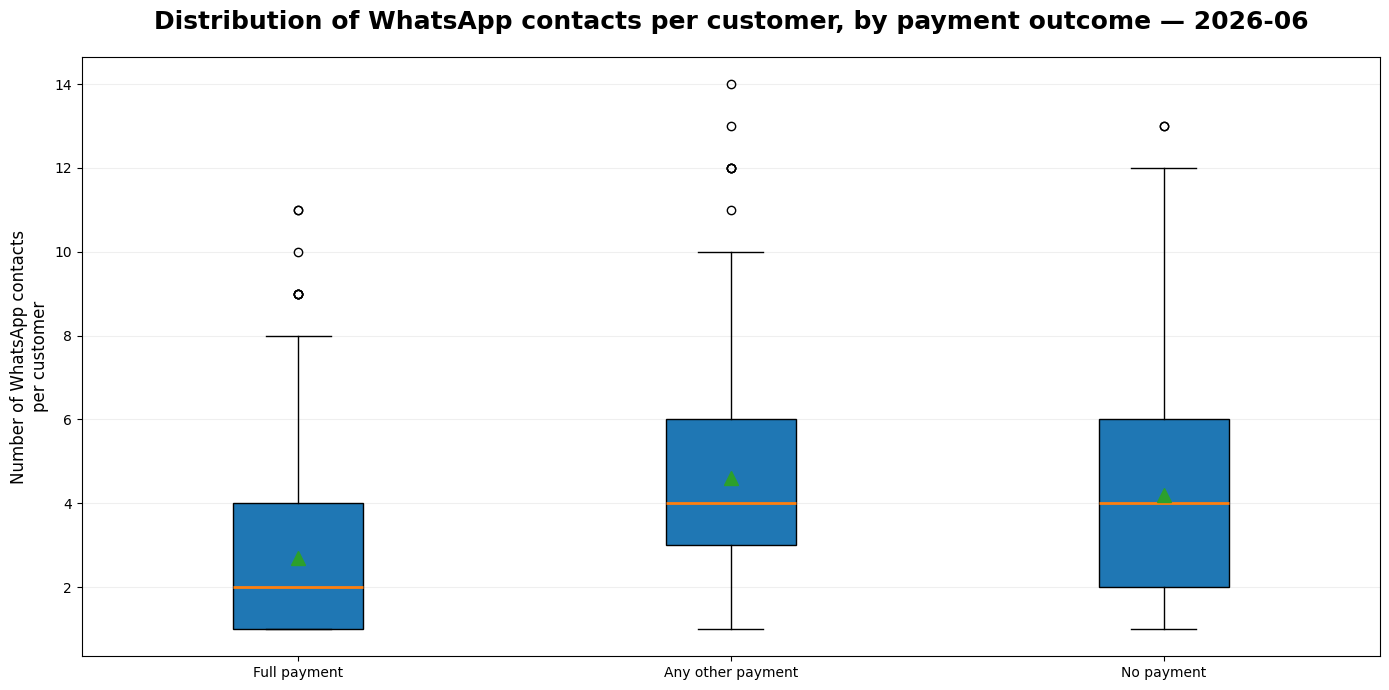

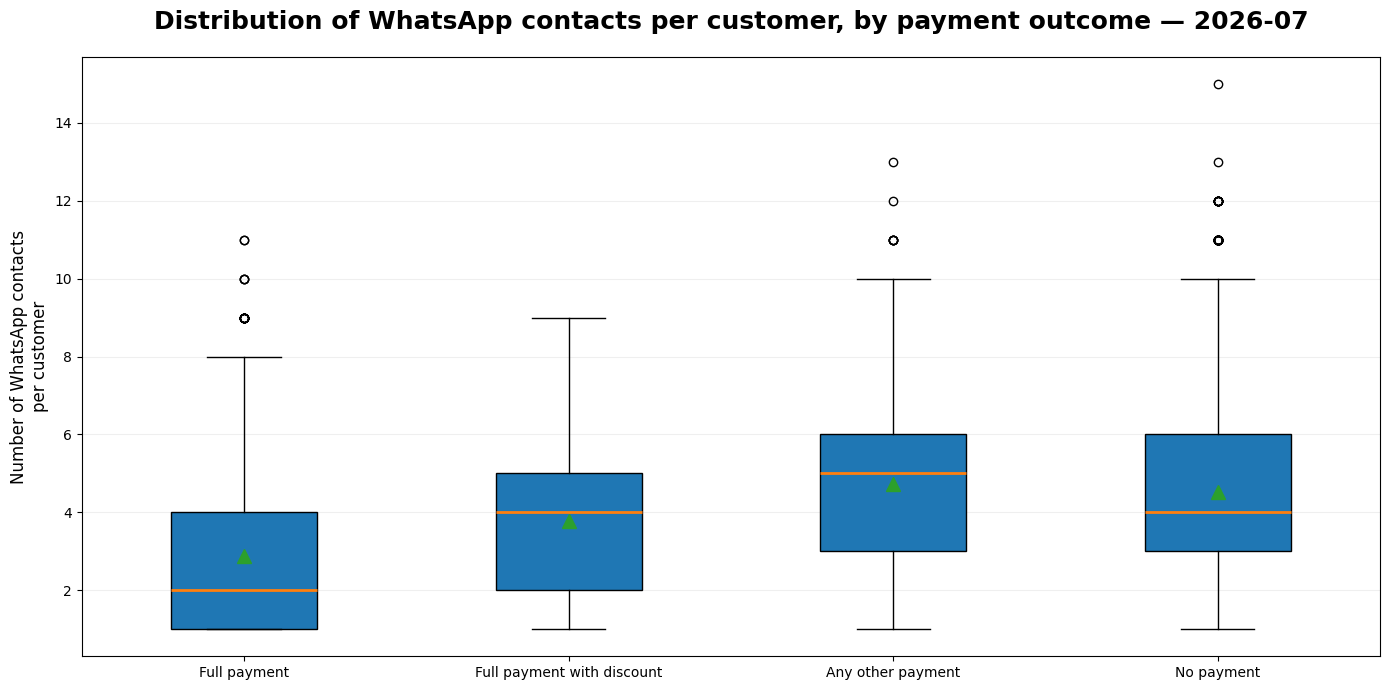

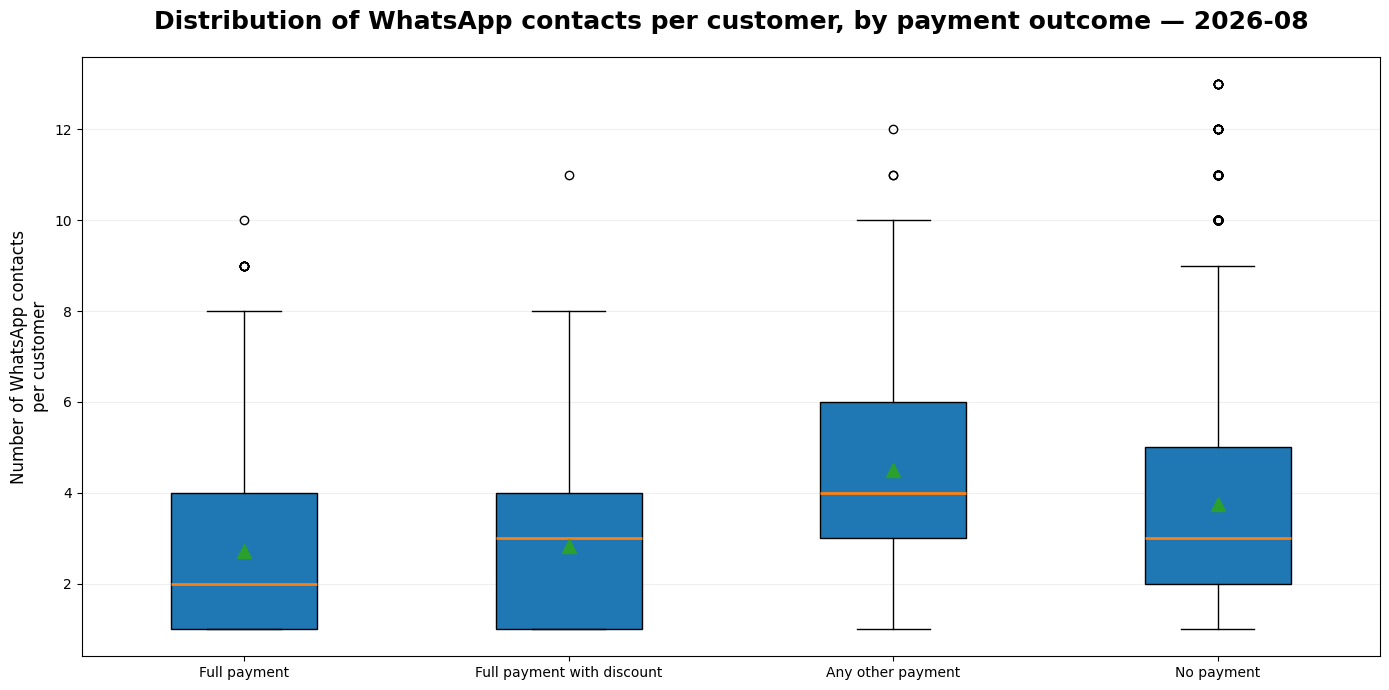

In [5]:
# ============================================================
# MONTHLY WHATSAPP CONTACT DISTRIBUTION
# BY PAYMENT OUTCOME
#
# Grain = customer × month
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Base
# ------------------------------------------------------------

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df["month"] = (
    df["sent_at"]
    .dt.to_period("M")
)

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)

df = (
    df.sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Number of WhatsApp contacts per customer × month
# ------------------------------------------------------------

monthly_contacts = (
    df.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        n_contacts=("message_id", "size")
    )
)


# ------------------------------------------------------------
# 3. First observed balance in month
# ------------------------------------------------------------

first_month = (
    df.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .head(1)[
        [
            "customer_id",
            "month",
            "outstanding_balance_brl"
        ]
    ]
    .rename(
        columns={
            "outstanding_balance_brl":
                "initial_observed_balance_brl"
        }
    )
)


# ------------------------------------------------------------
# 4. Discount offer flag
# ------------------------------------------------------------

df["discount_offer_flag"] = (
    df["template"]
    .astype(str)
    .str.contains(
        "discount_offer",
        case=False,
        na=False
    )
)

monthly_discount = (
    df.groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        received_discount_offer=(
            "discount_offer_flag",
            "max"
        )
    )
)


# ------------------------------------------------------------
# 5. Deduplicate attributed payments
#    Same 72h heuristic used previously
# ------------------------------------------------------------

payments = (
    df.loc[
        df["amount_paid_brl"] > 0
    ]
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

payments["previous_payment_at"] = (
    payments
    .groupby(
        ["customer_id", "amount_paid_brl"]
    )["sent_at"]
    .shift()
)

payments["hours_since_same_payment"] = (
    (
        payments["sent_at"]
        - payments["previous_payment_at"]
    )
    .dt.total_seconds()
    / 3600
)

payments["distinct_payment"] = (
    payments["previous_payment_at"].isna()
    |
    (
        payments["hours_since_same_payment"] > 72
    )
)

distinct_payments = (
    payments.loc[
        payments["distinct_payment"]
    ]
    .copy()
)


# ------------------------------------------------------------
# 6. Monthly payment
# ------------------------------------------------------------

monthly_payment = (
    distinct_payments
    .groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        total_payment_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)


# ------------------------------------------------------------
# 7. Customer × month analytical base
# ------------------------------------------------------------

monthly = (
    monthly_contacts
    .merge(
        first_month,
        on=["customer_id", "month"],
        how="left"
    )
    .merge(
        monthly_payment,
        on=["customer_id", "month"],
        how="left"
    )
    .merge(
        monthly_discount,
        on=["customer_id", "month"],
        how="left"
    )
)

monthly["total_payment_brl"] = (
    monthly["total_payment_brl"]
    .fillna(0)
)

monthly["received_discount_offer"] = (
    monthly["received_discount_offer"]
    .fillna(False)
)


# ------------------------------------------------------------
# 8. Payment outcome
# ------------------------------------------------------------

monthly["settlement_threshold_brl"] = np.where(
    monthly["received_discount_offer"],
    monthly["initial_observed_balance_brl"] * 0.85,
    monthly["initial_observed_balance_brl"]
)

monthly["payment_outcome"] = np.select(
    [
        monthly["total_payment_brl"] <= 0,

        (
            monthly["received_discount_offer"]
            &
            (
                monthly["total_payment_brl"]
                >= monthly["initial_observed_balance_brl"] * 0.85 - 0.05
            )
        ),

        (
            ~monthly["received_discount_offer"]
            &
            (
                monthly["total_payment_brl"]
                >= monthly["initial_observed_balance_brl"] - 0.05
            )
        )
    ],

    [
        "No payment",
        "Full payment with discount",
        "Full payment"
    ],

    default="Any other payment"
)


# ------------------------------------------------------------
# 9. Ordering
# ------------------------------------------------------------

outcome_order = [
    "Full payment",
    "Full payment with discount",
    "Any other payment",
    "No payment"
]

months = sorted(
    monthly["month"]
    .dropna()
    .unique()
)


# ------------------------------------------------------------
# 10. One boxplot per month
# ------------------------------------------------------------

for month in months:

    plot_data = (
        monthly.loc[
            monthly["month"] == month
        ]
        .copy()
    )

    groups = []

    labels = []

    for outcome in outcome_order:

        values = (
            plot_data.loc[
                plot_data["payment_outcome"] == outcome,
                "n_contacts"
            ]
            .dropna()
        )

        if len(values) > 0:
            groups.append(values)
            labels.append(outcome)


    fig, ax = plt.subplots(
        figsize=(14, 7)
    )

    bp = ax.boxplot(
        groups,
        tick_labels=labels,
        showmeans=True,
        patch_artist=True,
        meanprops=dict(
            marker="^",
            markersize=10
        ),
        medianprops=dict(
            linewidth=2
        )
    )

    ax.set_title(
        f"Distribution of WhatsApp contacts per customer, "
        f"by payment outcome — {month}",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    ax.set_ylabel(
        "Number of WhatsApp contacts\nper customer",
        fontsize=12
    )

    ax.set_xlabel("")

    ax.grid(
        axis="y",
        alpha=0.20
    )

    plt.tight_layout()
    plt.show()

In [6]:
# ============================================================
# DISCOUNT OFFER STRATEGY DIAGNOSTIC
#
# Questions:
# 1. How many discount offers are sent per month?
# 2. How many offers does the same customer receive?
# 3. Who receives discount offers?
# 4. Among customers reaching DPD 31+, who receives vs does not?
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["days_past_due"] = pd.to_numeric(df["days_past_due"], errors="coerce")
df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"], errors="coerce"
)

df["month"] = df["sent_at"].dt.to_period("M")

df["discount_offer_flag"] = (
    df["template"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("discount_offer")
)

discount = df.loc[df["discount_offer_flag"]].copy()


# ============================================================
# 1. DISCOUNT OFFER VOLUME BY MONTH
# ============================================================

monthly_discount = (
    df.groupby("month", as_index=False)
      .agg(
          total_messages=("message_id", "size"),
          total_customers=("customer_id", "nunique"),
          discount_messages=("discount_offer_flag", "sum"),
          customers_receiving_discount=(
              "customer_id",
              lambda x: x[
                  df.loc[x.index, "discount_offer_flag"]
              ].nunique()
          )
      )
)

monthly_discount["discount_share_of_messages"] = (
    monthly_discount["discount_messages"]
    / monthly_discount["total_messages"]
)

monthly_discount["pct_customers_receiving_discount"] = (
    monthly_discount["customers_receiving_discount"]
    / monthly_discount["total_customers"]
)

monthly_discount["offers_per_discount_customer"] = (
    monthly_discount["discount_messages"]
    / monthly_discount["customers_receiving_discount"]
)

print("=" * 100)
print("1. DISCOUNT OFFER VOLUME BY MONTH")
print("=" * 100)

display(monthly_discount)


# ============================================================
# 2. HOW MANY DISCOUNT OFFERS PER CUSTOMER?
#    Entire observed journey
# ============================================================

discount_per_customer = (
    discount.groupby("customer_id", as_index=False)
            .agg(
                n_discount_offers=("message_id", "size"),
                first_discount_at=("sent_at", "min"),
                last_discount_at=("sent_at", "max"),
                first_discount_dpd=("days_past_due", "first"),
                max_discount_dpd=("days_past_due", "max")
            )
)

discount_distribution = (
    discount_per_customer["n_discount_offers"]
    .value_counts()
    .sort_index()
    .rename_axis("n_discount_offers")
    .reset_index(name="customers")
)

discount_distribution["pct_customers"] = (
    discount_distribution["customers"]
    / discount_distribution["customers"].sum()
)

discount_distribution["cumulative_pct"] = (
    discount_distribution["pct_customers"].cumsum()
)

print("\n" + "=" * 100)
print("2. NUMBER OF DISCOUNT OFFERS PER CUSTOMER")
print("=" * 100)

display(discount_distribution)

print("\nSUMMARY")
print(
    discount_per_customer["n_discount_offers"]
    .describe(
        percentiles=[.25, .50, .75, .90, .95, .99]
    )
)


# ============================================================
# 3. MONTHLY REPETITION
#    How many offers can same customer receive in SAME month?
# ============================================================

discount_customer_month = (
    discount.groupby(["month", "customer_id"], as_index=False)
            .agg(
                n_discount_offers=("message_id", "size")
            )
)

monthly_repetition = (
    discount_customer_month
    .groupby("month", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        avg_offers=("n_discount_offers", "mean"),
        median_offers=("n_discount_offers", "median"),
        p75_offers=("n_discount_offers", lambda x: x.quantile(.75)),
        p90_offers=("n_discount_offers", lambda x: x.quantile(.90)),
        max_offers=("n_discount_offers", "max"),
        customers_multiple_offers=(
            "n_discount_offers",
            lambda x: (x > 1).sum()
        )
    )
)

monthly_repetition["pct_multiple_offers"] = (
    monthly_repetition["customers_multiple_offers"]
    / monthly_repetition["customers"]
)

print("\n" + "=" * 100)
print("3. REPEATED DISCOUNT OFFERS WITHIN MONTH")
print("=" * 100)

display(monthly_repetition)


# ============================================================
# 4. PROFILE AT FIRST DISCOUNT OFFER
#
# Important:
# Compare customer state AT the moment the offer was first sent
# ============================================================

first_discount = (
    discount
    .sort_values(["customer_id", "sent_at", "message_id"])
    .groupby("customer_id", as_index=False)
    .head(1)
    .copy()
)

def dpd_bucket(x):
    if pd.isna(x):
        return "Unknown"
    if x <= 15:
        return "1-15"
    if x <= 30:
        return "16-30"
    if x <= 60:
        return "31-60"
    return "60+"

first_discount["dpd_bucket_at_offer"] = (
    first_discount["days_past_due"].apply(dpd_bucket)
)

first_discount["balance_bucket_at_offer"] = pd.cut(
    first_discount["outstanding_balance_brl"],
    bins=[-np.inf, 250, 500, 1000, 2000, np.inf],
    labels=["<=250", "251-500", "501-1k", "1k-2k", "2k+"]
)

print("\n" + "=" * 100)
print("4A. DPD AT FIRST DISCOUNT OFFER")
print("=" * 100)

display(
    first_discount["dpd_bucket_at_offer"]
    .value_counts(dropna=False)
    .to_frame("customers")
    .assign(
        pct=lambda x: x["customers"] / x["customers"].sum()
    )
)

print("\n" + "=" * 100)
print("4B. BALANCE AT FIRST DISCOUNT OFFER")
print("=" * 100)

display(
    first_discount["balance_bucket_at_offer"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("customers")
    .assign(
        pct=lambda x: x["customers"] / x["customers"].sum()
    )
)


# ============================================================
# 5. WHO EVER REACHED DPD 31+?
#
# This creates the relevant comparison population.
# ============================================================

customer_profile = (
    df.groupby("customer_id", as_index=False)
      .agg(
          max_dpd=("days_past_due", "max"),
          first_balance=("outstanding_balance_brl", "first"),
          max_balance=("outstanding_balance_brl", "max"),
          n_messages=("message_id", "size"),
          ever_discount=("discount_offer_flag", "max")
      )
)

# Add static customer variables if available
static_vars = [
    "monthly_salary_brl",
    "payday_day_of_month",
    "n_prior_transactions",
    "account_age_months",
    "state_uf"
]

available_static = [
    x for x in static_vars
    if x in df.columns
]

if available_static:

    static_profile = (
        df.sort_values(["customer_id", "sent_at", "message_id"])
          .groupby("customer_id", as_index=False)
          .first()[
              ["customer_id"] + available_static
          ]
    )

    customer_profile = customer_profile.merge(
        static_profile,
        on="customer_id",
        how="left"
    )


eligible_31 = (
    customer_profile.loc[
        customer_profile["max_dpd"] >= 31
    ]
    .copy()
)

eligible_31["discount_group"] = np.where(
    eligible_31["ever_discount"],
    "Received discount",
    "No discount"
)

print("\n" + "=" * 100)
print("5. CUSTOMERS WHO REACHED DPD 31+")
print("=" * 100)

eligibility_summary = (
    eligible_31
    .groupby("discount_group", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        avg_max_dpd=("max_dpd", "mean"),
        median_max_dpd=("max_dpd", "median"),
        avg_balance=("first_balance", "mean"),
        median_balance=("first_balance", "median"),
        avg_messages=("n_messages", "mean"),
        median_messages=("n_messages", "median")
    )
)

eligibility_summary["pct_customers"] = (
    eligibility_summary["customers"]
    / eligibility_summary["customers"].sum()
)

display(eligibility_summary)


# ============================================================
# 6. STATIC PROFILE:
#    DPD 31+ RECEIVED vs DID NOT RECEIVE DISCOUNT
# ============================================================

def compare_numeric(variable):

    return (
        eligible_31
        .groupby("discount_group")[variable]
        .agg(
            ["count", "mean", "median", "std", "min", "max"]
        )
    )


for variable in [
    "first_balance",
    "max_dpd",
    "n_messages",
    "monthly_salary_brl",
    "n_prior_transactions",
    "account_age_months"
]:

    if variable in eligible_31.columns:

        print("\n" + "-" * 100)
        print(variable.upper())
        print("-" * 100)

        display(compare_numeric(variable))


# ============================================================
# 7. CATEGORICAL PROFILE
# ============================================================

for variable in [
    "state_uf",
    "payday_day_of_month"
]:

    if variable in eligible_31.columns:

        print("\n" + "-" * 100)
        print(variable.upper())
        print("-" * 100)

        tab = pd.crosstab(
            eligible_31[variable],
            eligible_31["discount_group"],
            normalize="columns"
        )

        display(
            tab.style.format("{:.1%}")
        )

1. DISCOUNT OFFER VOLUME BY MONTH


,month,total_messages,total_customers,discount_messages,customers_receiving_discount,discount_share_of_messages,pct_customers_receiving_discount,offers_per_discount_customer
0,2026-06,14465,3681,0,0,0.00,0.00,NaN
1,2026-07,29716,7030,2226,1496,0.07,0.21,1.49
2,2026-08,31225,8595,3992,2678,0.13,0.31,1.49



2. NUMBER OF DISCOUNT OFFERS PER CUSTOMER


,n_discount_offers,customers,pct_customers,cumulative_pct
0,1,1991,0.54,0.54
1,2,1066,0.29,0.83
2,3,451,0.12,0.95
3,4,129,0.04,0.99
4,5,34,0.01,1.00
5,6,7,0.00,1.00
6,7,2,0.00,1.00



SUMMARY
count   3,680.00
mean        1.69
std         0.91
min         1.00
25%         1.00
50%         1.00
75%         2.00
90%         3.00
95%         3.00
99%         5.00
max         7.00
Name: n_discount_offers, dtype: float64

3. REPEATED DISCOUNT OFFERS WITHIN MONTH


...

,count,mean,median,std,min,max
discount_group,,,,,,
No discount,1204,8.99,7.00,6.92,1,39
Received discount,3680,9.05,7.00,7.13,1,40



----------------------------------------------------------------------------------------------------
STATE_UF
----------------------------------------------------------------------------------------------------


discount_group,No discount,Received discount
state_uf,,
AC,0.4%,0.6%
AL,1.7%,1.5%
AM,1.5%,2.0%
AP,0.7%,0.4%
BA,6.3%,7.7%
CE,4.7%,4.6%
DF,1.5%,1.5%
ES,1.2%,1.7%
GO,3.4%,4.1%



----------------------------------------------------------------------------------------------------
PAYDAY_DAY_OF_MONTH
----------------------------------------------------------------------------------------------------


discount_group,No discount,Received discount
payday_day_of_month,,
1,6.8%,8.6%
5,38.7%,34.8%
10,11.0%,12.5%
15,7.6%,9.9%
20,16.2%,14.8%
25,9.6%,9.2%
30,10.1%,10.2%


In [81]:
# ============================================================
# R2 — INVALID NUMBER ON FIRST ATTEMPT
# Stop immediately after first failed_invalid_number
# ============================================================

r2 = wa.copy()

r2["sent_at"] = pd.to_datetime(r2["sent_at"])

r2 = (
    r2
    .sort_values(["customer_id", "sent_at"])
    .reset_index(drop=True)
)

r2["interaction_number"] = (
    r2.groupby("customer_id").cumcount() + 1
)

# ------------------------------------------------------------
# 1. First interaction
# ------------------------------------------------------------

first_contact = (
    r2.loc[
        r2["interaction_number"] == 1,
        [
            "customer_id",
            "sent_at",
            "delivery_status"
        ]
    ]
    .copy()
)

first_contact["r2_eligible"] = (
    first_contact["delivery_status"]
    .astype(str)
    .str.lower()
    .eq("failed_invalid_number")
)

r2_trigger = (
    first_contact.loc[
        first_contact["r2_eligible"],
        ["customer_id", "sent_at"]
    ]
    .rename(columns={"sent_at": "r2_trigger_at"})
)

# ------------------------------------------------------------
# 2. Bring trigger back to full history
# ------------------------------------------------------------

r2 = r2.merge(
    r2_trigger,
    on="customer_id",
    how="left"
)

r2["r2_eligible"] = r2["r2_trigger_at"].notna()

# ------------------------------------------------------------
# 3. Every message AFTER first invalid-number failure
# would have been avoided
# ------------------------------------------------------------

r2["message_after_r2_trigger"] = (
    r2["r2_eligible"]
    & (r2["sent_at"] > r2["r2_trigger_at"])
)

# ------------------------------------------------------------
# 4. What happened to those subsequent attempts?
# ------------------------------------------------------------

r2_after = r2.loc[
    r2["message_after_r2_trigger"]
].copy()

r2_delivery_validation = (
    r2_after
    .groupby("delivery_status", dropna=False)
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        payments=("amount_paid_brl", lambda x: (x.fillna(0) > 0).sum()),
        recovered_brl=("amount_paid_brl", lambda x: x.fillna(0).sum())
    )
    .reset_index()
)

r2_delivery_validation["pct_messages"] = (
    r2_delivery_validation["messages"]
    / r2_delivery_validation["messages"].sum()
    * 100
)

display(
    r2_delivery_validation.style.format({
        "pct_messages": "{:.2f}%",
        "recovered_brl": "R$ {:,.2f}"
    })
)

,delivery_status,messages,customers,payments,recovered_brl,pct_messages
0,failed_invalid_number,4115,587,0,R$ 0.00,100.00%


In [82]:
# ============================================================
# R2 — BUSINESS IMPACT
# ============================================================

r2_customers = (
    r2.loc[r2["r2_eligible"]]
      .groupby("customer_id", as_index=False)
      .agg(
          total_messages=("interaction_number", "max"),
          messages_after_trigger=("message_after_r2_trigger", "sum"),
          payments_after_trigger=(
              "amount_paid_brl",
              lambda x: (x.fillna(0) > 0).sum()
          ),
          recovered_after_trigger_brl=(
              "amount_paid_brl",
              lambda x: x.fillna(0).sum()
          )
      )
)

r2_summary = pd.DataFrame({
    "metric": [
        "Customers with invalid number on first attempt",
        "Messages sent after known invalid number",
        "Customers recontacted",
        "Payments observed after invalid number",
        "Recovered BRL after invalid number"
    ],
    "value": [
        r2_customers["customer_id"].nunique(),
        r2_customers["messages_after_trigger"].sum(),
        (r2_customers["messages_after_trigger"] > 0).sum(),
        r2_after["amount_paid_brl"].fillna(0).gt(0).sum(),
        r2_after["amount_paid_brl"].fillna(0).sum()
    ]
})

display(r2_summary)

,metric,value
0,Customers with invalid number on first attempt,608.00
1,Messages sent after known invalid number,"4,115.00"
2,Customers recontacted,587.00
3,Payments observed after invalid number,0.00
4,Recovered BRL after invalid number,0.00


,interaction_number,attempts,customers,successful_deliveries,payments,recovered_brl,delivery_success_rate,payment_rate
0,1,608,608,0,0,R$ 0.00,0.00%,0.00%
1,2,587,587,0,0,R$ 0.00,0.00%,0.00%
2,3,556,556,0,0,R$ 0.00,0.00%,0.00%
3,4,525,525,0,0,R$ 0.00,0.00%,0.00%
4,5,503,503,0,0,R$ 0.00,0.00%,0.00%
5,6,439,439,0,0,R$ 0.00,0.00%,0.00%
6,7,396,396,0,0,R$ 0.00,0.00%,0.00%
7,8,332,332,0,0,R$ 0.00,0.00%,0.00%
8,9,258,258,0,0,R$ 0.00,0.00%,0.00%
9,10,189,189,0,0,R$ 0.00,0.00%,0.00%


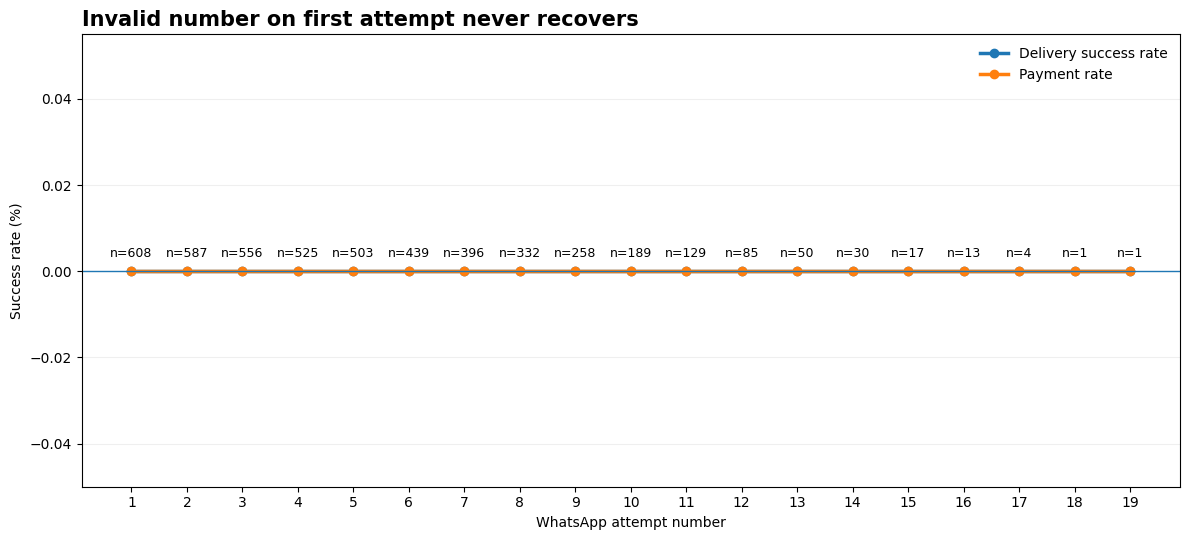

In [83]:
# ============================================================
# R2 — INVALID NUMBER ON FIRST ATTEMPT
# Does it EVER recover afterwards?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = wa.copy()
df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df.sort_values(["customer_id", "sent_at"])
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# 1. Interaction number within customer journey
# ------------------------------------------------------------

df["interaction_number"] = (
    df.groupby("customer_id").cumcount() + 1
)

# ------------------------------------------------------------
# 2. Customers whose FIRST interaction = invalid number
# ------------------------------------------------------------

first_interaction = (
    df[df["interaction_number"] == 1]
    [["customer_id", "delivery_status"]]
    .copy()
)

invalid_first_ids = first_interaction.loc[
    first_interaction["delivery_status"]
        .astype(str)
        .str.lower()
        .eq("failed_invalid_number"),
    "customer_id"
]

invalid_journey = df[
    df["customer_id"].isin(invalid_first_ids)
].copy()

# ------------------------------------------------------------
# 3. Define successful delivery / payment
# ------------------------------------------------------------

invalid_journey["delivery_success"] = ~(
    invalid_journey["delivery_status"]
        .astype(str)
        .str.lower()
        .str.startswith("failed")
)

invalid_journey["payment"] = (
    invalid_journey["amount_paid_brl"].fillna(0) > 0
)

# ------------------------------------------------------------
# 4. Performance by attempt number
# ------------------------------------------------------------

attempt_analysis = (
    invalid_journey
    .groupby("interaction_number")
    .agg(
        attempts=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        successful_deliveries=("delivery_success", "sum"),
        payments=("payment", "sum"),
        recovered_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
)

attempt_analysis["delivery_success_rate"] = (
    attempt_analysis["successful_deliveries"]
    / attempt_analysis["attempts"]
    * 100
)

attempt_analysis["payment_rate"] = (
    attempt_analysis["payments"]
    / attempt_analysis["attempts"]
    * 100
)

display(
    attempt_analysis.style.format({
        "delivery_success_rate": "{:.2f}%",
        "payment_rate": "{:.2f}%",
        "recovered_brl": "R$ {:,.2f}"
    })
)

# ------------------------------------------------------------
# 5. GRAPH
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5.5))

x = attempt_analysis["interaction_number"]

ax.plot(
    x,
    attempt_analysis["delivery_success_rate"],
    marker="o",
    linewidth=2.5,
    label="Delivery success rate"
)

ax.plot(
    x,
    attempt_analysis["payment_rate"],
    marker="o",
    linewidth=2.5,
    label="Payment rate"
)

ax.axhline(0, linewidth=1)

ax.set_title(
    "Invalid number on first attempt never recovers",
    fontsize=15,
    fontweight="bold",
    loc="left"
)

ax.set_xlabel("WhatsApp attempt number")
ax.set_ylabel("Success rate (%)")

ax.set_xticks(x)
ax.set_ylim(bottom=-0.05)

ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)

# Add number of attempts below each point
for _, row in attempt_analysis.iterrows():
    ax.annotate(
        f'n={int(row["attempts"]):,}',
        (
            row["interaction_number"],
            max(
                row["delivery_success_rate"],
                row["payment_rate"]
            )
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Investigação dos clientes com contato : sem pagamento x algum pagamento

In [50]:
# ============================================================
# PAYMENT PROFILE — WHATSAPP CUSTOMERS
# Customer grain
#
# Groups:
#   1. No payment  -> total payment = 0
#   2. Any payment -> total payment > 0
# ============================================================

import pandas as pd
import numpy as np

wa_payment = wa.copy()

# ------------------------------------------------------------
# 1. Guarantee numeric payment
# ------------------------------------------------------------

wa_payment["amount_paid_brl"] = pd.to_numeric(
    wa_payment["amount_paid_brl"],
    errors="coerce"
).fillna(0)


# ------------------------------------------------------------
# 2. Aggregate to CUSTOMER grain
# ------------------------------------------------------------

customer_payment = (
    wa_payment
    .groupby("customer_id", as_index=False)
    .agg(
        total_payment_brl=("amount_paid_brl", "sum")
    )
)


# ------------------------------------------------------------
# 3. Payment group
# ------------------------------------------------------------

customer_payment["payment_group"] = np.where(
    customer_payment["total_payment_brl"] > 0,
    "Any payment",
    "No payment"
)


# ------------------------------------------------------------
# 4. Summary
# ------------------------------------------------------------

payment_summary = (
    customer_payment
    .groupby("payment_group", as_index=False)
    .agg(
        customers=("customer_id", "nunique")
    )
)

total_customers = customer_payment["customer_id"].nunique()

payment_summary["pct_customers"] = (
    payment_summary["customers"] / total_customers * 100
)

payment_summary["pct_customers"] = (
    payment_summary["pct_customers"]
    .map(lambda x: f"{x:.1f}%")
)


# ------------------------------------------------------------
# 5. Display
# ------------------------------------------------------------

print("=" * 70)
print("WHATSAPP CUSTOMER PAYMENT PROFILE")
print("=" * 70)

print(f"\nTotal unique customers: {total_customers:,}")

display(payment_summary)

WHATSAPP CUSTOMER PAYMENT PROFILE

Total unique customers: 11,724


,payment_group,customers,pct_customers
0,Any payment,4893,41.7%
1,No payment,6831,58.3%


In [51]:
# ============================================================
# PAYMENT PROFILE — CUSTOMERS + MONEY
# Customer grain
#
# Groups:
#   1. No payment
#   2. Full payment
#   3. Full payment with discount
#   4. Any other payment
#
# Money:
#   - First observed outstanding balance per customer
#   - Validated payment without duplicate attribution
# ============================================================

import pandas as pd
import numpy as np

TOLERANCE_BRL = 0.05
DISCOUNT_SETTLEMENT_RATE = 0.85

wa_payment = wa.copy()

wa_payment["sent_at"] = pd.to_datetime(wa_payment["sent_at"])

wa_payment["amount_paid_brl"] = pd.to_numeric(
    wa_payment["amount_paid_brl"],
    errors="coerce"
).fillna(0)

wa_payment["outstanding_balance_brl"] = pd.to_numeric(
    wa_payment["outstanding_balance_brl"],
    errors="coerce"
)

wa_payment = wa_payment.sort_values(
    ["customer_id", "sent_at"]
).copy()


# ============================================================
# 1. FIRST OBSERVED BALANCE PER CUSTOMER
# ============================================================

first_balance = (
    wa_payment
    .groupby("customer_id", as_index=False)
    .first()[[
        "customer_id",
        "outstanding_balance_brl"
    ]]
    .rename(
        columns={
            "outstanding_balance_brl":
            "first_observed_balance_brl"
        }
    )
)


# ============================================================
# 2. VALIDATE PAYMENT EVENTS
#
# amount_paid_brl can appear in overlapping 72h attribution
# windows.
#
# Therefore, within customer:
# identical positive payment observations are counted only
# once when they refer to the same attributed payment event.
#
# We retain the FIRST observation of the payment.
# ============================================================

positive_payments = (
    wa_payment.loc[
        wa_payment["amount_paid_brl"] > 0,
        [
            "customer_id",
            "sent_at",
            "amount_paid_brl",
            "outstanding_balance_brl",
            "template"
        ]
    ]
    .sort_values(["customer_id", "sent_at"])
    .copy()
)


# ------------------------------------------------------------
# Remove repeated attribution caused by overlapping windows
#
# Same customer + same payment amount observed repeatedly
# in consecutive sends -> keep first attribution only.
# ------------------------------------------------------------

positive_payments["previous_payment"] = (
    positive_payments
    .groupby("customer_id")["amount_paid_brl"]
    .shift()
)

positive_payments["duplicate_attribution"] = (
    positive_payments["amount_paid_brl"]
    .eq(positive_payments["previous_payment"])
)

validated_payments = (
    positive_payments.loc[
        ~positive_payments["duplicate_attribution"]
    ]
    .copy()
)


# ============================================================
# 3. PAYMENT EVENT TYPE
# ============================================================

validated_payments["discount_offer_flag"] = (
    validated_payments["template"]
    .astype(str)
    .str.contains(
        "discount_offer",
        case=False,
        na=False
    )
)


# Full payment = 100% of balance
validated_payments["full_payment_event"] = (
    validated_payments["amount_paid_brl"]
    >=
    validated_payments["outstanding_balance_brl"]
    - TOLERANCE_BRL
)


# Discount settlement = 85% of balance
validated_payments["full_payment_discount_event"] = (
    validated_payments["discount_offer_flag"]
    &
    (
        validated_payments["amount_paid_brl"]
        >=
        (
            validated_payments["outstanding_balance_brl"]
            * DISCOUNT_SETTLEMENT_RATE
        )
        - TOLERANCE_BRL
    )
    &
    ~validated_payments["full_payment_event"]
)


# ============================================================
# 4. AGGREGATE VALIDATED PAYMENTS TO CUSTOMER GRAIN
# ============================================================

customer_recovery = (
    validated_payments
    .groupby("customer_id", as_index=False)
    .agg(
        validated_paid_brl=(
            "amount_paid_brl",
            "sum"
        ),
        n_validated_payments=(
            "amount_paid_brl",
            "size"
        ),
        ever_full_payment=(
            "full_payment_event",
            "max"
        ),
        ever_full_payment_discount=(
            "full_payment_discount_event",
            "max"
        )
    )
)


# ============================================================
# 5. CANONICAL CUSTOMER PAYMENT BASE
# ============================================================

customer_payment = (
    first_balance
    .merge(
        customer_recovery,
        on="customer_id",
        how="left"
    )
)


# Customers with no payment
customer_payment["validated_paid_brl"] = (
    customer_payment["validated_paid_brl"]
    .fillna(0)
)

customer_payment["n_validated_payments"] = (
    customer_payment["n_validated_payments"]
    .fillna(0)
    .astype(int)
)

customer_payment["ever_full_payment"] = (
    customer_payment["ever_full_payment"]
    .fillna(False)
    .astype(bool)
)

customer_payment["ever_full_payment_discount"] = (
    customer_payment["ever_full_payment_discount"]
    .fillna(False)
    .astype(bool)
)


# ============================================================
# 6. MUTUALLY EXCLUSIVE PAYMENT GROUP
# ============================================================

customer_payment["payment_group"] = np.select(
    [
        customer_payment["validated_paid_brl"].eq(0),

        customer_payment["ever_full_payment"],

        customer_payment[
            "ever_full_payment_discount"
        ]
    ],
    [
        "No payment",
        "Full payment",
        "Full payment with discount"
    ],
    default="Any other payment"
)


# ============================================================
# 7. CUSTOMER-LEVEL MONEY METRICS
# ============================================================

customer_payment["unrecovered_brl"] = (
    customer_payment["first_observed_balance_brl"]
    -
    customer_payment["validated_paid_brl"]
).clip(lower=0)


# ============================================================
# 8. FINAL SUMMARY
# ============================================================

payment_summary = (
    customer_payment
    .groupby(
        "payment_group",
        as_index=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        first_observed_balance_brl=(
            "first_observed_balance_brl",
            "sum"
        ),

        validated_paid_brl=(
            "validated_paid_brl",
            "sum"
        ),

        unrecovered_brl=(
            "unrecovered_brl",
            "sum"
        )
    )
)


# ============================================================
# 9. KPIs
# ============================================================

total_customers = (
    customer_payment["customer_id"]
    .nunique()
)

payment_summary["pct_customers"] = (
    payment_summary["customers"]
    / total_customers
    * 100
)

payment_summary["recovery_rate_pct"] = (
    payment_summary["validated_paid_brl"]
    /
    payment_summary["first_observed_balance_brl"]
    * 100
)


# ============================================================
# 10. ORDER
# ============================================================

group_order = [
    "No payment",
    "Full payment",
    "Full payment with discount",
    "Any other payment"
]

payment_summary["payment_group"] = pd.Categorical(
    payment_summary["payment_group"],
    categories=group_order,
    ordered=True
)

payment_summary = (
    payment_summary
    .sort_values("payment_group")
    .reset_index(drop=True)
)


# ============================================================
# 11. BUSINESS-FRIENDLY FORMATTING
# ============================================================

payment_summary_display = payment_summary.copy()

payment_summary_display["pct_customers"] = (
    payment_summary_display["pct_customers"]
    .map(lambda x: f"{x:.1f}%")
)

payment_summary_display["recovery_rate_pct"] = (
    payment_summary_display["recovery_rate_pct"]
    .map(lambda x: f"{x:.1f}%")
)

for col in [
    "first_observed_balance_brl",
    "validated_paid_brl",
    "unrecovered_brl"
]:
    payment_summary_display[col] = (
        payment_summary_display[col]
        .map(
            lambda x:
            f"R$ {x:,.2f}"
        )
    )


# ============================================================
# 12. DISPLAY
# ============================================================

print("=" * 100)
print("WHATSAPP CUSTOMER PAYMENT PROFILE — CUSTOMERS + MONEY")
print("=" * 100)

print(
    f"\nTotal unique customers: "
    f"{total_customers:,}"
)

display(payment_summary_display)

WHATSAPP CUSTOMER PAYMENT PROFILE — CUSTOMERS + MONEY

Total unique customers: 11,724


,payment_group,customers,first_observed_balance_brl,validated_paid_brl,unrecovered_brl,pct_customers,recovery_rate_pct
0,No payment,6831,"R$ 5,984,825.45",R$ 0.00,"R$ 5,984,825.45",58.3%,0.0%
1,Full payment,3275,"R$ 2,652,705.56","R$ 2,652,705.56",R$ 0.05,27.9%,100.0%
2,Full payment with discount,366,"R$ 293,186.54","R$ 255,752.88","R$ 37,433.66",3.1%,87.2%
3,Any other payment,1252,"R$ 1,034,822.78","R$ 550,846.86","R$ 483,975.92",10.7%,53.2%


In [53]:
# ============================================================
# DELIVERY STATUS — CANONICAL RULE
#
# delivered -> Delivered
# everything else -> Failed
# ============================================================

wa_delivery = wa.copy()

wa_delivery["sent_at"] = pd.to_datetime(
    wa_delivery["sent_at"]
)

wa_delivery["delivery_status_raw"] = (
    wa_delivery["delivery_status"]
)

wa_delivery["delivery_status"] = np.where(
    wa_delivery["delivery_status"]
        .astype(str)
        .str.lower()
        .str.strip()
        .eq("delivered"),
    "delivered",
    "failed"
)

wa_delivery = (
    wa_delivery
    .sort_values(
        ["customer_id", "sent_at"]
    )
    .copy()
)

In [54]:
# ============================================================
# CUSTOMER-LEVEL DELIVERY JOURNEY
# ============================================================

delivery_journey = (
    wa_delivery
    .groupby("customer_id", as_index=False)
    .agg(
        n_attempts=(
            "message_id",
            "count"
        ),

        first_delivery_status=(
            "delivery_status",
            "first"
        ),

        n_failed=(
            "delivery_status",
            lambda x: (x == "failed").sum()
        ),

        n_delivered=(
            "delivery_status",
            lambda x: (x == "delivered").sum()
        )
    )
)


# ============================================================
# ADD PAYMENT SEGMENT
# ============================================================

payment_segments = customer_payment[
    ["customer_id", "payment_group"]
].copy()

delivery_journey = (
    delivery_journey
    .merge(
        payment_segments,
        on="customer_id",
        how="left",
        validate="1:1"
    )
)


# ============================================================
# DELIVERY FLAGS
# ============================================================

# First contact failed
delivery_journey["first_attempt_failed"] = (
    delivery_journey["first_delivery_status"]
    .eq("failed")
)


# Customer NEVER received a delivered message
delivery_journey["never_delivered"] = (
    delivery_journey["n_delivered"]
    .eq(0)
)


# Every single attempt failed
delivery_journey["all_attempts_failed"] = (
    delivery_journey["n_failed"]
    .eq(delivery_journey["n_attempts"])
)


# More than one attempt
delivery_journey["repeated_attempts"] = (
    delivery_journey["n_attempts"] > 1
)


# ============================================================
# STRICT WASTE DEFINITION
#
# 1st attempt failed
# +
# every subsequent attempt failed
# +
# never delivered
# +
# we continued trying
# ============================================================

delivery_journey["wasted_contact_flag"] = (
    delivery_journey["first_attempt_failed"]
    &
    delivery_journey["all_attempts_failed"]
    &
    delivery_journey["never_delivered"]
    &
    delivery_journey["repeated_attempts"]
)


# ============================================================
# WASTED ATTEMPTS
#
# First failed attempt = necessary attempt
# Everything AFTER it = potential waste
# ============================================================

delivery_journey[
    "wasted_attempts_after_first_failure"
] = np.where(
    delivery_journey["wasted_contact_flag"],
    delivery_journey["n_attempts"] - 1,
    0
)


# ============================================================
# SUMMARY BY PAYMENT SEGMENT
# ============================================================

waste_summary = (
    delivery_journey
    .groupby(
        "payment_group",
        as_index=False,
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        total_attempts=(
            "n_attempts",
            "sum"
        ),

        first_attempt_failed=(
            "first_attempt_failed",
            "sum"
        ),

        never_delivered=(
            "never_delivered",
            "sum"
        ),

        customers_repeated_all_failed=(
            "wasted_contact_flag",
            "sum"
        ),

        wasted_attempts=(
            "wasted_attempts_after_first_failure",
            "sum"
        )
    )
)


# ============================================================
# PERCENTAGES
# ============================================================

waste_summary["pct_first_attempt_failed"] = (
    waste_summary["first_attempt_failed"]
    / waste_summary["customers"]
    * 100
)

waste_summary["pct_never_delivered"] = (
    waste_summary["never_delivered"]
    / waste_summary["customers"]
    * 100
)

waste_summary["pct_repeated_all_failed"] = (
    waste_summary["customers_repeated_all_failed"]
    / waste_summary["customers"]
    * 100
)

waste_summary["pct_attempts_wasted"] = (
    waste_summary["wasted_attempts"]
    / waste_summary["total_attempts"]
    * 100
)


# ============================================================
# ORDER
# ============================================================

group_order = [
    "Full payment",
    "Full payment with discount",
    "Any other payment",
    "No payment"
]

waste_summary["payment_group"] = pd.Categorical(
    waste_summary["payment_group"],
    categories=group_order,
    ordered=True
)

waste_summary = (
    waste_summary
    .sort_values("payment_group")
    .reset_index(drop=True)
)


# ============================================================
# DISPLAY
# ============================================================

waste_summary_display = waste_summary.copy()

pct_cols = [
    "pct_first_attempt_failed",
    "pct_never_delivered",
    "pct_repeated_all_failed",
    "pct_attempts_wasted"
]

for col in pct_cols:
    waste_summary_display[col] = (
        waste_summary_display[col]
        .map(lambda x: f"{x:.1f}%")
    )

display(waste_summary_display)

,payment_group,customers,total_attempts,first_attempt_failed,never_delivered,customers_repeated_all_failed,wasted_attempts,pct_first_attempt_failed,pct_never_delivered,pct_repeated_all_failed,pct_attempts_wasted
0,Full payment,3275,11992,85,0,0,0,2.6%,0.0%,0.0%,0.0%
1,Full payment with discount,366,3197,5,0,0,0,1.4%,0.0%,0.0%,0.0%
2,Any other payment,1252,9636,33,0,0,0,2.6%,0.0%,0.0%,0.0%
3,No payment,6831,50581,854,672,635,4444,12.5%,9.8%,9.3%,8.8%


In [55]:
# ============================================================
# DOES IT PAY TO RETRY AFTER THE FIRST FAILED DELIVERY?
#
# Population:
#   Customers whose FIRST WhatsApp attempt FAILED
#
# Question:
#   After the first failed attempt:
#   - Did ANY subsequent attempt eventually get delivered?
#   - Or did ALL subsequent attempts continue to fail?
#
# Delivery rule:
#   delivery_status == "delivered" -> delivered
#   everything else                 -> failed
#
# Breakdown:
#   - Full payment
#   - Full payment with discount
#   - Any other payment
#   - No payment
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. PREPARE WHATSAPP JOURNEY
# ============================================================

wa_retry = wa.copy()

wa_retry["sent_at"] = pd.to_datetime(
    wa_retry["sent_at"]
)

# Canonical delivery rule
wa_retry["delivery_status_canonical"] = np.where(
    wa_retry["delivery_status"]
        .astype(str)
        .str.lower()
        .str.strip()
        .eq("delivered"),
    "delivered",
    "failed"
)

wa_retry = (
    wa_retry
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)


# ============================================================
# 2. CONTACT SEQUENCE
# ============================================================

wa_retry["attempt_number"] = (
    wa_retry
    .groupby("customer_id")
    .cumcount()
    + 1
)


# ============================================================
# 3. IDENTIFY FIRST ATTEMPT STATUS
# ============================================================

first_attempt = (
    wa_retry.loc[
        wa_retry["attempt_number"] == 1,
        [
            "customer_id",
            "delivery_status_canonical"
        ]
    ]
    .rename(
        columns={
            "delivery_status_canonical":
            "first_delivery_status"
        }
    )
)


# ============================================================
# 4. KEEP ONLY CUSTOMERS WHO FAILED ON FIRST ATTEMPT
# ============================================================

first_failed_ids = set(
    first_attempt.loc[
        first_attempt["first_delivery_status"] == "failed",
        "customer_id"
    ]
)

retry_population = (
    wa_retry.loc[
        wa_retry["customer_id"].isin(first_failed_ids)
    ]
    .copy()
)


# ============================================================
# 5. SUBSEQUENT ATTEMPTS ONLY
#
# We exclude attempt #1 because we already know it failed.
# Now we measure whether RETRYING worked.
# ============================================================

subsequent_attempts = (
    retry_population.loc[
        retry_population["attempt_number"] > 1
    ]
    .copy()
)


# ============================================================
# 6. CUSTOMER-LEVEL RETRY OUTCOME
# ============================================================

retry_customer = (
    retry_population
    .groupby("customer_id", as_index=False)
    .agg(
        total_attempts=(
            "attempt_number",
            "max"
        )
    )
)


# Number of subsequent attempts
retry_customer["subsequent_attempts"] = (
    retry_customer["total_attempts"] - 1
)


# ------------------------------------------------------------
# Subsequent delivery information
# ------------------------------------------------------------

subsequent_customer = (
    subsequent_attempts
    .groupby("customer_id", as_index=False)
    .agg(
        n_subsequent_attempts=(
            "message_id",
            "count"
        ),

        n_subsequent_delivered=(
            "delivery_status_canonical",
            lambda x: (x == "delivered").sum()
        ),

        n_subsequent_failed=(
            "delivery_status_canonical",
            lambda x: (x == "failed").sum()
        )
    )
)


retry_customer = (
    retry_customer
    .merge(
        subsequent_customer,
        on="customer_id",
        how="left"
    )
)

for col in [
    "n_subsequent_attempts",
    "n_subsequent_delivered",
    "n_subsequent_failed"
]:
    retry_customer[col] = (
        retry_customer[col]
        .fillna(0)
        .astype(int)
    )


# ============================================================
# 7. RETRY OUTCOME
# ============================================================

# Did we actually retry?
retry_customer["was_retried"] = (
    retry_customer["n_subsequent_attempts"] > 0
)


# At least one later message was successfully delivered
retry_customer["eventually_delivered_after_first_fail"] = (
    retry_customer["n_subsequent_delivered"] > 0
)


# We retried, but EVERYTHING continued to fail
retry_customer["all_retries_failed"] = (
    retry_customer["was_retried"]
    &
    retry_customer["n_subsequent_delivered"].eq(0)
)


# ============================================================
# 8. ADD PAYMENT SEGMENT
# ============================================================

retry_customer = (
    retry_customer
    .merge(
        customer_payment[
            ["customer_id", "payment_group"]
        ],
        on="customer_id",
        how="left",
        validate="1:1"
    )
)


# ============================================================
# 9. ANALYSIS POPULATION:
# CUSTOMERS WHO ACTUALLY RECEIVED A RETRY
#
# This is the correct denominator for:
# "Did retrying after first failure work?"
# ============================================================

retried = (
    retry_customer.loc[
        retry_customer["was_retried"]
    ]
    .copy()
)


# ============================================================
# 10. SUMMARY BY PAYMENT SEGMENT
# ============================================================

retry_summary = (
    retried
    .groupby(
        "payment_group",
        as_index=False,
        observed=True
    )
    .agg(
        customers_retried=(
            "customer_id",
            "nunique"
        ),

        eventually_delivered=(
            "eventually_delivered_after_first_fail",
            "sum"
        ),

        all_retries_failed=(
            "all_retries_failed",
            "sum"
        ),

        subsequent_attempts=(
            "n_subsequent_attempts",
            "sum"
        ),

        subsequent_failed_attempts=(
            "n_subsequent_failed",
            "sum"
        ),

        subsequent_delivered_attempts=(
            "n_subsequent_delivered",
            "sum"
        )
    )
)


# ============================================================
# 11. CUSTOMER-LEVEL SUCCESS / FAILURE RATE
# ============================================================

retry_summary["retry_success_rate_pct"] = (
    retry_summary["eventually_delivered"]
    / retry_summary["customers_retried"]
    * 100
)

retry_summary["retry_failure_rate_pct"] = (
    retry_summary["all_retries_failed"]
    / retry_summary["customers_retried"]
    * 100
)


# ============================================================
# 12. MESSAGE-LEVEL FAILURE RATE
# ============================================================

retry_summary["subsequent_message_failure_rate_pct"] = (
    retry_summary["subsequent_failed_attempts"]
    / retry_summary["subsequent_attempts"]
    * 100
)


# ============================================================
# 13. ORDER
# ============================================================

group_order = [
    "Full payment",
    "Full payment with discount",
    "Any other payment",
    "No payment"
]

retry_summary["payment_group"] = pd.Categorical(
    retry_summary["payment_group"],
    categories=group_order,
    ordered=True
)

retry_summary = (
    retry_summary
    .sort_values("payment_group")
    .reset_index(drop=True)
)


# ============================================================
# 14. DISPLAY
# ============================================================

retry_summary_display = retry_summary.copy()

for col in [
    "retry_success_rate_pct",
    "retry_failure_rate_pct",
    "subsequent_message_failure_rate_pct"
]:
    retry_summary_display[col] = (
        retry_summary_display[col]
        .map(lambda x: f"{x:.1f}%")
    )

print("=" * 110)
print("RETRY PERFORMANCE AFTER FIRST FAILED DELIVERY")
print("=" * 110)
print("""
Population:
Customers whose FIRST contact FAILED
AND who received at least one subsequent attempt.

Success:
At least one subsequent attempt was eventually DELIVERED.

Failure:
Every subsequent attempt remained FAILED.
""")

display(retry_summary_display)

RETRY PERFORMANCE AFTER FIRST FAILED DELIVERY

Population:
Customers whose FIRST contact FAILED
AND who received at least one subsequent attempt.

Success:
At least one subsequent attempt was eventually DELIVERED.

Failure:
Every subsequent attempt remained FAILED.



,payment_group,customers_retried,eventually_delivered,all_retries_failed,subsequent_attempts,subsequent_failed_attempts,subsequent_delivered_attempts,retry_success_rate_pct,retry_failure_rate_pct,subsequent_message_failure_rate_pct
0,Full payment,85,85,0,275,9,266,100.0%,0.0%,3.3%
1,Full payment with discount,5,5,0,31,0,31,100.0%,0.0%,0.0%
2,Any other payment,33,33,0,236,8,228,100.0%,0.0%,3.4%
3,No payment,817,182,635,5704,4592,1112,22.3%,77.7%,80.5%


In [59]:
# ============================================================
# SHOULD WE RETRY AFTER TWO CONSECUTIVE FAILED ATTEMPTS?
#
# Population:
#   Attempt 1 = FAILED
#   Attempt 2 = FAILED
#
# Question:
#   What happened AFTER the second failure?
#
# Outcomes:
#   - Was a 3rd attempt made?
#   - Was the 3rd attempt delivered?
#   - Was ANY later attempt eventually delivered?
#   - What was the final payment outcome?
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. PREPARE JOURNEY
# ============================================================

journey = wa.copy()

journey["sent_at"] = pd.to_datetime(
    journey["sent_at"]
)

# Canonical delivery rule:
# delivered = delivered
# everything else = failed
journey["delivery_status_canonical"] = np.where(
    journey["delivery_status"]
        .astype(str)
        .str.lower()
        .str.strip()
        .eq("delivered"),
    "delivered",
    "failed"
)

journey = (
    journey
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

journey["attempt_number"] = (
    journey
    .groupby("customer_id")
    .cumcount()
    + 1
)


# ============================================================
# 2. GET FIRST AND SECOND ATTEMPT STATUS
# ============================================================

first_two = (
    journey.loc[
        journey["attempt_number"].isin([1, 2])
    ]
    .pivot(
        index="customer_id",
        columns="attempt_number",
        values="delivery_status_canonical"
    )
    .rename(
        columns={
            1: "attempt_1_status",
            2: "attempt_2_status"
        }
    )
    .reset_index()
)


# ============================================================
# 3. POPULATION:
# FIRST FAILED + SECOND FAILED
# ============================================================

two_failures = (
    first_two.loc[
        (first_two["attempt_1_status"] == "failed")
        &
        (first_two["attempt_2_status"] == "failed")
    ]
    .copy()
)

two_failure_ids = set(
    two_failures["customer_id"]
)

print(
    "Customers with 2 consecutive failures:",
    f"{len(two_failure_ids):,}"
)


# ============================================================
# 4. WHAT HAPPENED FROM ATTEMPT 3 ONWARD?
# ============================================================

after_two_failures = (
    journey.loc[
        journey["customer_id"].isin(two_failure_ids)
        &
        (journey["attempt_number"] >= 3)
    ]
    .copy()
)


# ============================================================
# 5. THIRD ATTEMPT SPECIFICALLY
# ============================================================

third_attempt = (
    journey.loc[
        journey["customer_id"].isin(two_failure_ids)
        &
        (journey["attempt_number"] == 3)
    ][
        [
            "customer_id",
            "delivery_status_canonical"
        ]
    ]
    .rename(
        columns={
            "delivery_status_canonical":
            "third_attempt_status"
        }
    )
)


# ============================================================
# 6. ANY EVENTUAL DELIVERY AFTER SECOND FAILURE?
# ============================================================

later_delivery = (
    after_two_failures
    .groupby("customer_id", as_index=False)
    .agg(
        later_attempts=(
            "message_id",
            "count"
        ),

        later_delivered_attempts=(
            "delivery_status_canonical",
            lambda x: (x == "delivered").sum()
        ),

        later_failed_attempts=(
            "delivery_status_canonical",
            lambda x: (x == "failed").sum()
        )
    )
)


# ============================================================
# 7. CUSTOMER-LEVEL BASE
# ============================================================

two_failures_analysis = (
    two_failures[
        ["customer_id"]
    ]
    .merge(
        third_attempt,
        on="customer_id",
        how="left"
    )
    .merge(
        later_delivery,
        on="customer_id",
        how="left"
    )
    .merge(
        customer_payment[
            [
                "customer_id",
                "payment_group",
                "first_observed_balance_brl",
                "validated_paid_brl"
            ]
        ],
        on="customer_id",
        how="left",
        validate="1:1"
    )
)


# Customers for whom we stopped after attempt 2
two_failures_analysis["third_attempt_made"] = (
    two_failures_analysis["third_attempt_status"]
    .notna()
)


# Was attempt 3 itself successful?
two_failures_analysis["third_attempt_delivered"] = (
    two_failures_analysis["third_attempt_status"]
    .eq("delivered")
)


# Fill later counts
for col in [
    "later_attempts",
    "later_delivered_attempts",
    "later_failed_attempts"
]:
    two_failures_analysis[col] = (
        two_failures_analysis[col]
        .fillna(0)
        .astype(int)
    )


# Did ANY attempt >= 3 eventually deliver?
two_failures_analysis[
    "eventually_delivered_after_two_failures"
] = (
    two_failures_analysis[
        "later_delivered_attempts"
    ] > 0
)


# ============================================================
# 8. OVERALL RESULT
# ============================================================

total_two_failures = len(
    two_failures_analysis
)

third_attempt_made = (
    two_failures_analysis[
        "third_attempt_made"
    ].sum()
)

third_attempt_delivered = (
    two_failures_analysis[
        "third_attempt_delivered"
    ].sum()
)

eventually_delivered = (
    two_failures_analysis[
        "eventually_delivered_after_two_failures"
    ].sum()
)


third_delivery_rate = (
    third_attempt_delivered
    / third_attempt_made
    * 100
    if third_attempt_made > 0
    else np.nan
)

eventual_delivery_rate = (
    eventually_delivered
    / third_attempt_made
    * 100
    if third_attempt_made > 0
    else np.nan
)


print("=" * 90)
print("AFTER TWO CONSECUTIVE FAILED DELIVERIES")
print("=" * 90)

print(f"""
Customers with attempt 1 + 2 FAILED       : {total_two_failures:,}

Customers receiving attempt 3             : {third_attempt_made:,}

Attempt 3 DELIVERED                       : {third_attempt_delivered:,}
Attempt 3 delivery rate                   : {third_delivery_rate:.1f}%

Eventually delivered from attempt 3+      : {eventually_delivered:,}
Eventual delivery rate after two failures : {eventual_delivery_rate:.1f}%
""")

Customers with 2 consecutive failures: 639
AFTER TWO CONSECUTIVE FAILED DELIVERIES

Customers with attempt 1 + 2 FAILED       : 639

Customers receiving attempt 3             : 603

Attempt 3 DELIVERED                       : 4
Attempt 3 delivery rate                   : 0.7%

Eventually delivered from attempt 3+      : 4
Eventual delivery rate after two failures : 0.7%



In [60]:
# ============================================================
# PAYMENT OUTCOME AFTER TWO CONSECUTIVE FAILURES
# ============================================================

two_fail_payment = (
    two_failures_analysis
    .groupby(
        "payment_group",
        as_index=False,
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        third_attempt_made=(
            "third_attempt_made",
            "sum"
        ),

        third_attempt_delivered=(
            "third_attempt_delivered",
            "sum"
        ),

        eventually_delivered_after_two_failures=(
            "eventually_delivered_after_two_failures",
            "sum"
        ),

        first_observed_balance_brl=(
            "first_observed_balance_brl",
            "sum"
        ),

        validated_paid_brl=(
            "validated_paid_brl",
            "sum"
        )
    )
)


total = two_fail_payment["customers"].sum()

two_fail_payment["pct_population"] = (
    two_fail_payment["customers"]
    / total
    * 100
)

two_fail_payment["third_delivery_rate_pct"] = (
    two_fail_payment["third_attempt_delivered"]
    / two_fail_payment["third_attempt_made"]
    * 100
)

two_fail_payment["eventual_delivery_rate_pct"] = (
    two_fail_payment[
        "eventually_delivered_after_two_failures"
    ]
    / two_fail_payment["third_attempt_made"]
    * 100
)


group_order = [
    "Full payment",
    "Full payment with discount",
    "Any other payment",
    "No payment"
]

two_fail_payment["payment_group"] = pd.Categorical(
    two_fail_payment["payment_group"],
    categories=group_order,
    ordered=True
)

two_fail_payment = (
    two_fail_payment
    .sort_values("payment_group")
    .reset_index(drop=True)
)

display(two_fail_payment)

,payment_group,customers,third_attempt_made,third_attempt_delivered,eventually_delivered_after_two_failures,first_observed_balance_brl,validated_paid_brl,pct_population,third_delivery_rate_pct,eventual_delivery_rate_pct
0,Full payment,1,1,1,1,641.91,641.91,0.16,100.00,100.00
1,No payment,638,602,3,3,"548,441.89",0.00,99.84,0.50,0.50


In [61]:
# ============================================================
# MARGINAL VALUE OF RETRYING AFTER DELIVERY FAILURE
#
# Compare:
#
#   1st FAILED
#       -> effectiveness of 2nd attempt
#
#   1st FAILED + 2nd FAILED
#       -> effectiveness of 3rd attempt
#
# Breakdown by payment outcome
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. PREPARE JOURNEY
# ============================================================

retry_policy = wa.copy()

retry_policy["sent_at"] = pd.to_datetime(
    retry_policy["sent_at"]
)

# Canonical delivery rule
retry_policy["delivery_status_canonical"] = np.where(
    retry_policy["delivery_status"]
        .astype(str)
        .str.lower()
        .str.strip()
        .eq("delivered"),
    "delivered",
    "failed"
)

retry_policy = (
    retry_policy
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

retry_policy["attempt_number"] = (
    retry_policy
    .groupby("customer_id")
    .cumcount()
    + 1
)


# ============================================================
# 2. CREATE ATTEMPT 1 / 2 / 3 MATRIX
# ============================================================

attempt_matrix = (
    retry_policy.loc[
        retry_policy["attempt_number"].isin([1, 2, 3])
    ]
    .pivot(
        index="customer_id",
        columns="attempt_number",
        values="delivery_status_canonical"
    )
    .rename(
        columns={
            1: "attempt_1",
            2: "attempt_2",
            3: "attempt_3"
        }
    )
    .reset_index()
)


# Add payment outcome
attempt_matrix = (
    attempt_matrix
    .merge(
        customer_payment[
            ["customer_id", "payment_group"]
        ],
        on="customer_id",
        how="left",
        validate="1:1"
    )
)


# ============================================================
# 3. STAGE 1
#
# First attempt FAILED
# -> Did retry #2 work?
# ============================================================

stage_1 = (
    attempt_matrix.loc[
        (attempt_matrix["attempt_1"] == "failed")
        &
        (attempt_matrix["attempt_2"].notna())
    ]
    .copy()
)

stage_1["retry_delivered"] = (
    stage_1["attempt_2"] == "delivered"
)

stage_1["retry_failed"] = (
    stage_1["attempt_2"] == "failed"
)


stage_1_summary = (
    stage_1
    .groupby(
        "payment_group",
        as_index=False,
        observed=True
    )
    .agg(
        customers_retried=(
            "customer_id",
            "nunique"
        ),
        delivered=(
            "retry_delivered",
            "sum"
        ),
        failed=(
            "retry_failed",
            "sum"
        )
    )
)

stage_1_summary["delivery_rate_pct"] = (
    stage_1_summary["delivered"]
    / stage_1_summary["customers_retried"]
    * 100
)

stage_1_summary["failure_rate_pct"] = (
    stage_1_summary["failed"]
    / stage_1_summary["customers_retried"]
    * 100
)

stage_1_summary["stage"] = (
    "After 1st failure → 2nd attempt"
)


# ============================================================
# 4. STAGE 2
#
# First attempt FAILED
# Second attempt FAILED
# -> Did retry #3 work?
# ============================================================

stage_2 = (
    attempt_matrix.loc[
        (attempt_matrix["attempt_1"] == "failed")
        &
        (attempt_matrix["attempt_2"] == "failed")
        &
        (attempt_matrix["attempt_3"].notna())
    ]
    .copy()
)

stage_2["retry_delivered"] = (
    stage_2["attempt_3"] == "delivered"
)

stage_2["retry_failed"] = (
    stage_2["attempt_3"] == "failed"
)


stage_2_summary = (
    stage_2
    .groupby(
        "payment_group",
        as_index=False,
        observed=True
    )
    .agg(
        customers_retried=(
            "customer_id",
            "nunique"
        ),
        delivered=(
            "retry_delivered",
            "sum"
        ),
        failed=(
            "retry_failed",
            "sum"
        )
    )
)

stage_2_summary["delivery_rate_pct"] = (
    stage_2_summary["delivered"]
    / stage_2_summary["customers_retried"]
    * 100
)

stage_2_summary["failure_rate_pct"] = (
    stage_2_summary["failed"]
    / stage_2_summary["customers_retried"]
    * 100
)

stage_2_summary["stage"] = (
    "After 2 failures → 3rd attempt"
)


# ============================================================
# 5. COMBINE
# ============================================================

retry_policy_summary = pd.concat(
    [
        stage_1_summary,
        stage_2_summary
    ],
    ignore_index=True
)


# ============================================================
# 6. ORDER
# ============================================================

group_order = [
    "Full payment",
    "Full payment with discount",
    "Any other payment",
    "No payment"
]

stage_order = [
    "After 1st failure → 2nd attempt",
    "After 2 failures → 3rd attempt"
]

retry_policy_summary["payment_group"] = pd.Categorical(
    retry_policy_summary["payment_group"],
    categories=group_order,
    ordered=True
)

retry_policy_summary["stage"] = pd.Categorical(
    retry_policy_summary["stage"],
    categories=stage_order,
    ordered=True
)

retry_policy_summary = (
    retry_policy_summary
    .sort_values(
        ["payment_group", "stage"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 7. DISPLAY
# ============================================================

display_summary = retry_policy_summary.copy()

display_summary["delivery_rate_pct"] = (
    display_summary["delivery_rate_pct"]
    .map(lambda x: f"{x:.1f}%")
)

display_summary["failure_rate_pct"] = (
    display_summary["failure_rate_pct"]
    .map(lambda x: f"{x:.1f}%")
)

display(
    display_summary[
        [
            "payment_group",
            "stage",
            "customers_retried",
            "delivered",
            "failed",
            "delivery_rate_pct",
            "failure_rate_pct"
        ]
    ]
)

,payment_group,stage,customers_retried,delivered,failed,delivery_rate_pct,failure_rate_pct
0,Full payment,After 1st failure → 2nd attempt,85,84,1,98.8%,1.2%
1,Full payment,After 2 failures → 3rd attempt,1,1,0,100.0%,0.0%
2,Full payment with discount,After 1st failure → 2nd attempt,5,5,0,100.0%,0.0%
3,Any other payment,After 1st failure → 2nd attempt,33,33,0,100.0%,0.0%
4,No payment,After 1st failure → 2nd attempt,817,179,638,21.9%,78.1%
5,No payment,After 2 failures → 3rd attempt,602,3,599,0.5%,99.5%


In [62]:
# ============================================================
# OVERALL MARGINAL RETRY PERFORMANCE
# ============================================================

overall_retry = (
    retry_policy_summary
    .groupby(
        "stage",
        as_index=False,
        observed=True
    )
    .agg(
        customers_retried=("customers_retried", "sum"),
        delivered=("delivered", "sum"),
        failed=("failed", "sum")
    )
)

overall_retry["delivery_rate_pct"] = (
    overall_retry["delivered"]
    / overall_retry["customers_retried"]
    * 100
)

overall_retry["failure_rate_pct"] = (
    overall_retry["failed"]
    / overall_retry["customers_retried"]
    * 100
)

display(overall_retry)

,stage,customers_retried,delivered,failed,delivery_rate_pct,failure_rate_pct
0,After 1st failure → 2nd attempt,940,301,639,32.02,67.98
1,After 2 failures → 3rd attempt,603,4,599,0.66,99.34


In [63]:
# ============================================================
# DELIVERY RATE AFTER CONSECUTIVE FAILURES
# One chart per PAYMENT GROUP
#
# Example:
# Attempt 2 = delivery rate among customers whose attempt 1 failed
# Attempt 3 = delivery rate among customers whose attempts 1-2 failed
# Attempt 4 = delivery rate among customers whose attempts 1-3 failed
# ...
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. PREPARE JOURNEY
# ============================================================

delivery_curve = wa.copy()

delivery_curve["sent_at"] = pd.to_datetime(
    delivery_curve["sent_at"]
)

# Canonical delivery rule
delivery_curve["delivery_status_canonical"] = np.where(
    delivery_curve["delivery_status"]
        .astype(str)
        .str.lower()
        .str.strip()
        .eq("delivered"),
    "delivered",
    "failed"
)

delivery_curve = (
    delivery_curve
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)

delivery_curve["attempt_number"] = (
    delivery_curve
    .groupby("customer_id")
    .cumcount()
    + 1
)


# ============================================================
# 2. ADD PAYMENT GROUP
# ============================================================

delivery_curve = (
    delivery_curve
    .merge(
        customer_payment[
            ["customer_id", "payment_group"]
        ],
        on="customer_id",
        how="left",
        validate="m:1"
    )
)


# ============================================================
# 3. DELIVERY / FAILURE FLAGS
# ============================================================

delivery_curve["is_delivered"] = (
    delivery_curve["delivery_status_canonical"]
    .eq("delivered")
)

delivery_curve["is_failed"] = (
    ~delivery_curve["is_delivered"]
)


# ============================================================
# 4. CHECK WHETHER ALL PREVIOUS ATTEMPTS FAILED
#
# If there was ANY previous delivery, customer leaves
# the analysis population.
# ============================================================

delivery_curve["prior_deliveries"] = (
    delivery_curve
    .groupby("customer_id")["is_delivered"]
    .cumsum()
    -
    delivery_curve["is_delivered"].astype(int)
)

delivery_curve["all_prior_failed"] = (
    delivery_curve["prior_deliveries"] == 0
)


# ============================================================
# 5. RETRY POPULATION
#
# Attempt >= 2
# AND every previous attempt failed
# ============================================================

retry_curve = (
    delivery_curve.loc[
        (delivery_curve["attempt_number"] >= 2)
        &
        (delivery_curve["all_prior_failed"])
    ]
    .copy()
)


# ============================================================
# 6. DELIVERY RATE BY PAYMENT GROUP × ATTEMPT
# ============================================================

delivery_rate_curve = (
    retry_curve
    .groupby(
        ["payment_group", "attempt_number"],
        as_index=False,
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        delivered=(
            "is_delivered",
            "sum"
        ),

        failed=(
            "is_failed",
            "sum"
        )
    )
)


delivery_rate_curve["delivery_rate_pct"] = (
    delivery_rate_curve["delivered"]
    / delivery_rate_curve["customers"]
    * 100
)

delivery_rate_curve["failure_rate_pct"] = (
    delivery_rate_curve["failed"]
    / delivery_rate_curve["customers"]
    * 100
)


display(delivery_rate_curve)

,payment_group,attempt_number,customers,delivered,failed,delivery_rate_pct,failure_rate_pct
0,Any other payment,2,33,33,0,100.00,0.00
1,Full payment,2,85,84,1,98.82,1.18
2,Full payment,3,1,1,0,100.00,0.00
3,Full payment with discount,2,5,5,0,100.00,0.00
4,No payment,2,817,179,638,21.91,78.09
5,No payment,3,602,3,599,0.50,99.50
6,No payment,4,564,0,564,0.00,100.00
7,No payment,5,542,0,542,0.00,100.00
8,No payment,6,474,0,474,0.00,100.00
9,No payment,7,427,0,427,0.00,100.00


In [64]:
# ============================================================
# CONSOLIDATED PAYMENT GROUP
#
# Full payment =
#   Full payment
#   + Full payment with discount
# ============================================================

customer_payment["payment_group_consolidated"] = np.select(
    [
        customer_payment["payment_group"].isin([
            "Full payment",
            "Full payment with discount"
        ]),

        customer_payment["payment_group"].eq(
            "Any other payment"
        ),

        customer_payment["payment_group"].eq(
            "No payment"
        )
    ],
    [
        "Full payment",
        "Any other payment",
        "No payment"
    ],
    default="Other"
)

In [65]:
delivery_curve = (
    delivery_curve
    .merge(
        customer_payment[
            [
                "customer_id",
                "payment_group_consolidated"
            ]
        ],
        on="customer_id",
        how="left",
        validate="m:1"
    )
)

In [66]:
delivery_rate_curve = (
    retry_curve
    .groupby(
        [
            "payment_group_consolidated",
            "attempt_number"
        ],
        as_index=False,
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        delivered=(
            "is_delivered",
            "sum"
        ),
        failed=(
            "is_failed",
            "sum"
        )
    )
)

delivery_rate_curve["delivery_rate_pct"] = (
    delivery_rate_curve["delivered"]
    / delivery_rate_curve["customers"]
    * 100
)

delivery_rate_curve["failure_rate_pct"] = (
    delivery_rate_curve["failed"]
    / delivery_rate_curve["customers"]
    * 100
)

KeyError: 'payment_group_consolidated'

In [67]:
# ============================================================
# DELIVERY RATE AFTER CONSECUTIVE FAILED ATTEMPTS
#
# Payment groups:
#   1. Full payment
#      = Full payment + Full payment with discount
#   2. Any other payment
#   3. No payment
#
# Interpretation:
# Attempt 2 = delivery rate after 1 consecutive failure
# Attempt 3 = delivery rate after 2 consecutive failures
# Attempt 4 = delivery rate after 3 consecutive failures
# etc.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. CONSOLIDATE PAYMENT GROUPS
# ============================================================

customer_payment = customer_payment.copy()

customer_payment["payment_group_consolidated"] = np.select(
    [
        customer_payment["payment_group"].isin([
            "Full payment",
            "Full payment with discount"
        ]),

        customer_payment["payment_group"].eq(
            "Any other payment"
        ),

        customer_payment["payment_group"].eq(
            "No payment"
        )
    ],
    [
        "Full payment",
        "Any other payment",
        "No payment"
    ],
    default="Other"
)


# ============================================================
# 2. PREPARE WHATSAPP JOURNEY
# ============================================================

delivery_curve = wa.copy()

delivery_curve["sent_at"] = pd.to_datetime(
    delivery_curve["sent_at"]
)

# Canonical delivery rule:
# delivered = delivered
# everything else = failed
delivery_curve["delivery_status_canonical"] = np.where(
    delivery_curve["delivery_status"]
        .astype(str)
        .str.lower()
        .str.strip()
        .eq("delivered"),
    "delivered",
    "failed"
)


delivery_curve = (
    delivery_curve
    .sort_values([
        "customer_id",
        "sent_at",
        "message_id"
    ])
    .copy()
)


# ============================================================
# 3. ATTEMPT NUMBER
# ============================================================

delivery_curve["attempt_number"] = (
    delivery_curve
    .groupby("customer_id")
    .cumcount()
    + 1
)


# ============================================================
# 4. ADD PAYMENT GROUP
# ============================================================

delivery_curve = (
    delivery_curve
    .merge(
        customer_payment[
            [
                "customer_id",
                "payment_group_consolidated"
            ]
        ],
        on="customer_id",
        how="left",
        validate="m:1"
    )
)


# ============================================================
# 5. DELIVERY FLAGS
# ============================================================

delivery_curve["is_delivered"] = (
    delivery_curve["delivery_status_canonical"]
    .eq("delivered")
)

delivery_curve["is_failed"] = (
    delivery_curve["delivery_status_canonical"]
    .eq("failed")
)


# ============================================================
# 6. HOW MANY DELIVERIES HAPPENED BEFORE THIS ATTEMPT?
# ============================================================

delivery_curve["prior_deliveries"] = (
    delivery_curve
    .groupby("customer_id")["is_delivered"]
    .cumsum()
    -
    delivery_curve["is_delivered"].astype(int)
)


# If prior_deliveries == 0:
# ALL previous attempts were failed
delivery_curve["all_prior_failed"] = (
    delivery_curve["prior_deliveries"] == 0
)


# ============================================================
# 7. RETRY POPULATION
#
# Attempt 2:
#   Attempt 1 failed
#
# Attempt 3:
#   Attempts 1 + 2 failed
#
# Attempt 4:
#   Attempts 1 + 2 + 3 failed
#
# etc.
# ============================================================

retry_curve = (
    delivery_curve.loc[
        (delivery_curve["attempt_number"] >= 2)
        &
        (delivery_curve["all_prior_failed"])
    ]
    .copy()
)


# ============================================================
# 8. AGGREGATE
# ============================================================

delivery_rate_curve = (
    retry_curve
    .groupby(
        [
            "payment_group_consolidated",
            "attempt_number"
        ],
        as_index=False,
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        delivered=(
            "is_delivered",
            "sum"
        ),

        failed=(
            "is_failed",
            "sum"
        )
    )
)


delivery_rate_curve["delivery_rate_pct"] = (
    delivery_rate_curve["delivered"]
    / delivery_rate_curve["customers"]
    * 100
)

delivery_rate_curve["failure_rate_pct"] = (
    delivery_rate_curve["failed"]
    / delivery_rate_curve["customers"]
    * 100
)


# ============================================================
# 9. CHECK TABLE
# ============================================================

display(
    delivery_rate_curve.sort_values(
        [
            "payment_group_consolidated",
            "attempt_number"
        ]
    )
)

,payment_group_consolidated,attempt_number,customers,delivered,failed,delivery_rate_pct,failure_rate_pct
0,Any other payment,2,33,33,0,100.00,0.00
1,Full payment,2,90,89,1,98.89,1.11
2,Full payment,3,1,1,0,100.00,0.00
3,No payment,2,817,179,638,21.91,78.09
4,No payment,3,602,3,599,0.50,99.50
5,No payment,4,564,0,564,0.00,100.00
6,No payment,5,542,0,542,0.00,100.00
7,No payment,6,474,0,474,0.00,100.00
8,No payment,7,427,0,427,0.00,100.00
9,No payment,8,360,0,360,0.00,100.00


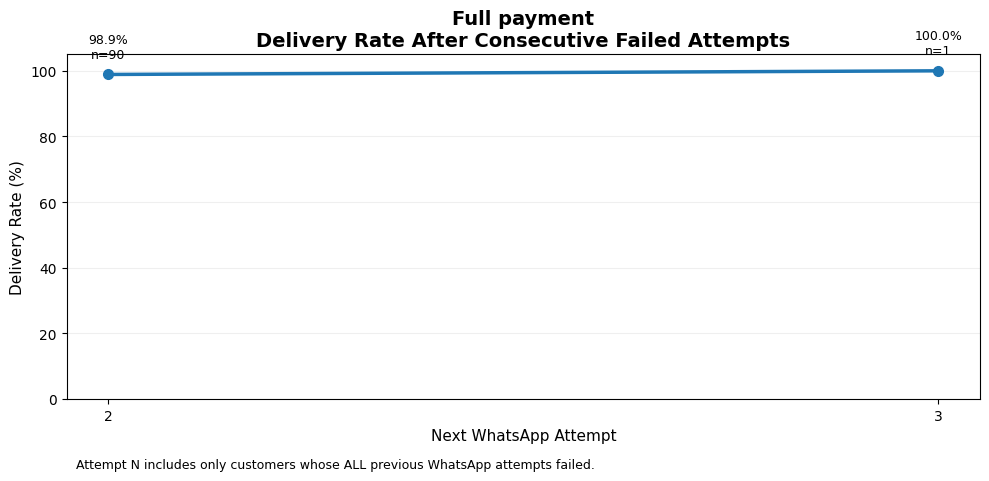

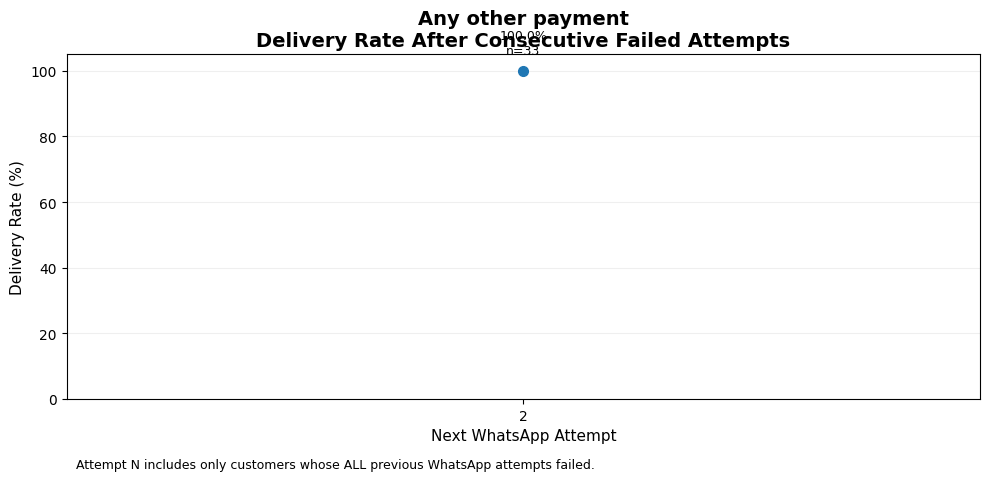

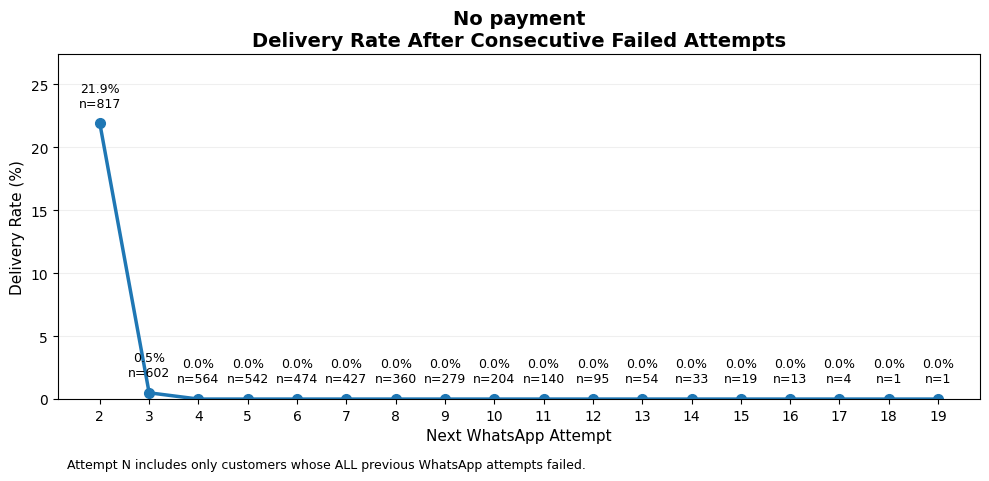

In [68]:
# ============================================================
# ONE CHART PER CUSTOMER GROUP
# ============================================================

group_order = [
    "Full payment",
    "Any other payment",
    "No payment"
]


for group in group_order:

    plot_df = (
        delivery_rate_curve.loc[
            delivery_rate_curve[
                "payment_group_consolidated"
            ] == group
        ]
        .sort_values("attempt_number")
        .copy()
    )

    if plot_df.empty:
        continue


    fig, ax = plt.subplots(
        figsize=(10, 5)
    )


    # ========================================================
    # LINE
    # ========================================================

    ax.plot(
        plot_df["attempt_number"],
        plot_df["delivery_rate_pct"],
        marker="o",
        linewidth=2.5,
        markersize=7
    )


    # ========================================================
    # LABELS
    #
    # Rate
    # n = customers reaching that attempt
    # ========================================================

    for _, row in plot_df.iterrows():

        ax.annotate(
            f'{row["delivery_rate_pct"]:.1f}%\n'
            f'n={int(row["customers"]):,}',
            (
                row["attempt_number"],
                row["delivery_rate_pct"]
            ),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9
        )


    # ========================================================
    # TITLES
    # ========================================================

    ax.set_title(
        f"{group}\n"
        "Delivery Rate After Consecutive Failed Attempts",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Next WhatsApp Attempt",
        fontsize=11
    )

    ax.set_ylabel(
        "Delivery Rate (%)",
        fontsize=11
    )


    # ========================================================
    # X AXIS
    # ========================================================

    attempts = plot_df["attempt_number"].tolist()

    ax.set_xticks(attempts)

    ax.set_xticklabels([
        f"{int(x)}"
        for x in attempts
    ])


    # ========================================================
    # Y AXIS
    # ========================================================

    max_rate = plot_df["delivery_rate_pct"].max()

    ax.set_ylim(
        0,
        min(
            105,
            max(10, max_rate * 1.25)
        )
    )


    ax.grid(
        axis="y",
        alpha=0.20
    )


    # ========================================================
    # BUSINESS EXPLANATION
    # ========================================================

    ax.text(
        0.01,
        -0.20,
        "Attempt N includes only customers whose ALL previous WhatsApp attempts failed.",
        transform=ax.transAxes,
        fontsize=9
    )


    plt.tight_layout()
    plt.show()

In [70]:
# ============================================================
# CONTACT PRESSURE BY PAYMENT GROUP
# Customer grain
#
# Groups:
#   1. Full payment
#   2. Full payment with discount
#   3. Any other payment
#   4. No payment
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Number of WhatsApp contacts per customer
# ------------------------------------------------------------

contacts_customer = (
    wa
    .groupby("customer_id", as_index=False)
    .agg(
        n_contacts=("message_id", "count")
    )
)


# ------------------------------------------------------------
# 2. Add payment outcome
# ------------------------------------------------------------

contacts_customer = (
    contacts_customer
    .merge(
        customer_payment[
            [
                "customer_id",
                "payment_group"
            ]
        ],
        on="customer_id",
        how="left",
        validate="1:1"
    )
)


# ------------------------------------------------------------
# 3. Summary by payment group
# ------------------------------------------------------------

contact_summary = (
    contacts_customer
    .groupby(
        "payment_group",
        as_index=False,
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        total_contacts=(
            "n_contacts",
            "sum"
        ),

        avg_contacts=(
            "n_contacts",
            "mean"
        ),

        median_contacts=(
            "n_contacts",
            "median"
        ),

        p25_contacts=(
            "n_contacts",
            lambda x: x.quantile(0.25)
        ),

        p75_contacts=(
            "n_contacts",
            lambda x: x.quantile(0.75)
        ),

        max_contacts=(
            "n_contacts",
            "max"
        )
    )
)


# ------------------------------------------------------------
# 4. Order groups
# ------------------------------------------------------------

group_order = [
    "Full payment",
    "Full payment with discount",
    "Any other payment",
    "No payment"
]

contact_summary["payment_group"] = pd.Categorical(
    contact_summary["payment_group"],
    categories=group_order,
    ordered=True
)

contact_summary = (
    contact_summary
    .sort_values("payment_group")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Round
# ------------------------------------------------------------

for col in [
    "avg_contacts",
    "median_contacts",
    "p25_contacts",
    "p75_contacts"
]:
    contact_summary[col] = (
        contact_summary[col].round(1)
    )


display(contact_summary)

,payment_group,customers,total_contacts,avg_contacts,median_contacts,p25_contacts,p75_contacts,max_contacts
0,Full payment,3275,11992,3.70,3.00,2.00,5.00,16
1,Full payment with discount,366,3197,8.70,9.00,7.00,10.00,18
2,Any other payment,1252,9636,7.70,8.00,5.00,10.00,19
3,No payment,6831,50581,7.40,7.00,5.00,10.00,21


In [72]:
# ============================================================
# CONTACT PRESSURE + DPD AT FULL PAYMENT
#
# Groups:
#   Full payment
#   Full payment with discount
#   Any other payment
#   No payment
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. PREPARE WHATSAPP
# ============================================================

wa_analysis = wa.copy()

wa_analysis["sent_at"] = pd.to_datetime(
    wa_analysis["sent_at"]
)

wa_analysis = (
    wa_analysis
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .copy()
)


# ============================================================
# 2. CONTACTS PER CUSTOMER
# ============================================================

contacts_customer = (
    wa_analysis
    .groupby("customer_id", as_index=False)
    .agg(
        n_contacts=("message_id", "count")
    )
)


# ============================================================
# 3. ADD PAYMENT GROUP
#
# We already validated this classification previously.
# ============================================================

contacts_customer = (
    contacts_customer
    .merge(
        customer_payment[
            [
                "customer_id",
                "payment_group"
            ]
        ],
        on="customer_id",
        how="left",
        validate="1:1"
    )
)


# ============================================================
# 4. FIND DPD AT SETTLEMENT
#
# IMPORTANT:
# Instead of recreating payment logic at message level,
# use the final validated customer classification.
#
# For customers classified as Full Payment:
# find the LAST WhatsApp observation associated with payment.
#
# For discount settlement:
# same principle.
# ============================================================

settled_ids = set(
    customer_payment.loc[
        customer_payment["payment_group"].isin([
            "Full payment",
            "Full payment with discount"
        ]),
        "customer_id"
    ]
)


settlement_history = (
    wa_analysis.loc[
        wa_analysis["customer_id"].isin(settled_ids)
        &
        (wa_analysis["amount_paid_brl"].fillna(0) > 0)
    ]
    .copy()
)


# ============================================================
# 5. LAST PAYMENT OBSERVATION FOR SETTLED CUSTOMERS
#
# This gives the observed DPD associated with the final
# payment event in the WhatsApp history.
# ============================================================

settlement_dpd = (
    settlement_history
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .groupby("customer_id")
    .tail(1)
    [
        [
            "customer_id",
            "sent_at",
            "days_past_due"
        ]
    ]
    .rename(
        columns={
            "sent_at": "settlement_observed_at",
            "days_past_due": "dpd_at_full_payment"
        }
    )
)


# ============================================================
# 6. ADD DPD TO CUSTOMER BASE
# ============================================================

contacts_customer = (
    contacts_customer
    .merge(
        settlement_dpd,
        on="customer_id",
        how="left",
        validate="1:1"
    )
)


# ============================================================
# 7. SUMMARY BY PAYMENT GROUP
# ============================================================

contact_summary = (
    contacts_customer
    .groupby(
        "payment_group",
        as_index=False,
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        total_contacts=(
            "n_contacts",
            "sum"
        ),

        avg_contacts=(
            "n_contacts",
            "mean"
        ),

        median_contacts=(
            "n_contacts",
            "median"
        ),

        p25_contacts=(
            "n_contacts",
            lambda x: x.quantile(.25)
        ),

        p75_contacts=(
            "n_contacts",
            lambda x: x.quantile(.75)
        ),

        max_contacts=(
            "n_contacts",
            "max"
        ),

        avg_dpd_at_full_payment=(
            "dpd_at_full_payment",
            "mean"
        ),

        median_dpd_at_full_payment=(
            "dpd_at_full_payment",
            "median"
        )
    )
)


# ============================================================
# 8. ORDER
# ============================================================

group_order = [
    "Full payment",
    "Full payment with discount",
    "Any other payment",
    "No payment"
]

contact_summary["payment_group"] = pd.Categorical(
    contact_summary["payment_group"],
    categories=group_order,
    ordered=True
)

contact_summary = (
    contact_summary
    .sort_values("payment_group")
    .reset_index(drop=True)
)


# ============================================================
# 9. ROUND
# ============================================================

cols_round = [
    "avg_contacts",
    "median_contacts",
    "p25_contacts",
    "p75_contacts",
    "avg_dpd_at_full_payment",
    "median_dpd_at_full_payment"
]

contact_summary[cols_round] = (
    contact_summary[cols_round]
    .round(1)
)


display(contact_summary)

,payment_group,customers,total_contacts,avg_contacts,median_contacts,p25_contacts,p75_contacts,max_contacts,avg_dpd_at_full_payment,median_dpd_at_full_payment
0,Full payment,3275,11992,3.70,3.00,2.00,5.00,16,12.20,9.00
1,Full payment with discount,366,3197,8.70,9.00,7.00,10.00,18,42.00,40.50
2,Any other payment,1252,9636,7.70,8.00,5.00,10.00,19,NaN,NaN
3,No payment,6831,50581,7.40,7.00,5.00,10.00,21,NaN,NaN


In [73]:
# ============================================================
# SUMMARY BY PAYMENT GROUP
# Contacts + DPD distribution at full payment
# ============================================================

contact_summary = (
    contacts_customer
    .groupby(
        "payment_group",
        as_index=False,
        observed=True
    )
    .agg(
        # ----------------------------------------------------
        # Population
        # ----------------------------------------------------
        customers=(
            "customer_id",
            "nunique"
        ),

        # ----------------------------------------------------
        # Contact pressure
        # ----------------------------------------------------
        total_contacts=(
            "n_contacts",
            "sum"
        ),

        avg_contacts=(
            "n_contacts",
            "mean"
        ),

        p25_contacts=(
            "n_contacts",
            lambda x: x.quantile(0.25)
        ),

        median_contacts=(
            "n_contacts",
            "median"
        ),

        p75_contacts=(
            "n_contacts",
            lambda x: x.quantile(0.75)
        ),

        max_contacts=(
            "n_contacts",
            "max"
        ),

        # ----------------------------------------------------
        # DPD at contact associated with full payment
        # ----------------------------------------------------
        avg_dpd_at_full_payment=(
            "dpd_at_full_payment",
            "mean"
        ),

        p25_dpd_at_full_payment=(
            "dpd_at_full_payment",
            lambda x: x.quantile(0.25)
        ),

        median_dpd_at_full_payment=(
            "dpd_at_full_payment",
            "median"
        ),

        p75_dpd_at_full_payment=(
            "dpd_at_full_payment",
            lambda x: x.quantile(0.75)
        ),

        max_dpd_at_full_payment=(
            "dpd_at_full_payment",
            "max"
        )
    )
)


# ============================================================
# ORDER GROUPS
# ============================================================

group_order = [
    "Full payment",
    "Full payment with discount",
    "Any other payment",
    "No payment"
]

contact_summary["payment_group"] = pd.Categorical(
    contact_summary["payment_group"],
    categories=group_order,
    ordered=True
)

contact_summary = (
    contact_summary
    .sort_values("payment_group")
    .reset_index(drop=True)
)


# ============================================================
# ROUND
# ============================================================

cols_round = [
    "avg_contacts",
    "p25_contacts",
    "median_contacts",
    "p75_contacts",
    "avg_dpd_at_full_payment",
    "p25_dpd_at_full_payment",
    "median_dpd_at_full_payment",
    "p75_dpd_at_full_payment",
    "max_dpd_at_full_payment"
]

contact_summary[cols_round] = (
    contact_summary[cols_round]
    .round(1)
)


display(contact_summary)

,payment_group,customers,total_contacts,avg_contacts,p25_contacts,median_contacts,p75_contacts,max_contacts,avg_dpd_at_full_payment,p25_dpd_at_full_payment,median_dpd_at_full_payment,p75_dpd_at_full_payment,max_dpd_at_full_payment
0,Full payment,3275,11992,3.70,2.00,3.00,5.00,16,12.20,4.00,9.00,16.00,60.00
1,Full payment with discount,366,3197,8.70,7.00,9.00,10.00,18,42.00,35.00,40.50,48.00,60.00
2,Any other payment,1252,9636,7.70,5.00,8.00,10.00,19,NaN,NaN,NaN,NaN,NaN
3,No payment,6831,50581,7.40,5.00,7.00,10.00,21,NaN,NaN,NaN,NaN,NaN


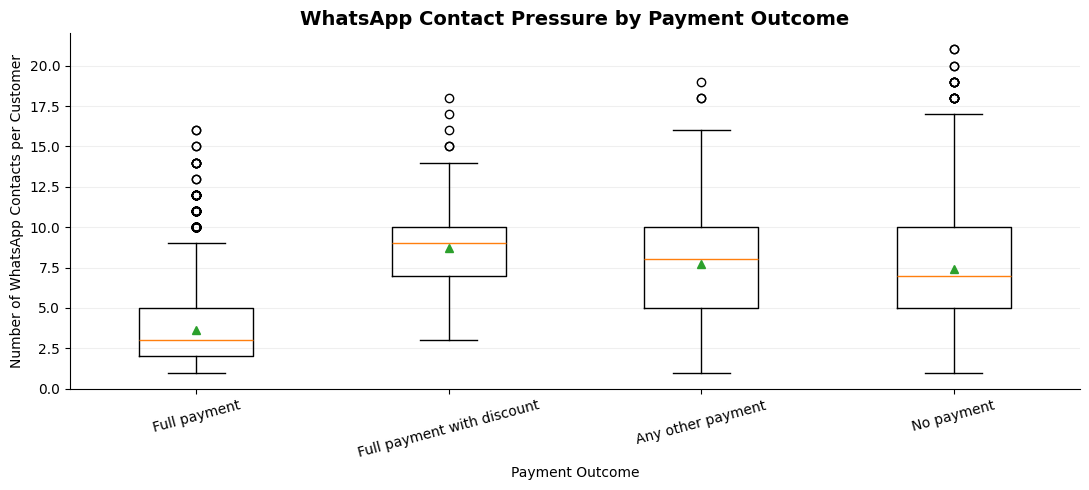

In [75]:
# ============================================================
# BOXPLOT — NUMBER OF CONTACTS PER CUSTOMER
# One box per payment group
# ============================================================

import matplotlib.pyplot as plt

group_order = [
    "Full payment",
    "Full payment with discount",
    "Any other payment",
    "No payment"
]

plot_data = [
    contacts_customer.loc[
        contacts_customer["payment_group"] == group,
        "n_contacts"
    ].dropna()
    for group in group_order
]


fig, ax = plt.subplots(figsize=(11, 5))

ax.boxplot(
    plot_data,
    tick_labels=group_order,
    showmeans=True,
    showfliers=True
)

ax.set_title(
    "WhatsApp Contact Pressure by Payment Outcome",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of WhatsApp Contacts per Customer"
)

ax.set_xlabel(
    "Payment Outcome"
)

ax.grid(
    axis="y",
    alpha=0.20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

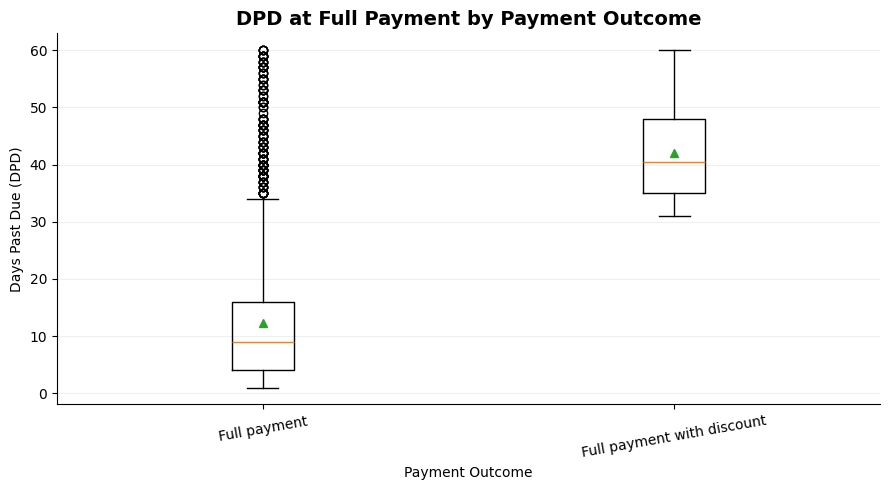

In [76]:
# ============================================================
# BOXPLOT — DPD AT FULL PAYMENT
# Full payment vs Full payment with discount
# ============================================================

import matplotlib.pyplot as plt

group_order = [
    "Full payment",
    "Full payment with discount"
]

plot_data = [
    contacts_customer.loc[
        contacts_customer["payment_group"] == group,
        "dpd_at_full_payment"
    ].dropna()
    for group in group_order
]


fig, ax = plt.subplots(figsize=(9, 5))

ax.boxplot(
    plot_data,
    tick_labels=group_order,
    showmeans=True,
    showfliers=True
)

ax.set_title(
    "DPD at Full Payment by Payment Outcome",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Days Past Due (DPD)"
)

ax.set_xlabel(
    "Payment Outcome"
)

ax.grid(
    axis="y",
    alpha=0.20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# FULL PAYMENT — INTERACTION NUMBER UNTIL SETTLEMENT
#
# Business question:
# At which interaction does full settlement occur?
#
# Customer grain = 1 row per customer who fully settled
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

# ------------------------------------------------------------
# 1. Sort customer journey chronologically
# ------------------------------------------------------------

df = (
    df
    .sort_values(["customer_id", "sent_at"])
    .copy()
)

# Interaction number in the observed WhatsApp journey
df["interaction_number"] = (
    df.groupby("customer_id")
      .cumcount()
      .add(1)
)


# ------------------------------------------------------------
# 2. Settlement threshold
#
# Normal message:
#     full settlement = 100% of outstanding balance
#
# discount_offer:
#     full settlement = 85% of outstanding balance
# ------------------------------------------------------------

df["discount_offer_flag"] = (
    df["template"]
    .astype(str)
    .str.contains("discount_offer", case=False, na=False)
)

df["settlement_threshold_brl"] = np.where(
    df["discount_offer_flag"],
    0.85 * df["outstanding_balance_brl"],
    df["outstanding_balance_brl"]
)


# ------------------------------------------------------------
# 3. Identify interaction associated with full settlement
# ------------------------------------------------------------

TOLERANCE_BRL = 0.05

df["full_payment_flag"] = (
    df["amount_paid_brl"].fillna(0)
    >=
    (df["settlement_threshold_brl"] - TOLERANCE_BRL)
)


# ------------------------------------------------------------
# 4. FIRST full-payment interaction per customer
# ------------------------------------------------------------

full_payment = (
    df.loc[df["full_payment_flag"]]
      .sort_values(["customer_id", "sent_at"])
      .groupby("customer_id", as_index=False)
      .first()
)

full_payment = full_payment[
    [
        "customer_id",
        "sent_at",
        "interaction_number",
        "days_past_due",
        "outstanding_balance_brl",
        "amount_paid_brl",
        "template"
    ]
].rename(
    columns={
        "sent_at": "full_payment_at",
        "interaction_number": "interaction_at_full_payment"
    }
)


# ------------------------------------------------------------
# 5. Distribution
# ------------------------------------------------------------

s = full_payment["interaction_at_full_payment"]

summary = pd.DataFrame({
    "metric": [
        "Customers with full payment",
        "Mean interactions",
        "Median interactions",
        "P25",
        "P75",
        "P90",
        "P95",
        "Maximum"
    ],
    "value": [
        len(full_payment),
        s.mean(),
        s.median(),
        s.quantile(0.25),
        s.quantile(0.75),
        s.quantile(0.90),
        s.quantile(0.95),
        s.max()
    ]
})

display(summary)

,metric,value
0,Customers with full payment,"3,641.00"
1,Mean interactions,4.17
2,Median interactions,3.00
3,P25,2.00
4,P75,6.00
5,P90,9.00
6,P95,10.00
7,Maximum,18.00


In [78]:
# ============================================================
# CUMULATIVE FULL PAYMENT BY INTERACTION
# ============================================================

thresholds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]

cumulative = pd.DataFrame({
    "interaction": thresholds,
    "customers_paid_by_interaction": [
        (s <= n).sum()
        for n in thresholds
    ],
    "pct_full_payments_by_interaction": [
        (s <= n).mean() * 100
        for n in thresholds
    ]
})

display(
    cumulative.style.format({
        "pct_full_payments_by_interaction": "{:.1f}%"
    })
)

,interaction,customers_paid_by_interaction,pct_full_payments_by_interaction
0,1,757,20.8%
1,2,1341,36.8%
2,3,1853,50.9%
3,4,2281,62.6%
4,5,2628,72.2%
5,6,2878,79.0%
6,7,3103,85.2%
7,8,3263,89.6%
8,9,3410,93.7%
9,10,3502,96.2%


In [79]:
# ============================================================
# EXACT INTERACTION OF FULL PAYMENT
# + CUMULATIVE DISTRIBUTION
# ============================================================

interaction_curve = (
    full_payment
    .groupby("interaction_at_full_payment")
    .size()
    .rename("full_payments")
    .reset_index()
    .sort_values("interaction_at_full_payment")
)

interaction_curve["pct_full_payments"] = (
    interaction_curve["full_payments"]
    / interaction_curve["full_payments"].sum()
    * 100
)

interaction_curve["cumulative_full_payments"] = (
    interaction_curve["full_payments"].cumsum()
)

interaction_curve["cumulative_pct"] = (
    interaction_curve["pct_full_payments"].cumsum()
)

display(
    interaction_curve.style.format({
        "pct_full_payments": "{:.1f}%",
        "cumulative_pct": "{:.1f}%"
    })
)

,interaction_at_full_payment,full_payments,pct_full_payments,cumulative_full_payments,cumulative_pct
0,1,757,20.8%,757,20.8%
1,2,584,16.0%,1341,36.8%
2,3,512,14.1%,1853,50.9%
3,4,428,11.8%,2281,62.6%
4,5,347,9.5%,2628,72.2%
5,6,250,6.9%,2878,79.0%
6,7,225,6.2%,3103,85.2%
7,8,160,4.4%,3263,89.6%
8,9,147,4.0%,3410,93.7%
9,10,92,2.5%,3502,96.2%


In [80]:
# ============================================================
# FULL PAYMENT CUSTOMERS
# Single payment vs multiple payments
# ============================================================

# Timestamp em que cada cliente atingiu full payment
settlement_time = (
    full_payment[
        ["customer_id", "full_payment_at"]
    ]
    .copy()
)

# ------------------------------------------------------------
# 1. Recover journey up to full settlement
# ------------------------------------------------------------

payments_until_settlement = (
    df.merge(
        settlement_time,
        on="customer_id",
        how="inner"
    )
)

payments_until_settlement = payments_until_settlement.loc[
    payments_until_settlement["sent_at"]
    <= payments_until_settlement["full_payment_at"]
].copy()


# ------------------------------------------------------------
# 2. Count positive payment events
# ------------------------------------------------------------

payments_until_settlement["payment_flag"] = (
    payments_until_settlement["amount_paid_brl"].fillna(0) > 0
)

payment_profile = (
    payments_until_settlement
    .groupby("customer_id")
    .agg(
        n_payments=("payment_flag", "sum"),
        total_paid_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Single vs multiple payments
# ------------------------------------------------------------

payment_profile["payment_behavior"] = np.where(
    payment_profile["n_payments"] == 1,
    "Single payment",
    "Multiple payments"
)


# ------------------------------------------------------------
# 4. Summary
# ------------------------------------------------------------

summary_payment_behavior = (
    payment_profile
    .groupby("payment_behavior")
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

summary_payment_behavior["pct_customers"] = (
    summary_payment_behavior["customers"]
    / summary_payment_behavior["customers"].sum()
    * 100
)

display(
    summary_payment_behavior.style.format({
        "pct_customers": "{:.1f}%"
    })
)

,payment_behavior,customers,pct_customers
0,Multiple payments,494,13.6%
1,Single payment,3147,86.4%


In [13]:
# ============================================================
# POLICY BACKTEST — BUILD DECISION-POINT BASE
# One row = one WhatsApp decision / send
# Only information available BEFORE the current send
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["days_past_due"] = pd.to_numeric(df["days_past_due"], errors="coerce")
df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"], errors="coerce"
).fillna(0)

df = (
    df.sort_values(["customer_id", "sent_at", "message_id"])
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# Contact number in entire observed journey
# ------------------------------------------------------------

df["contact_number"] = (
    df.groupby("customer_id")
      .cumcount()
      .add(1)
)

df["contacts_before"] = df["contact_number"] - 1


# ------------------------------------------------------------
# Flags
# ------------------------------------------------------------

status = (
    df["delivery_status"]
    .astype(str)
    .str.lower()
)

df["failed"] = status.str.startswith("failed")

df["invalid_number"] = (
    status.str.contains(
        "invalid_number",
        case=False,
        na=False
    )
)

df["discount_offer"] = (
    df["template"]
    .astype(str)
    .str.contains(
        "discount_offer",
        case=False,
        na=False
    )
)


# ------------------------------------------------------------
# Previous event information
# ------------------------------------------------------------

df["prev_failed"] = (
    df.groupby("customer_id")["failed"]
      .shift(1)
      .fillna(False)
)

df["prev2_failed"] = (
    df.groupby("customer_id")["failed"]
      .shift(2)
      .fillna(False)
)

# BEFORE current send:
# last two previous attempts both failed
df["two_consecutive_failures_before"] = (
    df["prev_failed"]
    &
    df["prev2_failed"]
)


# ------------------------------------------------------------
# Was FIRST contact invalid?
# ------------------------------------------------------------

first_invalid_customer = (
    df.groupby("customer_id")["invalid_number"]
      .transform("first")
)

df["first_contact_invalid"] = first_invalid_customer


# ------------------------------------------------------------
# Had discount offer BEFORE current message?
# ------------------------------------------------------------

df["discounts_before"] = (
    df.groupby("customer_id")["discount_offer"]
      .cumsum()
    -
    df["discount_offer"].astype(int)
)

df["never_received_discount_before"] = (
    df["discounts_before"] == 0
)


# ------------------------------------------------------------
# Previous payment information
# ------------------------------------------------------------

df["ever_paid_before"] = (
    df.groupby("customer_id")["amount_paid_brl"]
      .transform(
          lambda x:
          x.gt(0)
           .shift(fill_value=False)
           .cummax()
      )
)


print("Decision rows:", len(df))
print("Customers   :", df["customer_id"].nunique())

Decision rows: 75406
Customers   : 11724


In [14]:
# ============================================================
# POLICY RULES
# ============================================================

# ------------------------------------------------------------
# RULE 1 — STOP
# 2+ consecutive failures OR invalid number on first contact
# ------------------------------------------------------------

df["R1_STOP"] = (
    df["two_consecutive_failures_before"]
    |
    df["first_contact_invalid"]
)


# ------------------------------------------------------------
# RULE 2 — MAX PRIORITY
# DPD < 15 AND contacts <= 5
#
# Here contact_number represents current attempt.
# ------------------------------------------------------------

df["R2_MAX_PRIORITY"] = (
    ~df["R1_STOP"]
    &
    df["days_past_due"].between(1, 14)
    &
    df["contact_number"].le(5)
)


# ------------------------------------------------------------
# RULE 3 — DISCOUNT NOW
# DPD 15-30 OR contacts 5-10
# AND never received discount before
# ------------------------------------------------------------

df["R3_DISCOUNT_NOW"] = (
    ~df["R1_STOP"]
    &
    ~df["R2_MAX_PRIORITY"]
    &
    (
        df["days_past_due"].between(15, 30)
        |
        df["contact_number"].between(5, 10)
    )
    &
    df["never_received_discount_before"]
)


# ------------------------------------------------------------
# RULE 4 — LOW RETURN ZONE
# Everything else
# ------------------------------------------------------------

df["R4_LOW_RETURN"] = (
    ~df["R1_STOP"]
    &
    ~df["R2_MAX_PRIORITY"]
    &
    ~df["R3_DISCOUNT_NOW"]
)


df["policy_segment"] = np.select(
    [
        df["R1_STOP"],
        df["R2_MAX_PRIORITY"],
        df["R3_DISCOUNT_NOW"],
        df["R4_LOW_RETURN"]
    ],
    [
        "R1 — Stop",
        "R2 — Max priority",
        "R3 — Discount now",
        "R4 — Low return"
    ],
    default="Other"
)

display(
    df["policy_segment"]
    .value_counts()
    .to_frame("messages")
)

,messages
policy_segment,
R2 — Max priority,37476
R3 — Discount now,24682
R1 — Stop,8044
R4 — Low return,5204


In [15]:
# ============================================================
# R1 — STOP SIGNAL BACKTEST
# ============================================================

first_stop = (
    df.loc[df["R1_STOP"]]
      .groupby("customer_id", as_index=False)
      .head(1)
      [["customer_id", "contact_number", "sent_at"]]
      .rename(columns={
          "contact_number": "stop_contact",
          "sent_at": "stop_at"
      })
)

post_stop = df.merge(
    first_stop,
    on="customer_id",
    how="inner"
)

post_stop = post_stop.loc[
    post_stop["contact_number"] > post_stop["stop_contact"]
].copy()


r1_summary = pd.DataFrame({
    "customers_with_stop_signal": [
        first_stop["customer_id"].nunique()
    ],

    "customers_retried_after_stop": [
        post_stop["customer_id"].nunique()
    ],

    "messages_after_stop": [
        len(post_stop)
    ],

    "successful_messages_after_stop": [
        (~post_stop["failed"]).sum()
    ],

    "customers_with_payment_after_stop": [
        post_stop.loc[
            post_stop["amount_paid_brl"] > 0,
            "customer_id"
        ].nunique()
    ],

    "attributed_recovery_after_stop": [
        post_stop["amount_paid_brl"].sum()
    ]
})

display(r1_summary)

,customers_with_stop_signal,customers_retried_after_stop,messages_after_stop,successful_messages_after_stop,customers_with_payment_after_stop,attributed_recovery_after_stop
0,1390,1244,6750,94,3,"3,254.26"


In [16]:
# ============================================================
# R2 — EARLY CONTACT WINDOW
# Same DPD range, different contact pressure
# ============================================================

r2 = df.loc[
    (~df["R1_STOP"])
    &
    df["days_past_due"].between(1, 14)
].copy()


r2["contact_window"] = np.where(
    r2["contact_number"].le(5),
    "1-5 contacts",
    "6+ contacts"
)


r2_summary = (
    r2.groupby("contact_window")
      .agg(
          messages=("message_id", "size"),
          customers=("customer_id", "nunique"),

          messages_with_payment=(
              "amount_paid_brl",
              lambda x: (x > 0).sum()
          ),

          customers_with_payment=(
              "customer_id",
              lambda x:
              x[r2.loc[x.index, "amount_paid_brl"] > 0]
              .nunique()
          ),

          attributed_recovery_brl=(
              "amount_paid_brl",
              "sum"
          )
      )
      .reset_index()
)

r2_summary["payment_customer_rate"] = (
    r2_summary["customers_with_payment"]
    /
    r2_summary["customers"]
)

r2_summary["recovery_per_message"] = (
    r2_summary["attributed_recovery_brl"]
    /
    r2_summary["messages"]
)

display(
    r2_summary.style.format({
        "payment_customer_rate": "{:.1%}",
        "attributed_recovery_brl": "R$ {:,.2f}",
        "recovery_per_message": "R$ {:,.2f}"
    })
)

,contact_window,messages,customers,messages_with_payment,customers_with_payment,attributed_recovery_brl,payment_customer_rate,recovery_per_message
0,1-5 contacts,37476,11084,3503,3286,"R$ 2,221,473.69",29.6%,R$ 59.28
1,6+ contacts,2588,1677,175,174,"R$ 118,309.30",10.4%,R$ 45.71


In [17]:
# ============================================================
# R3 — EARLY DISCOUNT TEST
#
# Eligible:
# DPD 15-30 OR contact 5-10
# No previous discount
# ============================================================

eligible = df.loc[
    (~df["R1_STOP"])
    &
    (
        df["days_past_due"].between(15, 30)
        |
        df["contact_number"].between(5, 10)
    )
    &
    df["never_received_discount_before"]
].copy()


# First eligibility event per customer
first_eligible = (
    eligible
    .groupby("customer_id", as_index=False)
    .head(1)
    .copy()
)


# Did customer subsequently receive discount?
discount_dates = (
    df.loc[df["discount_offer"]]
      .groupby("customer_id", as_index=False)
      .agg(first_discount_at=("sent_at", "min"))
)


first_eligible = first_eligible.merge(
    discount_dates,
    on="customer_id",
    how="left"
)


first_eligible["received_discount_after_eligibility"] = (
    first_eligible["first_discount_at"].notna()
    &
    (
        first_eligible["first_discount_at"]
        >=
        first_eligible["sent_at"]
    )
)


# Ever paid AFTER eligibility
future = df.merge(
    first_eligible[
        ["customer_id", "sent_at"]
    ].rename(
        columns={"sent_at": "eligibility_at"}
    ),
    on="customer_id",
    how="inner"
)

future = future.loc[
    future["sent_at"] >= future["eligibility_at"]
]


future_outcome = (
    future.groupby("customer_id", as_index=False)
          .agg(
              paid_after_eligibility=(
                  "amount_paid_brl",
                  lambda x: (x > 0).any()
              ),

              recovery_after_eligibility=(
                  "amount_paid_brl",
                  "sum"
              )
          )
)


r3 = first_eligible.merge(
    future_outcome,
    on="customer_id",
    how="left"
)


r3["group"] = np.where(
    r3["received_discount_after_eligibility"],
    "Received early discount",
    "Did not receive early discount"
)


r3_summary = (
    r3.groupby("group")
      .agg(
          customers=("customer_id", "nunique"),
          customers_paid=(
              "paid_after_eligibility",
              "sum"
          ),
          attributed_recovery_brl=(
              "recovery_after_eligibility",
              "sum"
          )
      )
      .reset_index()
)

r3_summary["payment_rate"] = (
    r3_summary["customers_paid"]
    /
    r3_summary["customers"]
)

display(
    r3_summary.style.format({
        "payment_rate": "{:.1%}",
        "attributed_recovery_brl": "R$ {:,.2f}"
    })
)

,group,customers,customers_paid,attributed_recovery_brl,payment_rate
0,Did not receive early discount,4144,1429,"R$ 970,512.86",34.5%
1,Received early discount,3279,740,"R$ 410,483.00",22.6%


In [18]:
# ============================================================
# R4 — LOW RETURN ZONE
# Return by contact number
# ============================================================

low_return = df.loc[
    df["R4_LOW_RETURN"]
].copy()


low_return["contact_bucket"] = pd.cut(
    low_return["contact_number"],
    bins=[
        0,
        5,
        10,
        15,
        20,
        np.inf
    ],
    labels=[
        "1-5",
        "6-10",
        "11-15",
        "16-20",
        "20+"
    ]
)


r4_summary = (
    low_return
    .groupby(
        "contact_bucket",
        observed=False
    )
    .agg(
        messages=("message_id", "size"),
        customers=("customer_id", "nunique"),

        payment_messages=(
            "amount_paid_brl",
            lambda x: (x > 0).sum()
        ),

        attributed_recovery_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
    .reset_index()
)


r4_summary["payment_per_message"] = (
    r4_summary["payment_messages"]
    /
    r4_summary["messages"]
)

r4_summary["recovery_per_message_brl"] = (
    r4_summary["attributed_recovery_brl"]
    /
    r4_summary["messages"]
)

display(
    r4_summary.style.format({
        "payment_per_message": "{:.2%}",
        "attributed_recovery_brl": "R$ {:,.2f}",
        "recovery_per_message_brl": "R$ {:,.2f}"
    })
)

,contact_bucket,messages,customers,payment_messages,attributed_recovery_brl,payment_per_message,recovery_per_message_brl
0,1-5,351,230,38,"R$ 22,990.21",10.83%,R$ 65.50
1,6-10,2148,1311,158,"R$ 87,345.67",7.36%,R$ 40.66
2,11-15,2606,1276,168,"R$ 96,093.84",6.45%,R$ 36.87
3,16-20,97,50,5,"R$ 4,313.17",5.15%,R$ 44.47
4,20+,2,2,0,R$ 0.00,0.00%,R$ 0.00


In [20]:
# ============================================================
# CUSTOMERS WHO ENTERED IN THE MONTH
# AND SETTLED WITHIN THE SAME MONTH
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["month"] = df["sent_at"].dt.to_period("M")

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"], errors="coerce"
).fillna(0)

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"], errors="coerce"
)

df = (
    df.sort_values(["customer_id", "sent_at", "message_id"])
      .reset_index(drop=True)
)


# ------------------------------------------------------------
# 1. ENTRY MONTH
# First observed month in WhatsApp history
# ------------------------------------------------------------

first_month = (
    df.groupby("customer_id")["month"]
      .min()
      .rename("entry_month")
)

df = df.merge(
    first_month,
    on="customer_id",
    how="left"
)

df["entered_this_month"] = (
    df["month"] == df["entry_month"]
)


# ------------------------------------------------------------
# 2. MONTHLY NEW-CUSTOMER POPULATION
# ------------------------------------------------------------

new_customers = (
    df.loc[df["entered_this_month"]]
      [["customer_id", "month"]]
      .drop_duplicates()
)


# ------------------------------------------------------------
# 3. RECONSTRUCT PAYMENTS
#
# Same heuristic we've been using:
# same customer + same amount within <=72h
# treated as same economic payment
# ------------------------------------------------------------

payments = (
    df.loc[df["amount_paid_brl"] > 0]
      .sort_values(
          ["customer_id", "sent_at", "message_id"]
      )
      .copy()
)

payments["prev_payment_at"] = (
    payments.groupby(
        ["customer_id", "amount_paid_brl"]
    )["sent_at"]
    .shift()
)

payments["hours_since_same_amount"] = (
    (
        payments["sent_at"]
        -
        payments["prev_payment_at"]
    )
    .dt.total_seconds()
    / 3600
)

payments["keep_payment"] = (
    payments["prev_payment_at"].isna()
    |
    (payments["hours_since_same_amount"] > 72)
)

payments_dedup = (
    payments.loc[payments["keep_payment"]]
    .copy()
)


# ------------------------------------------------------------
# 4. TOTAL PAYMENT WITHIN ENTRY MONTH
# ------------------------------------------------------------

monthly_payment = (
    payments_dedup
    .groupby(
        ["customer_id", "month"],
        as_index=False
    )
    .agg(
        total_payment_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)


# ------------------------------------------------------------
# 5. INITIAL OBSERVED BALANCE IN ENTRY MONTH
# ------------------------------------------------------------

initial_balance = (
    df.loc[df["entered_this_month"]]
      .groupby(
          ["customer_id", "month"],
          as_index=False
      )
      .first()[
          [
              "customer_id",
              "month",
              "outstanding_balance_brl"
          ]
      ]
      .rename(
          columns={
              "outstanding_balance_brl":
              "initial_balance_brl"
          }
      )
)


# ------------------------------------------------------------
# 6. DID CUSTOMER RECEIVE DISCOUNT OFFER
# IN ENTRY MONTH?
# ------------------------------------------------------------

df["discount_offer_flag"] = (
    df["template"]
    .astype(str)
    .str.contains(
        "discount_offer",
        case=False,
        na=False
    )
)

discount_month = (
    df.loc[df["entered_this_month"]]
      .groupby(
          ["customer_id", "month"],
          as_index=False
      )
      .agg(
          received_discount=(
              "discount_offer_flag",
              "max"
          )
      )
)


# ------------------------------------------------------------
# 7. BUILD NEW CUSTOMER COHORT
# ------------------------------------------------------------

cohort = (
    new_customers
    .merge(
        initial_balance,
        on=["customer_id", "month"],
        how="left"
    )
    .merge(
        monthly_payment,
        on=["customer_id", "month"],
        how="left"
    )
    .merge(
        discount_month,
        on=["customer_id", "month"],
        how="left"
    )
)

cohort["total_payment_brl"] = (
    cohort["total_payment_brl"]
    .fillna(0)
)

cohort["received_discount"] = (
    cohort["received_discount"]
    .fillna(False)
)


# ------------------------------------------------------------
# 8. SETTLEMENT THRESHOLD
#
# Normal: 100%
# Discount: 85%
# ------------------------------------------------------------

cohort["settlement_threshold_brl"] = np.where(
    cohort["received_discount"],
    cohort["initial_balance_brl"] * 0.85,
    cohort["initial_balance_brl"]
)

cohort["settled_same_month"] = (
    cohort["total_payment_brl"]
    >=
    (cohort["settlement_threshold_brl"] - 0.05)
)


# ------------------------------------------------------------
# 9. MONTHLY SUMMARY
# ------------------------------------------------------------

summary = (
    cohort
    .groupby("month")
    .agg(
        customers_entered=(
            "customer_id",
            "nunique"
        ),

        customers_settled_same_month=(
            "settled_same_month",
            "sum"
        )
    )
    .reset_index()
)

summary["pct_settled_same_month"] = (
    summary["customers_settled_same_month"]
    /
    summary["customers_entered"]
)


display(
    summary.style.format({
        "pct_settled_same_month": "{:.1%}"
    })
)

,month,customers_entered,customers_settled_same_month,pct_settled_same_month
0,2026-06,3681,763,20.7%
1,2026-07,4155,878,21.1%
2,2026-08,3888,822,21.1%


In [21]:
# ============================================================
# 9. MONTHLY SUMMARY
# Customers entering month + same-month settlement
# + outstanding balance + recovered amount
# ============================================================

summary = (
    cohort
    .groupby("month")
    .agg(
        # --------------------------------------------
        # Population
        # --------------------------------------------
        customers_entered=(
            "customer_id",
            "nunique"
        ),

        customers_settled_same_month=(
            "settled_same_month",
            "sum"
        ),

        # --------------------------------------------
        # Total outstanding of customers entering
        # --------------------------------------------
        entered_outstanding_brl=(
            "initial_balance_brl",
            "sum"
        ),

        # --------------------------------------------
        # Outstanding + recovery ONLY among customers
        # who settled within the same month
        # --------------------------------------------
        settled_outstanding_brl=(
            "initial_balance_brl",
            lambda x: x[
                cohort.loc[x.index, "settled_same_month"]
            ].sum()
        ),

        recovered_from_settled_brl=(
            "total_payment_brl",
            lambda x: x[
                cohort.loc[x.index, "settled_same_month"]
            ].sum()
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# Settlement rate — customers
# ------------------------------------------------------------

summary["pct_settled_same_month"] = (
    summary["customers_settled_same_month"]
    /
    summary["customers_entered"]
)


# ------------------------------------------------------------
# % of incoming outstanding associated with customers
# that settled within the month
# ------------------------------------------------------------

summary["pct_entered_outstanding_settled"] = (
    summary["settled_outstanding_brl"]
    /
    summary["entered_outstanding_brl"]
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(
    summary.style.format({
        "pct_settled_same_month": "{:.1%}",
        "pct_entered_outstanding_settled": "{:.1%}",

        "entered_outstanding_brl": "R$ {:,.2f}",
        "settled_outstanding_brl": "R$ {:,.2f}",
        "recovered_from_settled_brl": "R$ {:,.2f}"
    })
)

,month,customers_entered,customers_settled_same_month,entered_outstanding_brl,settled_outstanding_brl,recovered_from_settled_brl,pct_settled_same_month,pct_entered_outstanding_settled
0,2026-06,3681,763,"R$ 3,125,092.27","R$ 632,644.37","R$ 632,644.38",20.7%,20.2%
1,2026-07,4155,878,"R$ 3,501,007.03","R$ 694,953.22","R$ 694,615.74",21.1%,19.9%
2,2026-08,3888,822,"R$ 3,339,441.03","R$ 657,382.71","R$ 657,244.42",21.1%,19.7%


In [22]:
# ============================================================
# SEP REMAINING CUSTOMERS WITH HISTORICAL TERMINAL WA SIGNAL
#
# Population:
# Sep customers that were already observed in August
#
# Stop signals:
# - failed_invalid_number
# - failed_blocked
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Prepare bases
# ------------------------------------------------------------

wa_hist = wa.copy()
wa_hist["sent_at"] = pd.to_datetime(wa_hist["sent_at"])

sep = queue.copy()   # change if your Sep queue dataframe has another name

# ------------------------------------------------------------
# 2. August customers
# ------------------------------------------------------------

aug_ids = set(
    wa_hist.loc[
        wa_hist["sent_at"].dt.to_period("M") == pd.Period("2026-08"),
        "customer_id"
    ]
)

# ------------------------------------------------------------
# 3. September remaining population
# ------------------------------------------------------------

sep_remaining = (
    sep.loc[
        sep["customer_id"].isin(aug_ids)
    ]
    .copy()
)

print(
    "Sep remaining customers:",
    sep_remaining["customer_id"].nunique()
)

# Expected from your reconciliation: 5,382


# ------------------------------------------------------------
# 4. Historical terminal failure signals
# BEFORE September
# ------------------------------------------------------------

status = (
    wa_hist["delivery_status"]
    .astype(str)
    .str.lower()
)

wa_hist["invalid_number_signal"] = (
    status.str.contains(
        "invalid_number",
        case=False,
        na=False
    )
)

wa_hist["blocked_signal"] = (
    status.str.contains(
        "blocked",
        case=False,
        na=False
    )
)

wa_hist["terminal_signal"] = (
    wa_hist["invalid_number_signal"]
    |
    wa_hist["blocked_signal"]
)


# ------------------------------------------------------------
# 5. Historical signal at customer level
# ------------------------------------------------------------

customer_signal = (
    wa_hist
    .groupby("customer_id", as_index=False)
    .agg(
        ever_invalid_number=(
            "invalid_number_signal",
            "max"
        ),

        ever_blocked=(
            "blocked_signal",
            "max"
        ),

        ever_terminal_signal=(
            "terminal_signal",
            "max"
        )
    )
)


# ------------------------------------------------------------
# 6. Merge into September remaining population
# ------------------------------------------------------------

sep_remaining = (
    sep_remaining
    .merge(
        customer_signal,
        on="customer_id",
        how="left"
    )
)

for col in [
    "ever_invalid_number",
    "ever_blocked",
    "ever_terminal_signal"
]:
    sep_remaining[col] = (
        sep_remaining[col]
        .fillna(False)
        .astype(bool)
    )


# ------------------------------------------------------------
# 7. Split signals WITHOUT double counting
# ------------------------------------------------------------

sep_remaining["signal_group"] = np.select(
    [
        (
            sep_remaining["ever_invalid_number"]
            &
            sep_remaining["ever_blocked"]
        ),

        sep_remaining["ever_invalid_number"],

        sep_remaining["ever_blocked"]
    ],
    [
        "Invalid number + blocked",
        "Invalid number only",
        "Blocked only"
    ],
    default="No terminal signal"
)


# ------------------------------------------------------------
# 8. Summary
# ------------------------------------------------------------

total_remaining = (
    sep_remaining["customer_id"].nunique()
)

stop_customers = (
    sep_remaining.loc[
        sep_remaining["ever_terminal_signal"],
        "customer_id"
    ]
    .nunique()
)


summary = (
    sep_remaining
    .groupby("signal_group")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)

summary["pct_remaining_customers"] = (
    summary["customers"]
    /
    total_remaining
)


print("=" * 70)
print("SEPTEMBER — PRE-EXISTING CUSTOMERS")
print("=" * 70)

print(
    f"Remaining from August          : {total_remaining:,}"
)

print(
    f"Historical terminal signal    : {stop_customers:,}"
)

print(
    f"% removable from WhatsApp     : "
    f"{stop_customers / total_remaining:.1%}"
)

print(
    f"Still contactable via WhatsApp: "
    f"{total_remaining - stop_customers:,}"
)

display(
    summary.style.format({
        "outstanding_balance_brl": "R$ {:,.2f}",
        "pct_remaining_customers": "{:.1%}"
    })
)

Sep remaining customers: 5350
SEPTEMBER — PRE-EXISTING CUSTOMERS
Remaining from August          : 5,350
Historical terminal signal    : 888
% removable from WhatsApp     : 16.6%
Still contactable via WhatsApp: 4,462


,signal_group,customers,outstanding_balance_brl,pct_remaining_customers
0,Blocked only,486,"R$ 397,967.43",9.1%
1,Invalid number only,402,"R$ 360,238.21",7.5%
2,No terminal signal,4462,"R$ 3,596,486.73",83.4%


In [23]:
# ============================================================
# DAILY WHATSAPP MESSAGE VOLUME
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["date"] = df["sent_at"].dt.normalize()
df["month"] = df["sent_at"].dt.to_period("M")


# ------------------------------------------------------------
# 1. Daily volume
# ------------------------------------------------------------

daily = (
    df.groupby(["month", "date"], as_index=False)
      .agg(
          messages=("message_id", "count"),
          customers=("customer_id", "nunique")
      )
)

daily["messages_per_customer"] = (
    daily["messages"] / daily["customers"]
)


display(
    daily.style.format({
        "messages_per_customer": "{:.2f}"
    })
)

,month,date,messages,customers,messages_per_customer
0,2026-06,2026-06-01 00:00:00,46,46,1.00
1,2026-06,2026-06-02 00:00:00,86,86,1.00
2,2026-06,2026-06-03 00:00:00,121,121,1.00
3,2026-06,2026-06-04 00:00:00,170,170,1.00
4,2026-06,2026-06-05 00:00:00,234,234,1.00
5,2026-06,2026-06-06 00:00:00,136,136,1.00
6,2026-06,2026-06-07 00:00:00,94,94,1.00
7,2026-06,2026-06-08 00:00:00,378,378,1.00
8,2026-06,2026-06-09 00:00:00,404,404,1.00
9,2026-06,2026-06-10 00:00:00,451,451,1.00


In [24]:
# ============================================================
# DAILY MESSAGE PRESSURE — MONTHLY SUMMARY
# ============================================================

monthly_daily_summary = (
    daily.groupby("month")
         .agg(
             active_days=("date", "nunique"),
             total_messages=("messages", "sum"),
             avg_messages_per_day=("messages", "mean"),
             median_messages_per_day=("messages", "median"),
             p75_messages_per_day=(
                 "messages",
                 lambda x: x.quantile(.75)
             ),
             p90_messages_per_day=(
                 "messages",
                 lambda x: x.quantile(.90)
             ),
             max_messages_single_day=("messages", "max"),
             avg_customers_per_day=("customers", "mean")
         )
         .reset_index()
)

display(
    monthly_daily_summary.style.format({
        "avg_messages_per_day": "{:,.1f}",
        "median_messages_per_day": "{:,.1f}",
        "p75_messages_per_day": "{:,.1f}",
        "p90_messages_per_day": "{:,.1f}",
        "avg_customers_per_day": "{:,.1f}"
    })
)

,month,active_days,total_messages,avg_messages_per_day,median_messages_per_day,p75_messages_per_day,p90_messages_per_day,max_messages_single_day,avg_customers_per_day
0,2026-06,30,14465,482.2,451.5,725.0,839.9,1022,482.2
1,2026-07,31,29716,958.6,"1,087.0","1,190.0","1,268.0",1327,958.6
2,2026-08,31,31225,"1,007.3","1,225.0","1,261.0","1,285.0",1303,"1,007.3"


In [25]:
# ============================================================
# WEEKEND ANALYSIS — 01. OPERATIONAL EXPOSURE
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df["day_of_week"] = df["sent_at"].dt.day_name()
df["weekday_num"] = df["sent_at"].dt.dayofweek

df["weekend_flag"] = df["weekday_num"] >= 5
df["send_day_type"] = np.where(
    df["weekend_flag"],
    "Weekend",
    "Weekday"
)

operational_exposure = (
    df.groupby("send_day_type", observed=False)
      .agg(
          messages=("message_id", "nunique"),
          customers=("customer_id", "nunique"),
      )
      .reset_index()
)

operational_exposure["pct_messages"] = (
    operational_exposure["messages"]
    / operational_exposure["messages"].sum()
    * 100
)

display(operational_exposure)

,send_day_type,messages,customers,pct_messages
0,Weekday,64778,11528,85.91
1,Weekend,10628,6829,14.09


In [26]:
# ============================================================
# WEEKEND ANALYSIS — 02. PERFORMANCE BY DAY OF WEEK
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily = (
    df.groupby("day_of_week", observed=False)
      .agg(
          messages=("message_id", "nunique"),
          customers=("customer_id", "nunique"),
          total_recovered_brl=("amount_paid_brl", "sum")
      )
      .reindex(day_order)
      .reset_index()
)

daily["recovery_per_message_brl"] = (
    daily["total_recovered_brl"] /
    daily["messages"]
)

display(daily)

,day_of_week,messages,customers,total_recovered_brl,recovery_per_message_brl
0,Monday,13789,8260,"643,358.40",46.66
1,Tuesday,12724,7675,"596,486.60",46.88
2,Wednesday,12635,7649,"591,255.79",46.80
3,Thursday,12835,7774,"561,563.67",43.75
4,Friday,12795,7732,"610,890.15",47.74
5,Saturday,6575,5092,"274,434.99",41.74
6,Sunday,4053,3441,"181,315.70",44.74


In [27]:
# ============================================================
# WEEKEND ANALYSIS — 03. WEEKDAY VS WEEKEND
# ============================================================

week_comparison = (
    df.groupby("send_day_type", observed=False)
      .agg(
          messages=("message_id", "nunique"),
          customers=("customer_id", "nunique"),
          recovered_brl=("amount_paid_brl", "sum")
      )
      .reset_index()
)

week_comparison["recovery_per_message_brl"] = (
    week_comparison["recovered_brl"] /
    week_comparison["messages"]
)

week_comparison["recovery_per_customer_brl"] = (
    week_comparison["recovered_brl"] /
    week_comparison["customers"]
)

display(week_comparison)

,send_day_type,messages,customers,recovered_brl,recovery_per_message_brl,recovery_per_customer_brl
0,Weekday,64778,11528,"3,003,554.61",46.37,260.54
1,Weekend,10628,6829,"455,750.69",42.88,66.74


In [28]:
df["payment_after_send_flag"] = (
    df["amount_paid_brl"].fillna(0) > 0
)

payment_response = (
    df.groupby("send_day_type", observed=False)
      .agg(
          messages=("message_id", "nunique"),
          payment_events=("payment_after_send_flag", "sum")
      )
      .reset_index()
)

payment_response["payment_response_rate"] = (
    payment_response["payment_events"] /
    payment_response["messages"]
)

display(payment_response)

,send_day_type,messages,payment_events,payment_response_rate
0,Weekday,64778,4880,0.08
1,Weekend,10628,746,0.07


In [29]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    df["send_day_type"],
    df["payment_after_send_flag"]
)

display(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("=" * 70)
print("WEEKDAY VS WEEKEND — PAYMENT ASSOCIATION")
print("=" * 70)
print(f"Chi-square : {chi2:,.4f}")
print(f"P-value    : {p_value:.8f}")
print(f"DoF        : {dof}")

payment_after_send_flag,False,True
send_day_type,,
Weekday,59898,4880
Weekend,9882,746


WEEKDAY VS WEEKEND — PAYMENT ASSOCIATION
Chi-square : 3.4227
P-value    : 0.06430707
DoF        : 1


In [30]:
rates = (
    df.groupby("send_day_type")["payment_after_send_flag"]
      .mean()
)

weekday_rate = rates.get("Weekday", np.nan)
weekend_rate = rates.get("Weekend", np.nan)

relative_change = (
    (weekend_rate / weekday_rate - 1) * 100
)

print("=" * 70)
print("PAYMENT RESPONSE EFFECT")
print("=" * 70)

print(f"Weekday payment response : {weekday_rate:.2%}")
print(f"Weekend payment response : {weekend_rate:.2%}")
print(f"Relative difference      : {relative_change:+.1f}%")

PAYMENT RESPONSE EFFECT
Weekday payment response : 7.53%
Weekend payment response : 7.02%
Relative difference      : -6.8%


In [31]:
# ============================================================
# WEEKEND ANALYSIS — 04. WITHIN-CUSTOMER COMPARISON
# Customers exposed to BOTH weekday and weekend
# ============================================================

customer_exposure = (
    df.groupby("customer_id")["send_day_type"]
      .nunique()
)

both_ids = customer_exposure[
    customer_exposure == 2
].index

within_customer = df[
    df["customer_id"].isin(both_ids)
].copy()

within_summary = (
    within_customer
    .groupby("send_day_type", observed=False)
    .agg(
        messages=("message_id", "nunique"),
        customers=("customer_id", "nunique"),
        payment_events=("payment_after_send_flag", "sum"),
        recovered_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
)

within_summary["payment_response_rate"] = (
    within_summary["payment_events"] /
    within_summary["messages"]
)

within_summary["recovery_per_message_brl"] = (
    within_summary["recovered_brl"] /
    within_summary["messages"]
)

display(within_summary)

,send_day_type,messages,customers,payment_events,recovered_brl,payment_response_rate,recovery_per_message_brl
0,Weekday,43049,6633,2044,"1,142,401.64",0.05,26.54
1,Weekend,10414,6633,629,"362,773.95",0.06,34.84


In [33]:
print(wa.columns.tolist())

['message_id', 'customer_id', 'sent_at', 'template', 'n_msgs_last_14d', 'days_past_due', 'outstanding_balance_brl', 'monthly_salary_brl', 'payday_day_of_month', 'n_prior_transactions', 'account_age_months', 'days_since_last_app_login', 'state_uf', 'delivery_status', 'interaction', 'paid_within_72h', 'amount_paid_brl']


In [34]:
for col in wa.columns:
    if any(x in col.lower() for x in ["read", "click", "status", "deliver", "payment"]):
        print(col, "->", wa[col].dropna().unique()[:20])

delivery_status -> ['delivered' 'failed_unreachable' 'failed_invalid_number' 'failed_blocked']


In [79]:
# ============================================================
# CUSTOMER RECOVERY — JUN-AUG
# Grain: 1 row per customer
# ============================================================

import pandas as pd
import numpy as np

df = wa.copy()

# ------------------------------------------------------------
# 1. Basic preparation
# ------------------------------------------------------------

df["sent_at"] = pd.to_datetime(df["sent_at"])

# Detect payment column
payment_candidates = [
    "payment_amount_brl",
    "payment_brl",
    "amount_paid_brl",
    "recovered_amount_brl",
    "payment_amount"
]

payment_col = next(
    (c for c in payment_candidates if c in df.columns),
    None
)

if payment_col is None:
    raise ValueError(
        "Payment column not found. Available columns:\n"
        + "\n".join(df.columns)
    )

df[payment_col] = pd.to_numeric(
    df[payment_col],
    errors="coerce"
).fillna(0)

print(f"Payment column used: {payment_col}")


# ------------------------------------------------------------
# 2. Customer-level payment
# IMPORTANT:
# If the same payment appears repeated across multiple WhatsApp
# rows, this sum should NOT be used for financial recovery.
#
# Here we only need to know whether customer paid > 0.
# ------------------------------------------------------------

customer_payment = (
    df.groupby("customer_id")
      .agg(
          any_payment=(
              payment_col,
              lambda x: (x > 0).any()
          ),
          first_balance=(
              "outstanding_balance_brl",
              "first"
          ),
          last_balance=(
              "outstanding_balance_brl",
              "last"
          )
      )
      .reset_index()
)


# ------------------------------------------------------------
# 3. FULLY SETTLED
#
# First try to use an existing fully-settled flag from the
# analyses we already built.
# ------------------------------------------------------------

settled_candidates = [
    "fully_settled",
    "full_settled",
    "is_fully_settled",
    "fully_settled_flag",
    "full_payment_flag"
]

settled_col = next(
    (c for c in settled_candidates if c in df.columns),
    None
)

if settled_col is not None:

    print(f"Fully-settled flag used: {settled_col}")

    customer_settled = (
        df.groupby("customer_id")[settled_col]
          .max()
          .astype(bool)
          .rename("fully_settled")
          .reset_index()
    )

    customer_payment = customer_payment.merge(
        customer_settled,
        on="customer_id",
        how="left"
    )

else:

    print(
        "\nWARNING: No existing fully-settled flag found."
        "\nThe customer counts below will show ANY PAYMENT,"
        "\nbut fully-settled should use the previously validated"
        "\nsettlement logic (including discount_offer = 85%)."
    )

    customer_payment["fully_settled"] = False


# ------------------------------------------------------------
# 4. Customer classification
# ------------------------------------------------------------

customer_payment["payment_status"] = np.select(
    [
        customer_payment["fully_settled"],
        customer_payment["any_payment"]
    ],
    [
        "Fully settled",
        "Partial payment only"
    ],
    default="No payment"
)


# ------------------------------------------------------------
# 5. KPIs
# ------------------------------------------------------------

total_customers = customer_payment["customer_id"].nunique()

customers_any_payment = (
    customer_payment["any_payment"].sum()
)

customers_fully_settled = (
    customer_payment["fully_settled"].sum()
)

customers_partial_only = (
    (
        customer_payment["any_payment"]
        & ~customer_payment["fully_settled"]
    ).sum()
)

customers_no_payment = (
    (~customer_payment["any_payment"]).sum()
)


pct_any_payment = (
    customers_any_payment
    / total_customers
)

pct_fully_total = (
    customers_fully_settled
    / total_customers
)

pct_partial_total = (
    customers_partial_only
    / total_customers
)

pct_no_payment = (
    customers_no_payment
    / total_customers
)

pct_fully_among_payers = (
    customers_fully_settled
    / customers_any_payment
    if customers_any_payment > 0
    else np.nan
)

pct_partial_among_payers = (
    customers_partial_only
    / customers_any_payment
    if customers_any_payment > 0
    else np.nan
)


# ------------------------------------------------------------
# 6. Executive table
# ------------------------------------------------------------

summary = pd.DataFrame({

    "Metric": [
        "Total customers",
        "Customers with any payment",
        "Fully settled",
        "Partial payment only",
        "No payment"
    ],

    "Customers": [
        total_customers,
        customers_any_payment,
        customers_fully_settled,
        customers_partial_only,
        customers_no_payment
    ],

    "% total customers": [
        1,
        pct_any_payment,
        pct_fully_total,
        pct_partial_total,
        pct_no_payment
    ]
})

summary["% total customers"] = (
    summary["% total customers"]
    .map(lambda x: f"{x:.1%}")
)


# ------------------------------------------------------------
# 7. Print executive result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CUSTOMER RECOVERY — JUN–AUG")
print("=" * 70)

print(
    f"Total customers                  : "
    f"{total_customers:,}"
)

print(
    f"Customers with ANY payment       : "
    f"{customers_any_payment:,} "
    f"({pct_any_payment:.1%})"
)

print(
    f"Fully settled                    : "
    f"{customers_fully_settled:,} "
    f"({pct_fully_total:.1%} of total)"
)

print(
    f"Partial payment only             : "
    f"{customers_partial_only:,} "
    f"({pct_partial_total:.1%} of total)"
)

print(
    f"No payment                       : "
    f"{customers_no_payment:,} "
    f"({pct_no_payment:.1%})"
)

print("\n" + "-" * 70)
print("AMONG CUSTOMERS WHO PAID")
print("-" * 70)

print(
    f"Fully settled                    : "
    f"{customers_fully_settled:,} "
    f"({pct_fully_among_payers:.1%})"
)

print(
    f"Partial only                     : "
    f"{customers_partial_only:,} "
    f"({pct_partial_among_payers:.1%})"
)

print("\n" + "-" * 70)
print("FINANCIAL RECOVERY")
print("-" * 70)

print("Recovered / exposure             : ~34%")

print("\n")
display(summary)

Payment column used: amount_paid_brl

The customer counts below will show ANY PAYMENT,
but fully-settled should use the previously validated
settlement logic (including discount_offer = 85%).

CUSTOMER RECOVERY — JUN–AUG
Total customers                  : 11,724
Customers with ANY payment       : 4,893 (41.7%)
Fully settled                    : 0 (0.0% of total)
Partial payment only             : 4,893 (41.7% of total)
No payment                       : 6,831 (58.3%)

----------------------------------------------------------------------
AMONG CUSTOMERS WHO PAID
----------------------------------------------------------------------
Fully settled                    : 0 (0.0%)
Partial only                     : 4,893 (100.0%)

----------------------------------------------------------------------
FINANCIAL RECOVERY
----------------------------------------------------------------------
Recovered / exposure             : ~34%




,Metric,Customers,% total customers
0,Total customers,11724,100.0%
1,Customers with any payment,4893,41.7%
2,Fully settled,0,0.0%
3,Partial payment only,4893,41.7%
4,No payment,6831,58.3%
